# Capítulo 7: 7 DeepLearning

Este cuaderno unificado contiene todos los ejemplos y ejercicios del capítulo.
Puede ejecutarse de forma independiente en Google Colab.

**Nota:** Este cuaderno incluye automáticamente todas las funciones compartidas necesarias.

## Funciones Compartidas

Esta sección contiene todas las funciones compartidas necesarias para ejecutar los ejemplos.
Puedes colapsar esta sección haciendo clic en el encabezado.

**Nota:** Estas funciones se cargan automáticamente al inicio del cuaderno.

(shared_functions)=
# Funciones compartidas

Este cuaderno contiene funciones que se reutilizan comúnmente en el libro, para cargar y guardar datos, ajustar y evaluar modelos de predicción, o graficar resultados. 

El cuaderno se puede descargar de GitHub con

```
!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.ipynb

```

El cuaderno se puede incluir en otros cuadernos usando

```
%run shared_functions
```



## Importaciones generales

In [ ]:
# General
import os
import pandas as pd
import numpy as np
import math
import sys
import time
import pickle
import json
import datetime
import random

#import sklearn
import sklearn
from sklearn import *

%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid', {'axes.facecolor': '0.9'})

import graphviz
import xgboost

# Para aprendizaje con datos desbalanceados
import imblearn

import warnings
warnings.filterwarnings('ignore')



## Carga y guardado de datos

### read_from_files

Primer uso en [Capítulo 3, Transformación de Características Baseline](Baseline_Feature_Transformation).

In [ ]:
# Carga un conjunto de archivos pickle, los combina en un único DataFrame y los ordena por tiempo
# Toma como entrada la carpeta DIR_INPUT donde se almacenan los archivos, y BEGIN_DATE y END_DATE
def read_from_files(DIR_INPUT, BEGIN_DATE, END_DATE):
    
    files = [os.path.join(DIR_INPUT, f) for f in os.listdir(DIR_INPUT) if f>=BEGIN_DATE+'.pkl' and f<=END_DATE+'.pkl']

    frames = []
    for f in files:
        df = pd.read_pickle(f)
        frames.append(df)
        del df
    df_final = pd.concat(frames)
    
    df_final=df_final.sort_values('TRANSACTION_ID')
    df_final.reset_index(drop=True,inplace=True)
    #  Nota: -1 son valores faltantes para datos del mundo real 
    df_final=df_final.replace([-1],0)
    
    return df_final


### save_object


In [ ]:
# Guarda un objeto como archivo pickle
def save_object(obj, filename):
    with open(filename, 'wb') as output:
        pickle.dump(obj, output, pickle.HIGHEST_PROTOCOL)


## Preprocesamiento de datos

### scaleData

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [ ]:
def scaleData(train,test,features):
    scaler = sklearn.preprocessing.StandardScaler()
    scaler.fit(train[features])
    train[features]=scaler.transform(train[features])
    test[features]=scaler.transform(test[features])
    
    return (train,test)

## Estrategias de división Train/Test

### get_train_test_set

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).
Ratio de muestreo agregado en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [ ]:
def get_train_test_set(transactions_df,
                       start_date_training,
                       delta_train=7,delta_delay=7,delta_test=7,
                       sampling_ratio=1.0,
                       random_state=0):
    
    # Obtiene los datos del conjunto de entrenamiento
    train_df = transactions_df[(transactions_df.TX_DATETIME>=start_date_training) &
                               (transactions_df.TX_DATETIME<start_date_training+datetime.timedelta(days=delta_train))]
    
    # Obtiene los datos del conjunto de prueba
    test_df = []
    
    # Nota: Las tarjetas conocidas como comprometidas después del período de retraso se eliminan del conjunto de prueba
    # Es decir, para cada día de prueba, todos los fraudes conocidos en (test_day-delay_period) se eliminan
    
    # Primero, obtiene los clientes defraudados conocidos del conjunto de entrenamiento
    known_defrauded_customers = set(train_df[train_df.TX_FRAUD==1].CUSTOMER_ID)
    
    # Obtiene el día de inicio relativo del conjunto de entrenamiento (más fácil que TX_DATETIME para recopilar datos de prueba)
    start_tx_time_days_training = train_df.TX_TIME_DAYS.min()
    
    # Luego, para cada día del conjunto de prueba
    for day in range(delta_test):
    
        # Obtiene los datos de prueba para ese día
        test_df_day = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                    delta_train+delta_delay+
                                                                    day]
        
        # Las tarjetas comprometidas de ese día de prueba, menos el período de retraso, se agregan al grupo de clientes defraudados conocidos
        test_df_day_delay_period = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                                delta_train+
                                                                                day-1]
        
        new_defrauded_customers = set(test_df_day_delay_period[test_df_day_delay_period.TX_FRAUD==1].CUSTOMER_ID)
        known_defrauded_customers = known_defrauded_customers.union(new_defrauded_customers)
        
        test_df_day = test_df_day[~test_df_day.CUSTOMER_ID.isin(known_defrauded_customers)]
        
        test_df.append(test_df_day)
        
    test_df = pd.concat(test_df)
    
    # Si se submuestrea
    if sampling_ratio<1:
        
        train_df_frauds=train_df[train_df.TX_FRAUD==1].sample(frac=sampling_ratio, random_state=random_state)
        train_df_genuine=train_df[train_df.TX_FRAUD==0].sample(frac=sampling_ratio, random_state=random_state)
        train_df=pd.concat([train_df_frauds,train_df_genuine])
        
    # Ordena los conjuntos de datos por orden ascendente de ID de transacción
    train_df=train_df.sort_values('TRANSACTION_ID')
    test_df=test_df.sort_values('TRANSACTION_ID')
    
    return (train_df, test_df)
                               


In [ ]:
def get_train_delay_test_set(transactions_df,
                             start_date_training,
                             delta_train=7,delta_delay=7,delta_test=7,
                             sampling_ratio=1.0,
                             random_state=0):
    
    # Obtiene los datos del conjunto de entrenamiento
    train_df = transactions_df[(transactions_df.TX_DATETIME>=start_date_training) &
                               (transactions_df.TX_DATETIME<start_date_training+datetime.timedelta(days=delta_train))]
    
    # Obtiene los datos del conjunto de retraso
    delay_df = transactions_df[(transactions_df.TX_DATETIME>=start_date_training+datetime.timedelta(days=delta_train)) &
                               (transactions_df.TX_DATETIME<start_date_training+datetime.timedelta(days=delta_train)+
                                                                               +datetime.timedelta(days=delta_delay))]
    
    # Obtiene los datos del conjunto de prueba
    test_df = []
    
    # Nota: Las tarjetas conocidas como comprometidas después del período de retraso se eliminan del conjunto de prueba
    # Es decir, para cada día de prueba, todos los fraudes conocidos en (test_day-delay_period) se eliminan
    
    # Primero, obtiene los clientes defraudados conocidos del conjunto de entrenamiento
    known_defrauded_customers = set(train_df[train_df.TX_FRAUD==1].CUSTOMER_ID)
    
    # Obtiene el día de inicio relativo del conjunto de entrenamiento (más fácil que TX_DATETIME para recopilar datos de prueba)
    start_tx_time_days_training = train_df.TX_TIME_DAYS.min()
    
    # Luego, para cada día del conjunto de prueba
    for day in range(delta_test):
    
        # Obtiene los datos de prueba para ese día
        test_df_day = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                    delta_train+delta_delay+
                                                                    day]
        
        # Las tarjetas comprometidas de ese día de prueba, menos el período de retraso, se agregan al grupo de clientes defraudados conocidos
        test_df_day_delay_period = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                                delta_train+
                                                                                day-1]
        
        new_defrauded_customers = set(test_df_day_delay_period[test_df_day_delay_period.TX_FRAUD==1].CUSTOMER_ID)
        known_defrauded_customers = known_defrauded_customers.union(new_defrauded_customers)
        
        test_df_day = test_df_day[~test_df_day.CUSTOMER_ID.isin(known_defrauded_customers)]
        
        test_df.append(test_df_day)
        
    test_df = pd.concat(test_df)
    
    # Si se submuestrea
    if sampling_ratio<1:
        
        train_df_frauds=train_df[train_df.TX_FRAUD==1].sample(frac=sampling_ratio, random_state=random_state)
        train_df_genuine=train_df[train_df.TX_FRAUD==0].sample(frac=sampling_ratio, random_state=random_state)
        train_df=pd.concat([train_df_frauds,train_df_genuine])
        
    # Ordena los conjuntos de datos por orden ascendente de ID de transacción
    train_df=train_df.sort_values('TRANSACTION_ID')
    test_df=test_df.sort_values('TRANSACTION_ID')
    
    return (train_df, delay_df, test_df)

### prequentialSplit

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [ ]:
def prequentialSplit(transactions_df,
                     start_date_training, 
                     n_folds=4, 
                     delta_train=7,
                     delta_delay=7,
                     delta_assessment=7):
    
    prequential_split_indices=[]
        
    # Para cada fold
    for fold in range(n_folds):
        
        # Retrocede la fecha de inicio para entrenamiento por el índice del fold veces el período de evaluación (delta_assessment)
        # (Ver Fig. 5)
        start_date_training_fold = start_date_training-datetime.timedelta(days=fold*delta_assessment)
        
        # Obtiene los conjuntos de entrenamiento y prueba (evaluación)
        (train_df, test_df)=get_train_test_set(transactions_df,
                                               start_date_training=start_date_training_fold,
                                               delta_train=delta_train,delta_delay=delta_delay,delta_test=delta_assessment)
    
        # Obtiene los índices de los dos conjuntos y los agrega a la lista de divisiones prequenciales
        indices_train=list(train_df.index)
        indices_test=list(test_df.index)
        
        prequential_split_indices.append((indices_train,indices_test))
    
    return prequential_split_indices


## Funciones de predicción

### fit_model_and_get_predictions

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [ ]:
def fit_model_and_get_predictions(classifier, train_df, test_df, 
                                  input_features, output_feature="TX_FRAUD",scale=True):

    # Por defecto, escala los datos de entrada
    if scale:
        (train_df, test_df)=scaleData(train_df,test_df,input_features)
    
    # Primero entrenamos el clasificador usando el método `fit`, y pasamos como argumentos las características de entrada y salida
    start_time=time.time()
    classifier.fit(train_df[input_features], train_df[output_feature])
    training_execution_time=time.time()-start_time

    # Luego obtenemos las predicciones en los datos de entrenamiento y prueba usando el método `predict_proba`
    # Las predicciones se devuelven como un array numpy, que proporciona la probabilidad de fraude para cada transacción 
    start_time=time.time()
    predictions_test=classifier.predict_proba(test_df[input_features])[:,1]
    prediction_execution_time=time.time()-start_time
    
    predictions_train=classifier.predict_proba(train_df[input_features])[:,1]

    # El resultado se devuelve como un diccionario que contiene los modelos ajustados, 
    # y las predicciones en los conjuntos de entrenamiento y prueba
    model_and_predictions_dictionary = {'classifier': classifier,
                                        'predictions_test': predictions_test,
                                        'predictions_train': predictions_train,
                                        'training_execution_time': training_execution_time,
                                        'prediction_execution_time': prediction_execution_time
                                       }
    
    return model_and_predictions_dictionary

## Evaluación del rendimiento

### card_precision_top_k_day

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).
Detallado en [Capítulo 4, Métricas Precision_top_K](Precision_Top_K_Metrics).

In [ ]:
def card_precision_top_k_day(df_day,top_k):
    
    # Esto toma el máximo de las predicciones Y el máximo de la etiqueta TX_FRAUD para cada CUSTOMER_ID, 
    # y ordena por orden decreciente de predicción fraudulenta
    df_day = df_day.groupby('CUSTOMER_ID').max().sort_values(by="predictions", ascending=False).reset_index(drop=False)
            
    # Obtiene las k tarjetas más sospechosas
    df_day_top_k=df_day.head(top_k)
    list_detected_compromised_cards=list(df_day_top_k[df_day_top_k.TX_FRAUD==1].CUSTOMER_ID)
    
    # Calcula la precisión top k
    card_precision_top_k = len(list_detected_compromised_cards) / top_k
    
    return list_detected_compromised_cards, card_precision_top_k



### card_precision_top_k

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).
Detallado en [Capítulo 4, Métricas Precision_top_K](Precision_Top_K_Metrics).

In [ ]:
def card_precision_top_k(predictions_df, top_k, remove_detected_compromised_cards=True):

    # Ordena los días por orden creciente
    list_days=list(predictions_df['TX_TIME_DAYS'].unique())
    list_days.sort()
    
    # Al principio, la lista de tarjetas comprometidas detectadas está vacía
    list_detected_compromised_cards = []
    
    card_precision_top_k_per_day_list = []
    nb_compromised_cards_per_day = []
    
    # Para cada día, calcula la precisión top k
    for day in list_days:
        
        df_day = predictions_df[predictions_df['TX_TIME_DAYS']==day]
        df_day = df_day[['predictions', 'CUSTOMER_ID', 'TX_FRAUD']]
        
        # Eliminemos las tarjetas comprometidas detectadas del conjunto de transacciones diarias
        df_day = df_day[df_day.CUSTOMER_ID.isin(list_detected_compromised_cards)==False]
        
        nb_compromised_cards_per_day.append(len(df_day[df_day.TX_FRAUD==1].CUSTOMER_ID.unique()))
        
        detected_compromised_cards, card_precision_top_k = card_precision_top_k_day(df_day,top_k)
        
        card_precision_top_k_per_day_list.append(card_precision_top_k)
        
        # Actualicemos la lista de tarjetas comprometidas detectadas
        if remove_detected_compromised_cards:
            list_detected_compromised_cards.extend(detected_compromised_cards)
        
    # Calcula la media
    mean_card_precision_top_k = np.array(card_precision_top_k_per_day_list).mean()
    
    # Devuelve la precisión top k por día como una lista, y la media resultante
    return nb_compromised_cards_per_day,card_precision_top_k_per_day_list,mean_card_precision_top_k



### card_precision_top_k_custom

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [ ]:
def card_precision_top_k_custom(y_true, y_pred, top_k, transactions_df):
    
    # Creemos un DataFrame predictions_df, que contiene todas las transacciones que coinciden con los índices del fold actual
    # (índices del vector y_true)
    predictions_df=transactions_df.iloc[y_true.index.values].copy()
    predictions_df['predictions']=y_pred
    
    # Calcula el CP@k usando la función implementada en el Capítulo 4, Sección 4.2
    nb_compromised_cards_per_day,card_precision_top_k_per_day_list,mean_card_precision_top_k=\
        card_precision_top_k(predictions_df, top_k)
    
    # Devuelve el mean_card_precision_top_k
    return mean_card_precision_top_k


### performance_assessment

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [ ]:
def performance_assessment(predictions_df, output_feature='TX_FRAUD', 
                           prediction_feature='predictions', top_k_list=[100],
                           rounded=True):
    
    AUC_ROC = metrics.roc_auc_score(predictions_df[output_feature], predictions_df[prediction_feature])
    AP = metrics.average_precision_score(predictions_df[output_feature], predictions_df[prediction_feature])
    
    performances = pd.DataFrame([[AUC_ROC, AP]], 
                           columns=['AUC ROC','Average precision'])
    
    for top_k in top_k_list:
    
        _, _, mean_card_precision_top_k = card_precision_top_k(predictions_df, top_k)
        performances['Card Precision@'+str(top_k)]=mean_card_precision_top_k
        
    if rounded:
        performances = performances.round(3)
    
    return performances


### performance_assessment_model_collection

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [ ]:
def performance_assessment_model_collection(fitted_models_and_predictions_dictionary, 
                                            transactions_df, 
                                            type_set='test',
                                            top_k_list=[100]):

    performances=pd.DataFrame() 
    
    for classifier_name, model_and_predictions in fitted_models_and_predictions_dictionary.items():
    
        predictions_df=transactions_df
            
        predictions_df['predictions']=model_and_predictions['predictions_'+type_set]
        
        performances_model=performance_assessment(predictions_df, output_feature='TX_FRAUD', 
                                                   prediction_feature='predictions', top_k_list=top_k_list)
        performances_model.index=[classifier_name]
        
        performances=performances.append(performances_model)
        
    return performances

### execution_times_model_collection

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [ ]:
def execution_times_model_collection(fitted_models_and_predictions_dictionary):

    execution_times=pd.DataFrame() 
    
    for classifier_name, model_and_predictions in fitted_models_and_predictions_dictionary.items():
    
        execution_times_model=pd.DataFrame() 
        execution_times_model['Training execution time']=[model_and_predictions['training_execution_time']]
        execution_times_model['Prediction execution time']=[model_and_predictions['prediction_execution_time']]
        execution_times_model.index=[classifier_name]
        
        execution_times=execution_times.append(execution_times_model)
        
    return execution_times

### get_class_from_fraud_probability

Primer uso en [Capítulo 4, Métricas Basadas en Umbral](Threshold_Based_Metrics).

In [ ]:
# Obtiene clases a partir de un vector de probabilidades de fraude y un umbral
def get_class_from_fraud_probability(fraud_probabilities, threshold=0.5):
    
    predicted_classes = [0 if fraud_probability<threshold else 1 
                         for fraud_probability in fraud_probabilities]

    return predicted_classes


### threshold_based_metrics

Primer uso en [Capítulo 4, Métricas Basadas en Umbral](Threshold_Based_Metrics).

In [ ]:
def threshold_based_metrics(fraud_probabilities, true_label, thresholds_list):
    
    results = []
    
    for threshold in thresholds_list:
    
        predicted_classes = get_class_from_fraud_probability(fraud_probabilities, threshold=threshold)
    
        (TN, FP, FN, TP) = metrics.confusion_matrix(true_label, predicted_classes).ravel()
    
        MME = (FP+FN)/(TN+FP+FN+TP)
    
        TPR = TP/(TP+FN)
        TNR = TN/(TN+FP)
    
        FPR = FP/(TN+FP)
        FNR = FN/(TP+FN)
        
        BER = 1/2*(FPR+FNR)
        
        Gmean = np.sqrt(TPR*TNR)
    
        precision = 1 # 1 if TP+FP=0
        FDR = 1 # 1 if TP+FP=0
        
        if TP+FP>0:
            precision = TP/(TP+FP)
            FDR=FP/(TP+FP)
        
        NPV = 1 # 1 if TN+FN=0
        FOR = 1 # 1 if TN+FN=0
        
        if TN+FN>0:
            NPV = TN/(TN+FN)
            FOR = FN/(TN+FN)
            
        
        F1_score = 2*(precision*TPR)/(precision+TPR)
    
        results.append([threshold, MME, TPR, TNR, FPR, FNR, BER, Gmean, precision, NPV, FDR, FOR, F1_score])
        
    results_df = pd.DataFrame(results,columns=['Threshold' ,'MME', 'TPR', 'TNR', 'FPR', 'FNR', 'BER', 'G-mean', 'Precision', 'NPV', 'FDR', 'FOR', 'F1 Score'])
    
    return results_df

### get_summary_performances

Primer uso en [Capítulo 5, Selección de Modelos](Model_Selection).

In [ ]:
def get_summary_performances(performances_df, parameter_column_name="Parameters summary"):

    metrics = ['AUC ROC','Average precision','Card Precision@100']
    performances_results=pd.DataFrame(columns=metrics)
    
    performances_df.reset_index(drop=True,inplace=True)

    best_estimated_parameters = []
    validation_performance = []
    test_performance = []
    
    for metric in metrics:
    
        index_best_validation_performance = performances_df.index[np.argmax(performances_df[metric+' Validation'].values)]
    
        best_estimated_parameters.append(performances_df[parameter_column_name].iloc[index_best_validation_performance])
        
        validation_performance.append(
                str(round(performances_df[metric+' Validation'].iloc[index_best_validation_performance],3))+
                '+/-'+
                str(round(performances_df[metric+' Validation'+' Std'].iloc[index_best_validation_performance],2))
        )
        
        test_performance.append(
                str(round(performances_df[metric+' Test'].iloc[index_best_validation_performance],3))+
                '+/-'+
                str(round(performances_df[metric+' Test'+' Std'].iloc[index_best_validation_performance],2))
        )
    
    performances_results.loc["Best estimated parameters"]=best_estimated_parameters
    performances_results.loc["Validation performance"]=validation_performance
    performances_results.loc["Test performance"]=test_performance

    optimal_test_performance = []
    optimal_parameters = []

    for metric in ['AUC ROC Test','Average precision Test','Card Precision@100 Test']:
    
        index_optimal_test_performance = performances_df.index[np.argmax(performances_df[metric].values)]
    
        optimal_parameters.append(performances_df[parameter_column_name].iloc[index_optimal_test_performance])
    
        optimal_test_performance.append(
                str(round(performances_df[metric].iloc[index_optimal_test_performance],3))+
                '+/-'+
                str(round(performances_df[metric+' Std'].iloc[index_optimal_test_performance],2))
        )

    performances_results.loc["Optimal parameter(s)"]=optimal_parameters
    performances_results.loc["Optimal test performance"]=optimal_test_performance
    
    return performances_results

### model_selection_performances

Primer uso en [Capítulo 5, Selección de Modelos](Model_Selection).

In [ ]:
def model_selection_performances(performances_df_dictionary,
                                 performance_metric='AUC ROC'):
    
    # Nota: max_depth de 50 es similar a None
    default_parameters_dictionary={
        "Decision Tree": 50,
        "Logstic Regression": 1,
        "Random Forest": "100/50",
        "XGBoost": "100/0.1/2"
    }
    
    mean_performances_dictionary={
        "Default parameters": [],
        "Best validation parameters": [],
        "Optimal parameters": []
    }
    
    std_performances_dictionary={
        "Default parameters": [],
        "Best validation parameters": [],
        "Optimal parameters": []
    }
    
    # Para cada clase de modelo
    for model_class, performances_df in performances_df_dictionary.items():
        
        # Obtiene los rendimientos para los parámetros por defecto
        default_performances=performances_df[performances_df['Parameters summary']==default_parameters_dictionary[model_class]]
        default_performances=default_performances.round(decimals=3)
        
        mean_performances_dictionary["Default parameters"].append(default_performances[performance_metric+" Test"].values[0])
        std_performances_dictionary["Default parameters"].append(default_performances[performance_metric+" Test Std"].values[0])
        
        # Obtiene los rendimientos para los mejores parámetros estimados
        performances_summary=get_summary_performances(performances_df, parameter_column_name="Parameters summary")
        mean_std_performances=performances_summary.loc[["Test performance"]][performance_metric].values[0]
        mean_std_performances=mean_std_performances.split("+/-")
        mean_performances_dictionary["Best validation parameters"].append(float(mean_std_performances[0]))
        std_performances_dictionary["Best validation parameters"].append(float(mean_std_performances[1]))
        
        # Obtiene los rendimientos para los parámetros óptimos
        mean_std_performances=performances_summary.loc[["Optimal test performance"]][performance_metric].values[0]
        mean_std_performances=mean_std_performances.split("+/-")
        mean_performances_dictionary["Optimal parameters"].append(float(mean_std_performances[0]))
        std_performances_dictionary["Optimal parameters"].append(float(mean_std_performances[1]))
        
    # Devuelve los rendimientos medios y sus desviaciones estándar    
    return (mean_performances_dictionary,std_performances_dictionary)

In [ ]:
def model_selection_performances(performances_df_dictionary,
                                 performance_metric='AUC ROC',
                                 model_classes=['Decision Tree', 
                                                'Logistic Regression', 
                                                'Random Forest', 
                                                'XGBoost'],
                                 default_parameters_dictionary={
                                                "Decision Tree": 50,
                                                "Logistic Regression": 1,
                                                "Random Forest": "100/50",
                                                "XGBoost": "100/0.1/3"
                                            }):
    
    mean_performances_dictionary={
        "Default parameters": [],
        "Best validation parameters": [],
        "Optimal parameters": []
    }
    
    std_performances_dictionary={
        "Default parameters": [],
        "Best validation parameters": [],
        "Optimal parameters": []
    }
    
    # Para cada clase de modelo
    for model_class in model_classes:
        
        performances_df=performances_df_dictionary[model_class]
        
        # Obtiene los rendimientos para los parámetros por defecto
        default_performances=performances_df[performances_df['Parameters summary']==default_parameters_dictionary[model_class]]
        default_performances=default_performances.round(decimals=3)
        
        mean_performances_dictionary["Default parameters"].append(default_performances[performance_metric+" Test"].values[0])
        std_performances_dictionary["Default parameters"].append(default_performances[performance_metric+" Test Std"].values[0])
        
        # Obtiene los rendimientos para los mejores parámetros estimados
        performances_summary=get_summary_performances(performances_df, parameter_column_name="Parameters summary")
        mean_std_performances=performances_summary.loc[["Test performance"]][performance_metric].values[0]
        mean_std_performances=mean_std_performances.split("+/-")
        mean_performances_dictionary["Best validation parameters"].append(float(mean_std_performances[0]))
        std_performances_dictionary["Best validation parameters"].append(float(mean_std_performances[1]))
        
        # Obtiene los rendimientos para los parámetros óptimos
        mean_std_performances=performances_summary.loc[["Optimal test performance"]][performance_metric].values[0]
        mean_std_performances=mean_std_performances.split("+/-")
        mean_performances_dictionary["Optimal parameters"].append(float(mean_std_performances[0]))
        std_performances_dictionary["Optimal parameters"].append(float(mean_std_performances[1]))
        
    # Devuelve los rendimientos medios y sus desviaciones estándar    
    return (mean_performances_dictionary,std_performances_dictionary)

## Selección de modelos

### prequential_grid_search

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [ ]:
def prequential_grid_search(transactions_df, 
                            classifier, 
                            input_features, output_feature, 
                            parameters, scoring, 
                            start_date_training, 
                            n_folds=4,
                            expe_type='Test',
                            delta_train=7, 
                            delta_delay=7, 
                            delta_assessment=7,
                            performance_metrics_list_grid=['roc_auc'],
                            performance_metrics_list=['AUC ROC'],
                            n_jobs=-1):
    
    estimators = [('scaler', sklearn.preprocessing.StandardScaler()), ('clf', classifier)]
    pipe = sklearn.pipeline.Pipeline(estimators)
    
    prequential_split_indices=prequentialSplit(transactions_df,
                                               start_date_training=start_date_training, 
                                               n_folds=n_folds, 
                                               delta_train=delta_train, 
                                               delta_delay=delta_delay, 
                                               delta_assessment=delta_assessment)
    
    grid_search = sklearn.model_selection.GridSearchCV(pipe, parameters, scoring=scoring, cv=prequential_split_indices, refit=False, n_jobs=n_jobs)
    
    X=transactions_df[input_features]
    y=transactions_df[output_feature]

    grid_search.fit(X, y)
    
    performances_df=pd.DataFrame()
    
    for i in range(len(performance_metrics_list_grid)):
        performances_df[performance_metrics_list[i]+' '+expe_type]=grid_search.cv_results_['mean_test_'+performance_metrics_list_grid[i]]
        performances_df[performance_metrics_list[i]+' '+expe_type+' Std']=grid_search.cv_results_['std_test_'+performance_metrics_list_grid[i]]

    performances_df['Parameters']=grid_search.cv_results_['params']
    performances_df['Execution time']=grid_search.cv_results_['mean_fit_time']
    
    return performances_df



### model_selection_wrapper

Primer uso en [Capítulo 5, Selección de Modelos](Model_Selection).

In [ ]:
def model_selection_wrapper(transactions_df, 
                            classifier, 
                            input_features, output_feature,
                            parameters, 
                            scoring, 
                            start_date_training_for_valid,
                            start_date_training_for_test,
                            n_folds=4,
                            delta_train=7, 
                            delta_delay=7, 
                            delta_assessment=7,
                            performance_metrics_list_grid=['roc_auc'],
                            performance_metrics_list=['AUC ROC'],
                            n_jobs=-1):

    # Obtiene los rendimientos en el conjunto de validación usando validación prequencial
    performances_df_validation=prequential_grid_search(transactions_df, classifier, 
                            input_features, output_feature,
                            parameters, scoring, 
                            start_date_training=start_date_training_for_valid,
                            n_folds=n_folds,
                            expe_type='Validation',
                            delta_train=delta_train, 
                            delta_delay=delta_delay, 
                            delta_assessment=delta_assessment,
                            performance_metrics_list_grid=performance_metrics_list_grid,
                            performance_metrics_list=performance_metrics_list,
                            n_jobs=n_jobs)
    
    # Obtiene los rendimientos en el conjunto de prueba usando validación prequencial
    performances_df_test=prequential_grid_search(transactions_df, classifier, 
                            input_features, output_feature,
                            parameters, scoring, 
                            start_date_training=start_date_training_for_test,
                            n_folds=n_folds,
                            expe_type='Test',
                            delta_train=delta_train, 
                            delta_delay=delta_delay, 
                            delta_assessment=delta_assessment,
                            performance_metrics_list_grid=performance_metrics_list_grid,
                            performance_metrics_list=performance_metrics_list,
                            n_jobs=n_jobs)
    
    # Combina los dos DataFrames resultantes
    performances_df_validation.drop(columns=['Parameters','Execution time'], inplace=True)
    performances_df=pd.concat([performances_df_test,performances_df_validation],axis=1)

    # Y devuelve como un único DataFrame
    return performances_df


### kfold_cv_with_classifier

Primer uso en [Capítulo 6, Aprendizaje sensible al costo](Cost_Sensitive_Learning).

In [ ]:
def kfold_cv_with_classifier(classifier,
                             X,
                             y,
                             n_splits=5,
                             strategy_name="Basline classifier"):
    
    cv = sklearn.model_selection.StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    
    cv_results_=sklearn.model_selection.cross_validate(classifier,X,y,cv=cv,
                                                       scoring=['roc_auc',
                                                                'average_precision',
                                                                'balanced_accuracy'],
                                                       return_estimator=True)
    
    results=round(pd.DataFrame(cv_results_),3)
    results_mean=list(results.mean().values)
    results_std=list(results.std().values)
    results_df=pd.DataFrame([[str(round(results_mean[i],3))+'+/-'+
                              str(round(results_std[i],3)) for i in range(len(results))]],
                            columns=['Fit time (s)','Score time (s)',
                                     'AUC ROC','Average Precision','Balanced accuracy'])
    results_df.rename(index={0:strategy_name}, inplace=True)
    
    classifier_0=cv_results_['estimator'][0]
    
    (train_index, test_index) = next(cv.split(X, y))
    train_df=pd.DataFrame({'X1':X[train_index,0],'X2':X[train_index,1], 'Y':y[train_index]})
    test_df=pd.DataFrame({'X1':X[test_index,0],'X2':X[test_index,1], 'Y':y[test_index]})
    
    return (results_df, classifier_0, train_df, test_df)

## Plotting

### get_tx_stats

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [ ]:
# Calcula el número de transacciones por día, transacciones fraudulentas por día y tarjetas fraudulentas por día

def get_tx_stats(transactions_df, start_date_df="2018-04-01"):
    
    #Number of transactions per day
    nb_tx_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['CUSTOMER_ID'].count()
    #Number of fraudulent transactions per day
    nb_fraudulent_transactions_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['TX_FRAUD'].sum()
    #Number of fraudulent cards per day
    nb_compromised_card_per_day=transactions_df[transactions_df['TX_FRAUD']==1].groupby(['TX_TIME_DAYS']).CUSTOMER_ID.nunique()
    
    tx_stats=pd.DataFrame({"nb_tx_per_day":nb_tx_per_day,
                           "nb_fraudulent_transactions_per_day":nb_fraudulent_transactions_per_day,
                           "nb_compromised_cards_per_day":nb_compromised_card_per_day})

    tx_stats=tx_stats.reset_index()
    
    start_date = datetime.datetime.strptime(start_date_df, "%Y-%m-%d")
    tx_date=start_date+tx_stats['TX_TIME_DAYS'].apply(datetime.timedelta)
    
    tx_stats['tx_date']=tx_date
    
    return tx_stats



### get_template_tx_stats

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [ ]:
# Grafica el número de transacciones por día, transacciones fraudulentas por día y tarjetas fraudulentas por día

def get_template_tx_stats(ax ,fs,
                          start_date_training,
                          title='',
                          delta_train=7,
                          delta_delay=7,
                          delta_test=7,
                          ylim=300):
    
    ax.set_title(title, fontsize=fs*1.5)
    ax.set_ylim([0, ylim])
    
    ax.set_xlabel('Date', fontsize=fs)
    ax.set_ylabel('Number', fontsize=fs)
    
    plt.yticks(fontsize=fs*0.7) 
    plt.xticks(fontsize=fs*0.7)    

    ax.axvline(start_date_training+datetime.timedelta(days=delta_train), 0,ylim, color="black")
    ax.axvline(start_date_training+datetime.timedelta(days=delta_train+delta_delay), 0, ylim, color="black")
    
    ax.text(start_date_training+datetime.timedelta(days=2), ylim-20,'Training period', fontsize=fs)
    ax.text(start_date_training+datetime.timedelta(days=delta_train+2), ylim-20,'Delay period', fontsize=fs)
    ax.text(start_date_training+datetime.timedelta(days=delta_train+delta_delay+2), ylim-20,'Test period', fontsize=fs)


### get_template_roc_curve

Primer uso en [Capítulo 4, Métricas Libres de Umbral](Threshold_Free_Metrics).

In [ ]:
def get_template_roc_curve(ax, title,fs,random=True):
    
    ax.set_title(title, fontsize=fs)
    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.01])
    
    ax.set_xlabel('False Positive Rate', fontsize=fs)
    ax.set_ylabel('True Positive Rate', fontsize=fs)
    
    if random:
        ax.plot([0, 1], [0, 1],'r--',label="AUC ROC Random = 0.5")



### get_template_pr_curve

Primer uso en [Capítulo 4, Métricas Libres de Umbral](Threshold_Free_Metrics).

In [ ]:
def get_template_pr_curve(ax, title,fs, baseline=0.5):
    ax.set_title(title, fontsize=fs)
    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.01])
    
    ax.set_xlabel('Recall (True Positive Rate)', fontsize=fs)
    ax.set_ylabel('Precision', fontsize=fs)
    
    ax.plot([0, 1], [baseline, baseline],'r--',label='AP Random = {0:0.3f}'.format(baseline))


### get_performance_plot

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [ ]:
# Obtiene el gráfico de rendimiento para una única métrica de rendimiento
def get_performance_plot(performances_df, 
                         ax, 
                         performance_metric, 
                         expe_type_list=['Test','Train'], 
                         expe_type_color_list=['#008000','#2F4D7E'],
                         parameter_name="Tree maximum depth",
                         summary_performances=None):
    
    # expe_type_list is the list of type of experiments, typically containing 'Test', 'Train', or 'Valid'
    # For all types of experiments
    for i in range(len(expe_type_list)):
    
        # Column in performances_df for which to retrieve the data 
        performance_metric_expe_type=performance_metric+' '+expe_type_list[i]
    
        # Grafica los datos en el gráfico
        ax.plot(performances_df['Parameters summary'], performances_df[performance_metric_expe_type], 
                color=expe_type_color_list[i], label = expe_type_list[i])
        
        # If performances_df contains confidence intervals, add them to the graph
        if performance_metric_expe_type+' Std' in performances_df.columns:
        
            conf_min = performances_df[performance_metric_expe_type]\
                        -2*performances_df[performance_metric_expe_type+' Std']
            conf_max = performances_df[performance_metric_expe_type]\
                        +2*performances_df[performance_metric_expe_type+' Std']
    
            ax.fill_between(performances_df['Parameters summary'], conf_min, conf_max, color=expe_type_color_list[i], alpha=.1)

    # Si la tabla summary_performances está presente, agrega una barra vertical punteada para el mejor parámetro estimado 
    if summary_performances is not None:
        best_estimated_parameter=summary_performances[performance_metric][['Best estimated parameters']].values[0]
        best_estimated_performance=float(summary_performances[performance_metric][['Validation performance']].values[0].split("+/-")[0])
        ymin, ymax = ax.get_ylim()
        ax.vlines(best_estimated_parameter, ymin, best_estimated_performance,
                  linestyles="dashed")
    
    # Establece el título y las etiquetas de los ejes x e y
    ax.set_title(performance_metric+'\n', fontsize=14)
    ax.set(xlabel = parameter_name, ylabel=performance_metric)
    


### get_performances_plots

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [ ]:
# Obtiene los gráficos de rendimiento para un conjunto de métricas de rendimiento
def get_performances_plots(performances_df, 
                           performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                           expe_type_list=['Test','Train'], expe_type_color_list=['#008000','#2F4D7E'],
                           parameter_name="Tree maximum depth",
                           summary_performances=None):
    
    # Crea tantos gráficos como métricas de rendimiento haya para mostrar
    n_performance_metrics = len(performance_metrics_list)
    fig, ax = plt.subplots(1, n_performance_metrics, figsize=(5*n_performance_metrics,4))
    
    # Grafica la métrica de rendimiento para cada métrica en performance_metrics_list
    for i in range(n_performance_metrics):
    
        get_performance_plot(performances_df, ax[i], performance_metric=performance_metrics_list[i], 
                             expe_type_list=expe_type_list, 
                             expe_type_color_list=expe_type_color_list,
                             parameter_name=parameter_name,
                             summary_performances=summary_performances)
    
    ax[n_performance_metrics-1].legend(loc='upper left', 
                                       labels=expe_type_list, 
                                       bbox_to_anchor=(1.05, 1),
                                       title="Type set")

    plt.subplots_adjust(wspace=0.5, 
                        hspace=0.8)

### get_execution_times_plot

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [ ]:
# Obtiene el gráfico de rendimiento para una única métrica de rendimiento
def get_execution_times_plot(performances_df,
                             title="",
                             parameter_name="Tree maximum depth"):
    
    fig, ax = plt.subplots(1,1, figsize=(5,4))
    
    # Grafica los datos en el gráfico
    ax.plot(performances_df['Parameters summary'], performances_df["Execution time"], 
            color="black")
        
    # Establece el título y las etiquetas de los ejes x e y
    ax.set_title(title, fontsize=14)
    ax.set(xlabel = parameter_name, ylabel="Execution time (seconds)")


### get_model_selection_performances_plots

Primer uso en [Capítulo 5, Selección de Modelos](Model_Selection).

In [ ]:
# Obtiene el gráfico de rendimiento para una única métrica de rendimiento
def get_model_selection_performance_plot(performances_df_dictionary, 
                                         ax, 
                                         performance_metric,
                                         ylim=[0,1],
                                         model_classes=['Decision Tree', 
                                                        'Logistic Regression', 
                                                        'Random Forest', 
                                                        'XGBoost']):
    
    
    (mean_performances_dictionary,std_performances_dictionary) = \
        model_selection_performances(performances_df_dictionary=performances_df_dictionary,
                                     performance_metric=performance_metric)
    
    
    # width of the bars
    barWidth = 0.3
    # The x position of bars
    r1 = np.arange(len(model_classes))
    r2 = r1+barWidth
    r3 = r1+2*barWidth
    
    # Crea barras de parámetros por defecto (Naranja)
    ax.bar(r1, mean_performances_dictionary['Default parameters'], 
           width = barWidth, color = '#CA8035', edgecolor = 'black', 
           yerr=std_performances_dictionary['Default parameters'], capsize=7, label='Default parameters')
 
    # Crea barras de mejores parámetros de validación (Rojo)
    ax.bar(r2, mean_performances_dictionary['Best validation parameters'], 
           width = barWidth, color = '#008000', edgecolor = 'black', 
           yerr=std_performances_dictionary['Best validation parameters'], capsize=7, label='Best validation parameters')

    # Crea barras de parámetros óptimos (Verde)
    ax.bar(r3, mean_performances_dictionary['Optimal parameters'], 
           width = barWidth, color = '#2F4D7E', edgecolor = 'black', 
           yerr=std_performances_dictionary['Optimal parameters'], capsize=7, label='Optimal parameters')
 

    # Establece el título y las etiquetas de los ejes x e y
    ax.set_ylim(ylim[0],ylim[1])
    ax.set_xticks(r2+barWidth/2)
    ax.set_xticklabels(model_classes, rotation = 45, ha="right", fontsize=12)
    ax.set_title(performance_metric+'\n', fontsize=18)
    ax.set_xlabel("Model class", fontsize=16)
    ax.set_ylabel(performance_metric, fontsize=15)


### get_model_selection_performances_plots

Primer uso en [Capítulo 5, Selección de Modelos](Model_Selection).

In [ ]:
def get_model_selection_performances_plots(performances_df_dictionary, 
                                           performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'],
                                           ylim_list=[[0.6,0.9],[0.2,0.8],[0.2,0.35]],
                                           model_classes=['Decision Tree', 
                                                          'Logistic Regression', 
                                                          'Random Forest', 
                                                          'XGBoost']):
    
    # Crea tantos gráficos como métricas de rendimiento haya para mostrar
    n_performance_metrics = len(performance_metrics_list)
    fig, ax = plt.subplots(1, n_performance_metrics, figsize=(5*n_performance_metrics,4))
    
    parameter_types=['Default parameters','Best validation parameters','Optimal parameters']
    
    # Grafica la métrica de rendimiento para cada métrica en performance_metrics_list
    for i in range(n_performance_metrics):
    
        get_model_selection_performance_plot(performances_df_dictionary, 
                                             ax[i], 
                                             performance_metrics_list[i],
                                             ylim=ylim_list[i],
                                             model_classes=model_classes
                                            )
    
    ax[n_performance_metrics-1].legend(loc='upper left', 
                                       labels=parameter_types, 
                                       bbox_to_anchor=(1.05, 1),
                                       title="Parameter type",
                                       prop={'size': 12},
                                       title_fontsize=12)

    plt.subplots_adjust(wspace=0.5, 
                        hspace=0.8)

### plot_decision_boundary_classifier

Primer uso en [Capítulo 6, Aprendizaje sensible al costo](Cost_Sensitive_Learning).

In [ ]:
def plot_decision_boundary_classifier(ax, 
                                      classifier,
                                      train_df,
                                      input_features=['X1','X2'],
                                      output_feature='Y',
                                      title="",
                                      fs=14,
                                      plot_training_data=True):

    plot_colors = ["tab:blue","tab:orange"]

    x1_min, x1_max = train_df[input_features[0]].min() - 1, train_df[input_features[0]].max() + 1
    x2_min, x2_max = train_df[input_features[1]].min() - 1, train_df[input_features[1]].max() + 1
    
    plot_step=0.1
    xx, yy = np.meshgrid(np.arange(x1_min, x1_max, plot_step),
                         np.arange(x2_min, x2_max, plot_step))

    Z = classifier.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu_r,alpha=0.3)

    if plot_training_data:
        # Grafica los puntos de entrenamiento
        groups = train_df.groupby(output_feature)
        for name, group in groups:
            ax.scatter(group[input_features[0]], group[input_features[1]], edgecolors='black', label=name)
        
    ax.set_title(title, fontsize=fs)
    ax.set_xlabel(input_features[0], fontsize=fs)
    ax.set_ylabel(input_features[1], fontsize=fs)

### plot_decision_boundary

Primer uso en [Capítulo 6, Aprendizaje sensible al costo](Cost_Sensitive_Learning).

In [ ]:
def plot_decision_boundary(classifier_0,
                           train_df, 
                           test_df):
    
    fig_decision_boundary, ax = plt.subplots(1, 3, figsize=(5*3,5))

    plot_decision_boundary_classifier(ax[0], classifier_0,
                                  train_df,
                                  title="Decision surface of the decision tree\n With training data",
                                  plot_training_data=True)

    plot_decision_boundary_classifier(ax[1], classifier_0,
                                  train_df,
                                  title="Decision surface of the decision tree\n",
                                  plot_training_data=False)


    plot_decision_boundary_classifier(ax[2], classifier_0,
                                  test_df,
                                  title="Decision surface of the decision tree\n With test data",
                                  plot_training_data=True)

    ax[-1].legend(loc='upper left', 
              #labels=[0,1], 
              bbox_to_anchor=(1.05, 1),
              title="Class")

    sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlBu_r, norm=plt.Normalize(vmin=0, vmax=1))
    cax = fig_decision_boundary.add_axes([0.93, 0.15, 0.02, 0.5])
    fig_decision_boundary.colorbar(sm, cax=cax, alpha=0.3, boundaries=np.linspace(0, 1, 11))
    
    return fig_decision_boundary

## Deep Learning functions



In [ ]:
import torch
import torch.nn.functional as F

### seed_everything

Primer uso en [Capítulo 7, Red neuronal feed-forward](FeedForwardNeuralNetworks).

In [ ]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

### Utilidades para gestión de datos, entrenamiento y evaluación

Primer uso en [Capítulo 7, Red neuronal feed-forward](FeedForwardNeuralNetworks).

In [ ]:
class FraudDataset(torch.utils.data.Dataset):
    
    def __init__(self, x, y):
        'Initialization'
        self.x = x
        self.y = y

    def __len__(self):
        'Denotes the total number of samples'
        return len(self.x)

    def __getitem__(self, index):
        'Generates one sample of data'
        # Selecciona el índice de la muestra
        if self.y is not None:
            return self.x[index], self.y[index]
        else:
            return self.x[index]

def prepare_generators(training_set,valid_set,batch_size=64):
    
    train_loader_params = {'batch_size': batch_size,
              'shuffle': True,
              'num_workers': 0}
    valid_loader_params = {'batch_size': batch_size,
              'num_workers': 0}
    
    training_generator = torch.utils.data.DataLoader(training_set, **train_loader_params)
    valid_generator = torch.utils.data.DataLoader(valid_set, **valid_loader_params)
    
    return training_generator,valid_generator

def evaluate_model(model,generator,criterion):
    model.eval()
    batch_losses = []
    for x_batch, y_batch in generator:
        # Propagación hacia adelante
        y_pred = model(x_batch)
        # Calcula la pérdida
        loss = criterion(y_pred.squeeze(), y_batch)
        batch_losses.append(loss.item())
    mean_loss = np.mean(batch_losses)    
    return mean_loss

class EarlyStopping:
    
    def __init__(self, patience=2, verbose=False):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = np.Inf
    
    def continue_training(self,current_score):
        if self.best_score > current_score:
            self.best_score = current_score
            self.counter = 0
            if self.verbose:
                print("Nueva mejor puntuación:", current_score)
        else:
            self.counter+=1
            if self.verbose:
                print(self.counter, " iteraciones desde la mejor puntuación.")
                
        return self.counter <= self.patience  
    
def training_loop(model,training_generator,valid_generator,optimizer,criterion,max_epochs=100,apply_early_stopping=True,patience=2,verbose=False):
    # Establece el modelo en modo entrenamiento
    model.train()

    if apply_early_stopping:
        early_stopping = EarlyStopping(verbose=verbose,patience=patience)
    
    all_train_losses = []
    all_valid_losses = []
    
    # Bucle de entrenamiento
    start_time=time.time()
    for epoch in range(max_epochs):
        model.train()
        train_loss=[]
        for x_batch, y_batch in training_generator:
            optimizer.zero_grad()
            # Propagación hacia adelante
            y_pred = model(x_batch)
            # Calcula la pérdida
            loss = criterion(y_pred.squeeze(), y_batch)
            # Propagación hacia atrás
            loss.backward()
            optimizer.step()   
            train_loss.append(loss.item())
        
        # muestra la última pérdida de entrenamiento después de cada época
        all_train_losses.append(np.mean(train_loss))
        if verbose:
            print('')
            print('Época {}: pérdida de entrenamiento: {}'.format(epoch, np.mean(train_loss)))
        # evalúa el modelo en el conjunto de prueba después de cada época    
        valid_loss = evaluate_model(model,valid_generator,criterion)
        all_valid_losses.append(valid_loss)
        if verbose:
            print('pérdida de validación: {}'.format(valid_loss))
        if apply_early_stopping:
            if not early_stopping.continue_training(valid_loss):
                if verbose:
                    print("Parada temprana")
                break
        
    training_execution_time=time.time()-start_time
    return model,training_execution_time,all_train_losses,all_valid_losses

def per_sample_mse(model,generator):
    model.eval()
    criterion = torch.nn.MSELoss(reduction="none")
    batch_losses = []
    for x_batch, y_batch in generator:
        # Propagación hacia adelante
        y_pred = model(x_batch)
        # Calcula la pérdida
        loss = criterion(y_pred.squeeze(), y_batch)
        loss_app = list(torch.mean(loss,axis=1).detach().numpy())
        batch_losses.extend(loss_app)
    return batch_losses

class FraudDatasetForPipe(torch.utils.data.Dataset):
    
    def __init__(self, x, y):
        'Inicialización'
        self.x = torch.FloatTensor(x)
        self.y = None
        if y is not None:
            self.y = torch.LongTensor(y.values)
        

    def __len__(self):
        'Denota el número total de muestras'
        return len(self.x)

    def __getitem__(self, index):
        'Genera una muestra de datos'
        # Selecciona el índice de la muestra
        if self.y is not None:
            return self.x[index], self.y[index]
        else:
            return self.x[index], -1  
        
def rolling_window(array, window):
    a = np.concatenate([np.ones((window-1,))*-1,array])
    shape = a.shape[:-1] + (a.shape[-1] - window + 1, window)
    strides = a.strides + (a.strides[-1],)
    return np.lib.stride_tricks.as_strided(a, shape=shape, strides=strides).astype(int)


### FraudDatasetUnsupervised

Primer uso en [Capítulo 7, Autoencoders y detección de anomalías](Autoencoders).

In [ ]:
class FraudDatasetUnsupervised(torch.utils.data.Dataset):
    
    def __init__(self, x,output=True):
        'Inicialización'
        self.x = x
        self.output = output

    def __len__(self):
        'Denota el número total de muestras'
        return len(self.x)

    def __getitem__(self, index):
        'Genera una muestra de datos'
        # Selecciona el índice de la muestra
        if self.output:
            return self.x[index], self.x[index]
        else:
            return self.x[index]

### Módulos SimpleFraudMLPWithDropout y FraudMLP

Primer uso en [Capítulo 7, Red neuronal feed-forward](FeedForwardNeuralNetworks).

In [ ]:
class SimpleFraudMLPWithDropout(torch.nn.Module):
    
        def __init__(self, input_size, hidden_size,p):
            super(SimpleFraudMLPWithDropout, self).__init__()
            # parameters
            self.input_size = input_size
            self.hidden_size  = hidden_size
            self.p = p
            
            #input to hidden
            self.fc1 = torch.nn.Linear(self.input_size, self.hidden_size)
            self.relu = torch.nn.ReLU()
            #hidden to output
            self.fc2 = torch.nn.Linear(self.hidden_size, 1)
            self.sigmoid = torch.nn.Sigmoid()
            
            self.dropout = torch.nn.Dropout(self.p)
            
        def forward(self, x):
            
            hidden = self.fc1(x)
            hidden = self.relu(hidden)
            
            hidden = self.dropout(hidden)
            
            output = self.fc2(hidden)
            output = self.sigmoid(output)
            
            return output
        
class FraudMLP(torch.nn.Module):
    
        def __init__(self, input_size,hidden_size=100,num_layers=1,p=0):
            super(FraudMLP, self).__init__()
            # parameters
            self.input_size = input_size
            self.hidden_size  = hidden_size
            self.p = p
            
            #input to hidden
            self.fc1 = torch.nn.Linear(self.input_size, self.hidden_size)
            self.relu = torch.nn.ReLU()
            
            self.fc_hidden=[]
            for i in range(num_layers-1):
                self.fc_hidden.append(torch.nn.Linear(self.hidden_size, self.hidden_size))
                self.fc_hidden.append(torch.nn.ReLU())
                
            #hidden to output
            self.fc2 = torch.nn.Linear(self.hidden_size, 2)
            self.softmax = torch.nn.Softmax()
            
            self.dropout = torch.nn.Dropout(self.p)
            
        def forward(self, x):
            
            hidden = self.fc1(x)
            hidden = self.relu(hidden)             
            hidden = self.dropout(hidden)
            
            for layer in self.fc_hidden:
                hidden=layer(hidden)
                hidden = self.dropout(hidden)
            
            output = self.fc2(hidden)
            output = self.softmax(output)
            
            return output

### Módulo SimpleAutoencoder

Primer uso en [Capítulo 7, Autoencoders y detección de anomalías](Autoencoders).

In [ ]:
class SimpleAutoencoder(torch.nn.Module):
    
        def __init__(self, input_size, intermediate_size, code_size):
            super(SimpleAutoencoder, self).__init__()
            # parámetros
            self.input_size = input_size
            self.intermediate_size = intermediate_size           
            self.code_size  = code_size
            
            self.relu = torch.nn.ReLU()   
            
            # codificador
            self.fc1 = torch.nn.Linear(self.input_size, self.intermediate_size)
            self.fc2 = torch.nn.Linear(self.intermediate_size, self.code_size)
            
            # decodificador 
            self.fc3 = torch.nn.Linear(self.code_size, self.intermediate_size)            
            self.fc4 = torch.nn.Linear(self.intermediate_size, self.input_size)
            
            
        def forward(self, x):
            
            hidden = self.fc1(x)
            hidden = self.relu(hidden)
            
            code = self.fc2(hidden)
            code = self.relu(code)
 
            hidden = self.fc3(code)
            hidden = self.relu(hidden)
            
            output = self.fc4(hidden)
            # activación lineal en la capa final)            
            
            return output

### Módulo Attention

Primer uso en [Capítulo 7, Modelos secuenciales y aprendizaje de representación](SequentialModeling).

In [ ]:
# fuente : https://github.com/IBM/pytorch-seq2seq/blob/master/seq2seq/models/attention.py

class Attention(torch.nn.Module):
    r"""
    Aplica un mecanismo de atención en las características de salida del decodificador.
    .. math::
            \begin{array}{ll}
            x = context*output \\
            attn = exp(x_i) / sum_j exp(x_j) \\
            output = \tanh(w * (attn * context) + b * output)
            \end{array}
    Args:
        dim(int): El número de características esperadas en la salida
    Inputs: output, context
        - **output** (batch, output_len, dimensions): tensor containing the output features from the decoder.
        - **context** (batch, input_len, dimensions): tensor containing features of the encoded input sequence.
    Outputs: output, attn
        - **output** (batch, output_len, dimensions): tensor containing the attended output features from the decoder.
        - **attn** (batch, output_len, input_len): tensor containing attention weights.
    Attributes:
        linear_out (torch.nn.Linear): applies a linear transformation to the incoming data: :math:`y = Ax + b`.
        mask (torch.Tensor, optional): applies a :math:`-inf` to the indices specified in the `Tensor`.
    Examples::
         >>> attention = seq2seq.models.Attention(256)
         >>> context = Variable(torch.randn(5, 3, 256))
         >>> output = Variable(torch.randn(5, 5, 256))
         >>> output, attn = attention(output, context)
    """
    def __init__(self, dim):
        super(Attention, self).__init__()
        self.linear_out = torch.nn.Linear(dim*2, dim)
        self.mask = None

    def set_mask(self, mask):
        """
        Sets indices to be masked
        Args:
            mask (torch.Tensor): tensor containing indices to be masked
        """
        self.mask = mask

    def forward(self, output, context):
        batch_size = output.size(0)
        hidden_size = output.size(2)
        input_size = context.size(1)
        # (batch, out_len, dim) * (batch, in_len, dim) -> (batch, out_len, in_len)
        attn = torch.bmm(output, context.transpose(1, 2))
        if self.mask is not None:
            attn.data.masked_fill_(self.mask, -float('inf'))
        attn = F.softmax(attn.view(-1, input_size), dim=1).view(batch_size, -1, input_size)

        # (batch, out_len, in_len) * (batch, in_len, dim) -> (batch, out_len, dim)
        mix = torch.bmm(attn, context)

        # concat -> (batch, out_len, 2*dim)
        combined = torch.cat((mix, output), dim=2)
        # output -> (batch, out_len, dim)
        output = F.tanh(self.linear_out(combined.view(-1, 2 * hidden_size))).view(batch_size, -1, hidden_size)

        return output, attn


---

**Fin de Funciones Compartidas**


---

## FeedForwardNeuralNetworks


(FeedForwardNeuralNetworks)=
# Red neuronal feed-forward

Como las redes neuronales son un pilar tanto en los avances tempranos como recientes de la inteligencia artificial, su uso para la detección de fraude con tarjetas de crédito no es sorprendente. Los primeros ejemplos de redes neuronales feed-forward simples aplicadas a la detección de fraude nos pueden llevar de vuelta a principios de los años 90 {cite}`ghosh1994credit,aleskerov1997cardwatch`. Naturalmente, en estudios recientes de FDS, las redes neuronales a menudo se encuentran en benchmarks experimentales, junto con bosques aleatorios, XGBoost, o regresión logística. 

En el núcleo de una red neuronal feed-forward está la neurona artificial, un modelo simple de aprendizaje automático que consiste en una combinación lineal de variables de entrada seguida de la aplicación de una función de activación $\sigma$ (sigmoid, ReLU, tanh, ...). Más precisamente, dada una lista de $n$ variables de entrada $x_i$, la salida $h$ de la neurona artificial se calcula de la siguiente manera:

$h = \sigma(\sum_{i=1}^n w_i*x_i)$

donde $w_i$ son los pesos del modelo.

Una red completa está compuesta de una sucesión de capas que contienen neuronas que toman, como entradas, los valores de salida de la capa anterior.

![Arquitectura de una red neuronal feed-forward](./images/neuralnetwork.png)

Cuando se aplica al problema de detección de fraude, la arquitectura se diseña de la siguiente manera:

* Al inicio de la red, las neuronas toman como entrada las características de una transacción de tarjeta de crédito, es decir, las características que se definieron en los capítulos anteriores.
* Al final, la red produce una sola neurona que apunta a representar la probabilidad de que la transacción de entrada sea un fraude. 

El resto de la arquitectura (otras capas), la especificidad de las neuronas (funciones de activación), y otros hiperparámetros (optimización, procesamiento de datos, ...) se dejan a la elección del practicante. 

El algoritmo de entrenamiento más popular para arquitecturas feedforward es la retropropagación {cite}`hecht1992theory`. La idea es iterar sobre todas las muestras del conjunto de datos y realizar dos operaciones clave: 
* el pase hacia adelante: establecer los valores de características de la muestra en las neuronas de entrada y calcular todas las capas para finalmente obtener una salida predicha.
* el pase hacia atrás: calcular una función de costo, es decir, una discrepancia entre la predicción y la salida esperada de verdad fundamental, y tratar de minimizarla con un optimizador (por ejemplo, descenso de gradiente) actualizando los pesos capa por capa, desde la salida hasta la entrada. 

Esta sección cubre el diseño de una red neuronal feed-forward para detección de fraude. Describe cómo:
* Implementar una primera red neuronal simple y estudiar el impacto de varias arquitecturas y elecciones de diseño.
* Envolverla para hacerla compatible con la metodología de selección de modelos del Capítulo 5 y ejecutar una búsqueda en cuadrícula para seleccionar sus parámetros óptimos.
* Almacenar las funciones importantes para una comparación final entre técnicas de aprendizaje profundo y otros baselines al final del capítulo.

Empecemos primero importando todas las bibliotecas y funciones necesarias y recuperando los datos simulados. 

In [1]:
# Inicialización: Cargar funciones compartidas y datos simulados 

# Carga las funciones compartidas
!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.py
%run shared_functions.py

# Obtiene datos simulados del repositorio de Github
if not os.path.exists("simulated-data-transformed"):
    pass
    !git clone https://github.com/Fraud-Detection-Handbook/simulated-data-transformed


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 63257  100 63257    0     0   225k      0 --:--:-- --:--:-- --:--:--  227k


## Data Loading

La configuración experimental es la misma que en el Capítulo 5. Más precisamente, al final del capítulo, la selección de modelos se basará en una búsqueda en cuadrícula con múltiples validaciones. Cada vez, se usará una semana de datos para entrenar una red neuronal y una semana de datos para probar las predicciones.

Para implementar la primera red base y explorar varias elecciones de arquitectura, empecemos seleccionando un período de entrenamiento y validación arbitrariamente. Los experimentos se basarán en los datos simulados transformados (`simulated-data-transformed/data/`) y el mismo conjunto de características que otros modelos.

In [2]:
DIR_INPUT='simulated-data-transformed/data/' 

BEGIN_DATE = "2018-06-11"
END_DATE = "2018-09-14"

print("Load  files")
%time transactions_df=read_from_files(DIR_INPUT, BEGIN_DATE, END_DATE)
print("{0} transactions loaded, containing {1} fraudulent transactions".format(len(transactions_df),transactions_df.TX_FRAUD.sum()))

output_feature="TX_FRAUD"

input_features=['TX_AMOUNT','TX_DURING_WEEKEND', 'TX_DURING_NIGHT', 'CUSTOMER_ID_NB_TX_1DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW', 'CUSTOMER_ID_NB_TX_7DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW', 'CUSTOMER_ID_NB_TX_30DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW', 'TERMINAL_ID_NB_TX_1DAY_WINDOW',
       'TERMINAL_ID_RISK_1DAY_WINDOW', 'TERMINAL_ID_NB_TX_7DAY_WINDOW',
       'TERMINAL_ID_RISK_7DAY_WINDOW', 'TERMINAL_ID_NB_TX_30DAY_WINDOW',
       'TERMINAL_ID_RISK_30DAY_WINDOW']

Load  files
CPU times: user 321 ms, sys: 245 ms, total: 566 ms
Wall time: 588 ms
919767 transactions loaded, containing 8195 fraudulent transactions


In [3]:
# Establece el día inicial para el período de entrenamiento y los deltas
start_date_training = datetime.datetime.strptime("2018-07-25", "%Y-%m-%d")
delta_train=7
delta_delay=7
delta_test=7
(train_df, test_df)=get_train_test_set(transactions_df,start_date_training,
                                       delta_train=delta_train,delta_delay=delta_delay,delta_test=delta_test)
# By default, scaling the input data
(train_df, test_df)=scaleData(train_df,test_df,input_features)


## Resumen del pipeline de red neuronal

El primer paso aquí es implementar una red neuronal base. Hay varias bibliotecas Python que podemos usar (TensorFlow, PyTorch, Keras, MXNet, ...). En este libro, se usa la biblioteca PyTorch {cite}`paszke2017automatic`, pero los modelos y benchmarks que se desarrollarán también podrían implementarse con otras bibliotecas.

In [4]:
import torch

Si las bibliotecas torch y cuda están instaladas correctamente, los modelos desarrollados en este capítulo se pueden entrenar en la GPU. Para eso, creemos una variable "DEVICE" y establezcámosla en "cuda" si hay un dispositivo cuda disponible y "cpu" en caso contrario. En el resto del capítulo, todos los modelos y tensores se enviarán a este dispositivo para los cálculos.

In [5]:
if torch.cuda.is_available():
    DEVICE = "cuda" 
else:
    DEVICE = "cpu"
print("Selected device is",DEVICE)

Selected device is cuda


Para asegurar la reproducibilidad, se fijará una semilla aleatoria como en los capítulos anteriores. Además de establecer la semilla para `NumPy` y `random`, es necesario establecerla para `torch`:

In [6]:
SEED = 42

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

La función `seed_everything` definida arriba se ejecutará antes de cada inicialización y entrenamiento del modelo.

Antes de sumergirnos en la implementación de la red neuronal, resumamos los elementos principales de un pipeline de entrenamiento/prueba de aprendizaje profundo en Torch:
* Datasets/Dataloaders: Se recomienda manipular datos con clases específicas de PyTorch. [Dataset](https://pytorch.org/docs/stable/data.html?highlight=dataset#torch.utils.data.Dataset) es la interfaz para acceder a los datos. Dado el índice de una muestra, proporciona una entrada-salida bien formada para el modelo. [Dataloader](https://pytorch.org/docs/stable/data.html?highlight=dataloader#torch.utils.data.DataLoader) toma el Dataset como entrada y proporciona un iterador para el ciclo de entrenamiento. También permite crear lotes, barajar datos, y paralelizar la preparación de datos. 
* Model/Module: Cualquier modelo en PyTorch es un [torch.module](https://pytorch.org/docs/stable/generated/torch.nn.Module.html). Tiene una función init en la que instancia todos los submódulos necesarios (capas) e inicializa sus pesos. También tiene una función forward que define todas las operaciones del pase hacia adelante. 
* El optimizador: El [optimizador](https://pytorch.org/docs/stable/optim.html) es el objeto que implementa el algoritmo de optimización. Se llama después de que se calcula la pérdida para calcular las actualizaciones necesarias del modelo. El más básico es SGD, pero hay muchos otros como RMSProp, Adagrad, Adam, ...
* Ciclo de entrenamiento y evaluación: el ciclo de entrenamiento es el núcleo del entrenamiento de un modelo. Consiste en realizar varias iteraciones (épocas), obtener todos los lotes de entrenamiento del loader, realizar el pase hacia adelante, calcular la pérdida, y llamar al optimizador. Después de cada época, se puede realizar una evaluación para rastrear la evolución del modelo y posiblemente detener el proceso.

Las siguientes subsecciones describen e implementan en detalle cada uno de estos elementos.

### Gestión de datos: Datasets y Dataloaders

El primer paso es convertir nuestros datos en objetos que PyTorch pueda usar, como `FloatTensors`.

In [7]:
x_train = torch.FloatTensor(train_df[input_features].values)
x_test = torch.FloatTensor(test_df[input_features].values)
y_train = torch.FloatTensor(train_df[output_feature].values)
y_test = torch.FloatTensor(test_df[output_feature].values)

Luego viene la definición de un `Dataset` personalizado. Este dataset se inicializa con `x_train`/`x_test` y `y_train`/`y_test` y devuelve las muestras individuales en el formato requerido por nuestro modelo, después de enviarlas al dispositivo correcto. 

In [8]:
class FraudDataset(torch.utils.data.Dataset):
    
    def __init__(self, x, y):
        'Initialization'
        self.x = x
        self.y = y

    def __len__(self):
        'Returns the total number of samples'
        return len(self.x)

    def __getitem__(self, index):
        'Generates one sample of data'
        # Selecciona el índice de la muestra
        if self.y is not None:
            return self.x[index].to(DEVICE), self.y[index].to(DEVICE)
        else:
            return self.x[index].to(DEVICE)


Nota: Este primer Dataset personalizado `FraudDataset` parece inútil porque su rol es muy limitado (simplemente devuelve una fila de x e y) y porque las matrices x e y ya están cargadas en RAM. Este ejemplo se proporciona con fines educativos. Pero el concepto de Dataset tiene un alto interés cuando la preparación de muestras requiere más preprocesamiento. Por ejemplo, se vuelve muy útil para la preparación de secuencias cuando se usan modelos recurrentes (como un LSTM). Esto se cubrirá más en profundidad más adelante en este capítulo, pero por ejemplo, un Dataset para modelos secuenciales realiza varias operaciones antes de devolver una muestra: busca el historial de transacciones del mismo titular de tarjeta y lo adjunta a la transacción actual antes de devolver toda la secuencia. Evita preparar todas las secuencias de antemano, lo que implicaría repetir varias características de transacciones en memoria y consumir más RAM de la necesaria. Los objetos Datasets también son útiles cuando se trata con grandes conjuntos de datos de imágenes para cargar las imágenes sobre la marcha.

Ahora que `FraudDataset` está definido, se pueden elegir los parámetros de entrenamiento/evaluación e instanciar DataLoaders. Por ahora, consideremos un tamaño de lote de 64: esto significa que en cada paso de optimización, se solicitarán 64 muestras al Dataset, se convertirán en un lote y pasarán por la propagación hacia adelante en paralelo. Luego, la agregación (suma o promedio) del gradiente de sus pérdidas se usará para la retropropagación. 

Para el DataLoader de entrenamiento, la opción shuffle se establecerá en `True` para que el orden de los datos vistos por el modelo no sea el mismo de una época a otra. Esto es recomendado y se sabe que es beneficioso en el entrenamiento de Redes Neuronales {cite}`ruder2016overview`.

In [9]:
train_loader_params = {'batch_size': 64,
          'shuffle': True,
          'num_workers': 0}
test_loader_params = {'batch_size': 64,
          'num_workers': 0}

# Generators

training_set = FraudDataset(x_train, y_train)

testing_set = FraudDataset(x_test, y_test)


training_generator = torch.utils.data.DataLoader(training_set, **train_loader_params)
testing_generator = torch.utils.data.DataLoader(testing_set, **test_loader_params)

El parámetro `num_workers` permite paralelizar la preparación de lotes. Puede ser útil cuando el `Dataset` requiere mucho procesamiento antes de devolver una muestra. Aquí no usamos multiprocesamiento, por lo que establecemos `num_workers` en 0.

### El modelo también conocido como el módulo

Después de definir la tubería de datos, el siguiente paso es diseñar el módulo. Comencemos con una primera red neuronal de propagación hacia adelante bastante simple. 

Como se sugiere en la introducción, la idea es definir varias capas completamente conectadas (`torch.nn.Linear`). Una primera capa `fc1` que toma como entrada tantas neuronas como características hay en la entrada x. Puede ser seguida por una capa oculta con un número elegido de neuronas (`hidden_size`). Finalmente viene la capa de salida que tiene una única neurona de salida para ajustar la etiqueta (`fraud` o `genuine`, representada por 1 y 0). 

En el pasado, la función de activación sigmoide solía ser la elección principal para todas las funciones de activación en todas las capas de una red neuronal. Hoy en día, la elección preferida es `ReLU` (o variantes como `eLU`, `leaky ReLU`), al menos para las neuronas intermedias. Se ha demostrado empíricamente que es una mejor elección para la optimización y la velocidad {cite}`nair2010rectified`. Para las neuronas de salida, la elección depende del rango o la distribución esperada para el valor de salida a predecir.

A continuación se grafican las salidas de varias funciones de activación con respecto a su valor de entrada para mostrar cómo se comportan y cómo se distribuyen:

In [10]:
%%capture

fig_activation, axs = plt.subplots(3, 2,figsize=(11, 13))

input_values = torch.arange(-5, 5, 0.05)

#linear activation
output_values = input_values
axs[0, 0].plot(input_values, output_values)
axs[0, 0].set_title('Linear')
axs[0, 0].set_ylim([-5.1,5.1])

#heavyside activation
output_values = input_values>0
axs[0, 1].plot(input_values, output_values)
axs[0, 1].set_title('Heavyside (perceptron)')
axs[0, 1].set_ylim([-0.1,1.1])

#sigmoid activation
activation = torch.nn.Sigmoid()
output_values = activation(input_values)
axs[1, 0].plot(input_values, output_values)
axs[1, 0].set_title('Sigmoid')
axs[1, 0].set_ylim([-1.1,1.1])

#tanh activation
activation = torch.nn.Tanh()
output_values = activation(input_values)
axs[1, 1].plot(input_values, output_values)
axs[1, 1].set_title('Tanh')
axs[1, 1].set_ylim([-1.1,1.1])

#relu activation
activation = torch.nn.ReLU()
output_values = activation(input_values)
axs[2, 0].plot(input_values, output_values)
axs[2, 0].set_title('ReLU')
axs[2, 0].set_ylim([-0.5,5.1])

#leaky relu activation
activation = torch.nn.LeakyReLU(negative_slope=0.05)
output_values = activation(input_values)
axs[2, 1].plot(input_values, output_values)
axs[2, 1].set_title('Leaky ReLU')
axs[2, 1].set_ylim([-0.5,5.1])

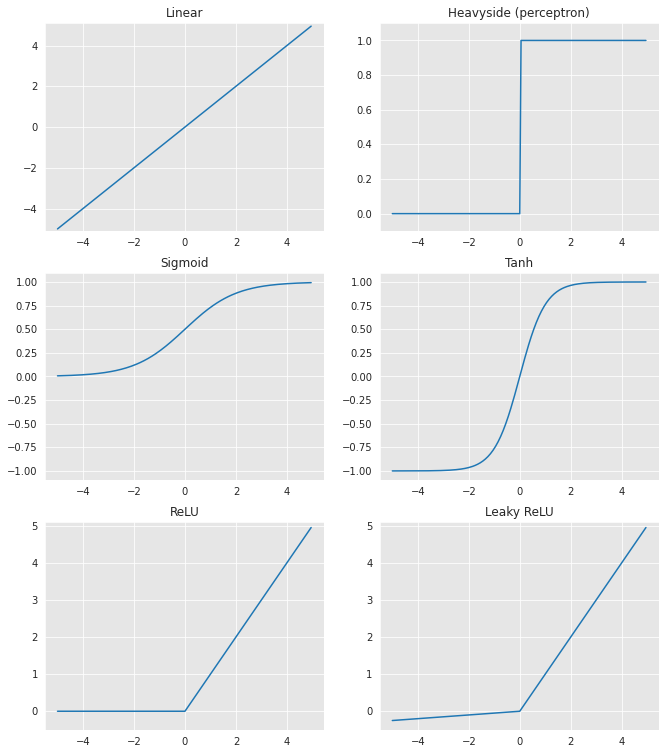

In [11]:
fig_activation

Para nuestra red neuronal de detección de fraude, la activación `ReLU` se usará para la capa oculta y una activación `Sigmoid` para la capa de salida. La primera es la elección principal para las capas intermedias en deep learning. La segunda es la elección principal para las neuronas de salida en problemas de clasificación binaria porque produce valores entre 0 y 1 que pueden interpretarse como probabilidades.

Para implementar esto, creemos una nueva clase `SimpleFraudMLP` que heredará de un módulo torch. Sus capas (`fc1`, `relu`, `fc2`, `sigmoid`) se inicializan en la función `__init__` y se usarán sucesivamente en la propagación hacia adelante.  

In [12]:
class SimpleFraudMLP(torch.nn.Module):
    
        def __init__(self, input_size, hidden_size):
            super(SimpleFraudMLP, self).__init__()
            # parameters
            self.input_size = input_size
            self.hidden_size  = hidden_size
            
            #input to hidden
            self.fc1 = torch.nn.Linear(self.input_size, self.hidden_size)
            self.relu = torch.nn.ReLU()
            #hidden to output
            self.fc2 = torch.nn.Linear(self.hidden_size, 1)
            self.sigmoid = torch.nn.Sigmoid()
            
        def forward(self, x):
            
            hidden = self.fc1(x)
            relu = self.relu(hidden)
            output = self.fc2(relu)
            output = self.sigmoid(output)
            
            return output

Una vez definido, instanciar el modelo con `1000` neuronas en su capa oculta y enviarlo al dispositivo se puede hacer de la siguiente manera:

In [13]:
model = SimpleFraudMLP(len(input_features), 1000).to(DEVICE)

### El optimizador y el bucle de entrenamiento

La optimización está en el núcleo del entrenamiento de redes neuronales. La red neuronal anterior está diseñada para producir un único valor entre 0 y 1. El objetivo es que este valor se acerque lo más posible a 1 (resp. 0) para una entrada que describe una transacción fraudulenta (resp. genuina).

En la práctica, este objetivo se formula con un problema de optimización que tiene como objetivo minimizar o maximizar alguna función de costo/pérdida. El rol de la función de pérdida es precisamente medir la discrepancia entre el valor predicho y el valor esperado (0 o 1), también referido como la verdad fundamental. Hay muchas funciones de pérdida (error cuadrático medio, entropía cruzada, divergencia KL, pérdida de bisagra, error absoluto medio) disponibles en PyTorch, y cada una sirve a un propósito específico. Aquí solo nos enfocamos en la entropía cruzada binaria porque es la función de pérdida más relevante para problemas de clasificación binaria como la detección de fraude. Se define de la siguiente manera:

$BCE(y,p) = −(y*log(p)+(1−y)*log(1−p))$

Donde $y$ es la verdad fundamental (en $\{0,1\}$) y $p$ la salida predicha (en $]0,1[$).

In [14]:
criterion = torch.nn.BCELoss().to(DEVICE)

Nota: Enviar el criterio al dispositivo solo es necesario si este almacena/actualiza variables de estado internas o tiene parámetros. Es innecesario pero no perjudicial en el caso anterior. Lo hacemos para mostrar la implementación más general.

Antes incluso de entrenar el modelo, ya se puede medir su pérdida inicial en el conjunto de prueba. Para esto, el modelo debe ponerse en modo `eval`:

In [15]:
model.eval()

SimpleFraudMLP(
  (fc1): Linear(in_features=15, out_features=1000, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=1000, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Luego, el proceso consiste en iterar sobre el generador de prueba, hacer predicciones y evaluar el `criterion` elegido (aquí `torch.nn.BCELoss`)

In [ ]:
def evaluate_model(model,generator,criterion):
    model.eval()
    batch_losses = []
    for x_batch, y_batch in generator:
        # Propagación hacia adelante
        y_pred = model(x_batch)
        # Calcula la pérdida
        loss = criterion(y_pred.squeeze(), y_batch)
        batch_losses.append(loss.item())
    mean_loss = np.mean(batch_losses)    
    return mean_loss
    
evaluate_model(model,testing_generator,criterion)

0.6754083250670742

Recordemos que el problema de optimización se define de la siguiente manera: minimizar la entropía cruzada binaria total/promedio del modelo sobre todas las muestras del conjunto de datos de entrenamiento. Por lo tanto, entrenar el modelo consiste en aplicar un algoritmo de optimización (retropropagación) para resolver numéricamente el problema de optimización. 

El algoritmo de optimización o `optimizer` puede ser el descenso de gradiente estocástico estándar con una tasa de aprendizaje constante (`torch.optim.SGD`) o con una tasa de aprendizaje adaptativa (`torch.optim.Adagrad`, `torch.optim.Adam`, etc...). Varios hiperparámetros de optimización (tasa de aprendizaje, momentum, tamaño de lote, ...) pueden ajustarse. Nota que elegir el optimizador correcto y los hiperparámetros impactará la velocidad de convergencia y la calidad del óptimo alcanzado. A continuación se muestra una ilustración de qué tan rápido diferentes optimizadores pueden alcanzar el óptimo (representado con una estrella) de un problema de optimización bidimensional durante el proceso de entrenamiento.

![Optimizers convergence](https://ml-cheatsheet.readthedocs.io/en/latest/_images/optimizers.gif) 

Source: https://cs231n.github.io/neural-networks-3/


Here, let us start with the arbitrary choice `SGD`, with a learning rate of `0.07`.


In [17]:
optimizer = torch.optim.SGD(model.parameters(), lr = 0.07)

And let us implement the training loop for our neural network. First, the model has to be set in training mode. Then several iterations can be performed over the training generator (each iteration is called an epoch). During each iteration, a succession of training batches are provided by the generator and a forward pass is performed to get the model's predictions. Then the criterion is computed between predictions and ground truth, and finally, the backward pass is carried out to update the model with the optimizer.
Let us start by setting the number of epochs to `150` arbitrarily. 

In [18]:
n_epochs = 150
#Setting the model in training mode
model.train()

#Training loop
start_time=time.time()
epochs_train_losses = []
epochs_test_losses = []
for epoch in range(n_epochs):
    model.train()
    train_loss=[]
    for x_batch, y_batch in training_generator:
        # Removing previously computed gradients
        optimizer.zero_grad()
        # Performing the forward pass on the current batch
        y_pred = model(x_batch)
        # Computing the loss given the current predictions
        loss = criterion(y_pred.squeeze(), y_batch)
        # Computing the gradients over the backward pass
        loss.backward()
        # Performing an optimization step from the current gradients
        optimizer.step()
        # Storing the current step's loss for display purposes
        train_loss.append(loss.item())
    
    #showing last training loss after each epoch
    epochs_train_losses.append(np.mean(train_loss))
    print('Epoch {}: train loss: {}'.format(epoch, np.mean(train_loss)))
    
    #evaluating the model on the test set after each epoch    
    val_loss = evaluate_model(model,testing_generator,criterion)    
    epochs_test_losses.append(val_loss)
    print('test loss: {}'.format(val_loss))   
    print("")
    
training_execution_time=time.time()-start_time

Epoch 0: train loss: 0.035290839925911685
test loss: 0.02218067791398807

Epoch 1: train loss: 0.026134893728365197
test loss: 0.021469182402057047

Epoch 2: train loss: 0.0246561407407331
test loss: 0.020574169931166553

Epoch 3: train loss: 0.02423229484444929
test loss: 0.02107386154216703

Epoch 4: train loss: 0.023609313174003787
test loss: 0.0210356019355784

Epoch 5: train loss: 0.022873578722177552
test loss: 0.019786655369601145

Epoch 6: train loss: 0.022470950096939557
test loss: 0.019926515792759236

Epoch 7: train loss: 0.02219278062594085
test loss: 0.028550955727806318

Epoch 8: train loss: 0.022042355658335844
test loss: 0.02049338448594368

Epoch 9: train loss: 0.021793536896477114
test loss: 0.019674824729140616

Epoch 10: train loss: 0.021385407493539246
test loss: 0.01945593247867908

Epoch 11: train loss: 0.021190979423734237
test loss: 0.019786519943567813

Epoch 12: train loss: 0.020975370036498363
test loss: 0.019642970249983027

Epoch 13: train loss: 0.02076734

Epoch 109: train loss: 0.014744729096057526
test loss: 0.019482410666562207

Epoch 110: train loss: 0.01478639586868968
test loss: 0.020755630938069685

Epoch 111: train loss: 0.014646960172508015
test loss: 0.019398048360927622

Epoch 112: train loss: 0.01472245290016775
test loss: 0.019159860661682446

Epoch 113: train loss: 0.014562352736468128
test loss: 0.019282711160597446

Epoch 114: train loss: 0.014577984230900334
test loss: 0.0193002821399542

Epoch 115: train loss: 0.014344233295217433
test loss: 0.020133854305154658

Epoch 116: train loss: 0.014341190461110107
test loss: 0.018970135359324077

Epoch 117: train loss: 0.014129704338756278
test loss: 0.01917728733261904

Epoch 118: train loss: 0.01430605129179519
test loss: 0.021149112656150264

Epoch 119: train loss: 0.014255904436282473
test loss: 0.018764410451399347

Epoch 120: train loss: 0.014217122137308613
test loss: 0.019560121930464764

Epoch 121: train loss: 0.014424033683536841
test loss: 0.019554240529785296

Epoch

After training the model, a good practice is to analyze the training logs. 

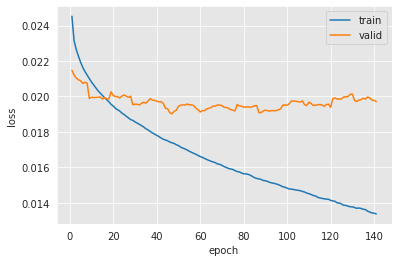

In [19]:
ma_window = 10

plt.plot(np.arange(len(epochs_train_losses)-ma_window + 1)+1, np.convolve(epochs_train_losses, np.ones(ma_window)/ma_window, mode='valid'))
plt.plot(np.arange(len(epochs_test_losses)-ma_window + 1)+1, np.convolve(epochs_test_losses, np.ones(ma_window)/ma_window, mode='valid'))
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','valid'])
#plt.ylim([0.01,0.06])

In [20]:
print(training_execution_time)

851.1251120567322


Se puede notar aquí cómo la pérdida de entrenamiento disminuye época tras época. Esto significa que la optimización va bien: la tasa de aprendizaje elegida permite actualizar el modelo hacia una mejor solución (menor pérdida) para el **conjunto de datos de entrenamiento**. Sin embargo, las redes neuronales son conocidas por ser modelos muy expresivos. De hecho, el teorema de aproximación universal muestra que, con suficientes neuronas/capas, uno puede modelar cualquier función con una red neuronal {cite}`cybenko1989approximation`. Por lo tanto, se espera que una red neuronal compleja pueda ajustar casi perfectamente los datos de entrenamiento. Pero el objetivo final es obtener un modelo que generalice bien en datos no vistos (como el conjunto de validación). Mirando la pérdida de validación, se puede ver que comienza disminuyendo (con oscilaciones) y alcanza un óptimo alrededor de 0.019, y deja de disminuir (o incluso comienza a aumentar). Este fenómeno se conoce como [sobreajuste](Model_Selection).

Muchos aspectos pueden mejorarse en el entrenamiento. Aunque uno no puede medir el rendimiento en el conjunto de prueba final durante el entrenamiento, uno puede confiar en un conjunto de validación e intentar detener el entrenamiento antes del sobreajuste (ver [](Model_Selection)). También se puede cambiar el algoritmo de optimización y los parámetros para acelerar el entrenamiento y alcanzar un mejor óptimo. Esto se investiga más adelante, en el párrafo de optimización.


For now, let us consider this final fitted model and evaluate it the same way as the other models in previous chapters. For this, let us create a prediction DataFrame and call the `performance_assessment` function from the shared functions. 

In [21]:
start_time=time.time() 
predictions_test = model(x_test.to(DEVICE))
prediction_execution_time = time.time()-start_time
predictions_train = model(x_train.to(DEVICE))
print("Predictions took", prediction_execution_time,"seconds.")

Predictions took 0.0022110939025878906 seconds.


In [22]:
predictions_df=test_df
predictions_df['predictions']=predictions_test.detach().cpu().numpy()
    
performance_assessment(predictions_df, top_k_list=[100])

,AUC ROC,Average precision,Card Precision@100
0,0.864,0.653,0.286


This first shot feed-forward network already obtains a decent performance on the test set (refer to [Chapter 3.4](Baseline_FDS_Performances_Simulation) for comparison). But several elements can be modified to improve the AUC ROC, reduce the training time, etc.

As stated above, for the first model, optimization was not carried out properly because the validation performance is not exploited during the training process. To avoid overfitting in practice, it is necessary to take it into account (See Chapter 5, [](Hold_Out_Validation)).

In [23]:
delta_valid = delta_test

start_date_training_with_valid = start_date_training+datetime.timedelta(days=-(delta_delay+delta_valid))

(train_df, valid_df)=get_train_test_set(transactions_df,start_date_training_with_valid,
                                       delta_train=delta_train,delta_delay=delta_delay,delta_test=delta_test)

# By default, scales input data
(train_df, valid_df)=scaleData(train_df, valid_df, input_features)

Let us implement an early stopping strategy. The idea is to detect overfitting, i.e. when validation error starts increasing, and stop the training process. Sometimes, the validation error might increase at a given epoch, but then decrease again. For that reason, it is important to also consider a patience parameter, i.e. a number of iterations for which the training process waits in order to make sure that the error is definitely increasing. 

In [24]:
class EarlyStopping:
    
    def __init__(self, patience=2, verbose=False):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = np.Inf
    
    def continue_training(self,current_score):
        if self.best_score > current_score:
            self.best_score = current_score
            self.counter = 0
            if self.verbose:
                print("New best score:", current_score)
        else:
            self.counter+=1
            if self.verbose:
                print(self.counter, " iterations since best score.")
                
        return self.counter <= self.patience        

In [25]:
seed_everything(SEED)

model = SimpleFraudMLP(len(input_features), 1000).to(DEVICE)

def prepare_generators(train_df,valid_df,batch_size=64):
    x_train = torch.FloatTensor(train_df[input_features].values)
    x_valid = torch.FloatTensor(valid_df[input_features].values)
    y_train = torch.FloatTensor(train_df[output_feature].values)
    y_valid = torch.FloatTensor(valid_df[output_feature].values)
    train_loader_params = {'batch_size': batch_size,
              'shuffle': True,
              'num_workers': 0}
    valid_loader_params = {'batch_size': batch_size,
              'num_workers': 0}
    # Generators
    
    training_set = FraudDataset(x_train, y_train)
    valid_set = FraudDataset(x_valid, y_valid)
    
    training_generator = torch.utils.data.DataLoader(training_set, **train_loader_params)
    valid_generator = torch.utils.data.DataLoader(valid_set, **valid_loader_params)
    
    return training_generator,valid_generator

training_generator,valid_generator = prepare_generators(train_df,valid_df,batch_size=64)

criterion = torch.nn.BCELoss().to(DEVICE)
optimizer = torch.optim.SGD(model.parameters(), lr = 0.0005)

The training loop can now be adapted to integrate early stopping:

In [26]:
def training_loop(model,training_generator,valid_generator,optimizer,criterion,max_epochs=100,apply_early_stopping=True,patience=2,verbose=False):
    #Setting the model in training mode
    model.train()

    if apply_early_stopping:
        early_stopping = EarlyStopping(verbose=verbose,patience=patience)
    
    all_train_losses = []
    all_valid_losses = []
    
    #Training loop
    start_time=time.time()
    for epoch in range(max_epochs):
        model.train()
        train_loss=[]
        for x_batch, y_batch in training_generator:
            optimizer.zero_grad()
            y_pred = model(x_batch)
            loss = criterion(y_pred.squeeze(), y_batch)
            loss.backward()
            optimizer.step()   
            train_loss.append(loss.item())
        
        #showing last training loss after each epoch
        all_train_losses.append(np.mean(train_loss))
        if verbose:
            print('')
            print('Epoch {}: train loss: {}'.format(epoch, np.mean(train_loss)))
        #evaluating the model on the test set after each epoch    
        valid_loss = evaluate_model(model,valid_generator,criterion)
        all_valid_losses.append(valid_loss)
        if verbose:
            print('valid loss: {}'.format(valid_loss))
        if apply_early_stopping:
            if not early_stopping.continue_training(valid_loss):
                if verbose:
                    print("Early stopping")
                break
        
    training_execution_time=time.time()-start_time
    return model,training_execution_time,all_train_losses,all_valid_losses

model,training_execution_time,train_losses,valid_losses = training_loop(model,training_generator,valid_generator,optimizer,criterion,max_epochs=500,verbose=True)


Epoch 0: train loss: 0.1913328490845047
valid loss: 0.09375773465535679
New best score: 0.09375773465535679

Epoch 1: train loss: 0.09739777461463589
valid loss: 0.06964004442421465
New best score: 0.06964004442421465

Epoch 2: train loss: 0.07702973348410874
valid loss: 0.05692868165753252
New best score: 0.05692868165753252

Epoch 3: train loss: 0.06568225591940303
valid loss: 0.05035814772171727
New best score: 0.05035814772171727

Epoch 4: train loss: 0.06026483534071345
valid loss: 0.04624887502299306
New best score: 0.04624887502299306

Epoch 5: train loss: 0.056940919349244286
valid loss: 0.04359364376449194
New best score: 0.04359364376449194

Epoch 6: train loss: 0.054429791377141476
valid loss: 0.04157831529816969
New best score: 0.04157831529816969

Epoch 7: train loss: 0.052457363431094424
valid loss: 0.04001519718599287
New best score: 0.04001519718599287

Epoch 8: train loss: 0.050785390330731414
valid loss: 0.03874376885531867
New best score: 0.03874376885531867

Epoch 

valid loss: 0.024120652137700815
New best score: 0.024120652137700815

Epoch 74: train loss: 0.03013364729372674
valid loss: 0.024093669633345444
New best score: 0.024093669633345444

Epoch 75: train loss: 0.030071343618924114
valid loss: 0.024088013470121992
New best score: 0.024088013470121992

Epoch 76: train loss: 0.03001892710608532
valid loss: 0.024011776422002848
New best score: 0.024011776422002848

Epoch 77: train loss: 0.029969145755335175
valid loss: 0.023975220763333183
New best score: 0.023975220763333183

Epoch 78: train loss: 0.02991881920848341
valid loss: 0.02395541004638081
New best score: 0.02395541004638081

Epoch 79: train loss: 0.02986845553449282
valid loss: 0.02393013280867268
New best score: 0.02393013280867268

Epoch 80: train loss: 0.029822142165907468
valid loss: 0.023900585737629015
New best score: 0.023900585737629015

Epoch 81: train loss: 0.029775497005419024
valid loss: 0.023856908664402494
New best score: 0.023856908664402494

Epoch 82: train loss: 0.0


Epoch 146: train loss: 0.027839381755712527
valid loss: 0.022589396648974122
1  iterations since best score.

Epoch 147: train loss: 0.02781995714808606
valid loss: 0.022585400501062555
2  iterations since best score.

Epoch 148: train loss: 0.0278003837200537
valid loss: 0.022568948230772316
New best score: 0.022568948230772316

Epoch 149: train loss: 0.027782129139833536
valid loss: 0.02255174289432054
New best score: 0.02255174289432054

Epoch 150: train loss: 0.02776255571714337
valid loss: 0.02253183182914197
New best score: 0.02253183182914197

Epoch 151: train loss: 0.027743494876679993
valid loss: 0.022533289264745075
1  iterations since best score.

Epoch 152: train loss: 0.02775508448228696
valid loss: 0.02251671864193116
New best score: 0.02251671864193116

Epoch 153: train loss: 0.027706991043075363
valid loss: 0.02250744028123798
New best score: 0.02250744028123798

Epoch 154: train loss: 0.02771934628865929
valid loss: 0.022485052686581602
New best score: 0.0224850526865


Epoch 219: train loss: 0.02675781211188957
valid loss: 0.021882710980678923
New best score: 0.021882710980678923

Epoch 220: train loss: 0.02671727145791417
valid loss: 0.02188420647175097
1  iterations since best score.

Epoch 221: train loss: 0.026706334428299026
valid loss: 0.021876843120200468
New best score: 0.021876843120200468

Epoch 222: train loss: 0.02669213155113574
valid loss: 0.02187243546410133
New best score: 0.02187243546410133

Epoch 223: train loss: 0.026701319294075265
valid loss: 0.021869710195158185
New best score: 0.021869710195158185

Epoch 224: train loss: 0.026678147293265772
valid loss: 0.0218592405571129
New best score: 0.0218592405571129

Epoch 225: train loss: 0.026663049977819434
valid loss: 0.02185935075471147
1  iterations since best score.

Epoch 226: train loss: 0.026644339121434744
valid loss: 0.021852905498664886
New best score: 0.021852905498664886

Epoch 227: train loss: 0.026632149542421886
valid loss: 0.02184709989964514
New best score: 0.021847

After 251 epochs, the model stops learning because the validation performance has not improved for three iterations. Here the optimal model (from epoch 248) is not saved, but this could be implemented by simply adding `torch.save(model.state_dict(), checkpoint_path)` in the `EarlyStopping` class whenever a new best performance is reached. This allows reloading the saved best checkpoint at the end of the training. 

Now that a clean optimization process is defined, one can consider several solutions to speed up and improve convergence towards a decent extremum. The most natural way to do so is to play with the optimizer hyperparameters like the learning rate and the batch size. With a large learning rate, gradient descent is fast at the beginning, but then the optimizer struggles to find the minimum. Adaptive learning rate techniques like Adam/RMSProp take into account the steepness by normalizing the learning rate with respect to the gradient norm. Below are the formulas to update on a model parameter $w_t$ with Adam.

$w_{t+1} = w_t - \frac{\eta}{\sqrt{\hat{v_t}+\epsilon}}*\hat{m_t}$

Where:

$m_t = \beta_1 * m_{t-1} + (1-\beta_1)*\nabla w_t$

$v_t = \beta_2 * v_{t-1} + (1-\beta_2)*(\nabla w_t)^2$

$\hat{m_t}=\frac{m_t}{1-\beta_1^t}$

$\hat{v_t}=\frac{v_t}{1-\beta_2^t}$

The difference with SGD is that here the learning rate is normalized using the "gradient norm" ($\approx \hat{m_t}$). To be more precise, the approach does not use the "raw" gradient $\nabla w_t$ and gradient norm $\nabla w_t^2$ but a momentum instead (convex combination between previous values and the current value), respectively $m_t$ and $v_t$. It also applies a decay over the iterations.

Let us try Adam with an initial learning rate of `0.0005` to see the difference with regular SGD. 

In [27]:
seed_everything(SEED)
model = SimpleFraudMLP(len(input_features), 1000).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0005)
model,training_execution_time,train_losses_adam,valid_losses_adam = training_loop(model,training_generator,valid_generator,optimizer,criterion,verbose=True)


Epoch 0: train loss: 0.04573855715283828
valid loss: 0.022921395302963915
New best score: 0.022921395302963915

Epoch 1: train loss: 0.026701830054725026
valid loss: 0.02114229145894957
New best score: 0.02114229145894957

Epoch 2: train loss: 0.024963660846240854
valid loss: 0.020324631678856543
New best score: 0.020324631678856543

Epoch 3: train loss: 0.023575769497520587
valid loss: 0.020667109151543857
1  iterations since best score.

Epoch 4: train loss: 0.022709976203506368
valid loss: 0.019151893639657136
New best score: 0.019151893639657136

Epoch 5: train loss: 0.02221683326257877
valid loss: 0.01883163772557755
New best score: 0.01883163772557755

Epoch 6: train loss: 0.021621740234552315
valid loss: 0.020071852290392166
1  iterations since best score.

Epoch 7: train loss: 0.021379320485157675
valid loss: 0.01888933465421668
2  iterations since best score.

Epoch 8: train loss: 0.020929416735303973
valid loss: 0.018099226153906068
New best score: 0.018099226153906068

Epoc

(0.01, 0.06)

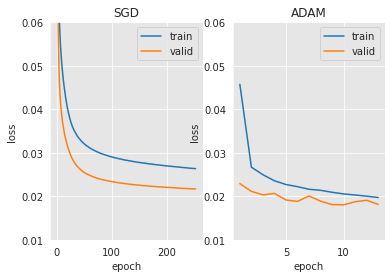

In [28]:
plt.subplot(1, 2, 1)
plt.plot(np.arange(len(train_losses))+1, train_losses)
plt.plot(np.arange(len(valid_losses))+1, valid_losses)
plt.title("SGD")
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','valid'])
plt.ylim([0.01,0.06])

plt.subplot(1, 2, 2) 
plt.plot(np.arange(len(train_losses_adam))+1, train_losses_adam)
plt.plot(np.arange(len(valid_losses_adam))+1, valid_losses_adam)
plt.title("ADAM")
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','valid'])
plt.ylim([0.01,0.06])


The optimization is much faster with Adam (10 times fewer epochs) and it reaches a better optimum. Of course, increasing patience or changing the learning rate with SGD would probably help improve both speed and optimum. Nevertheless, Adam will be retained for the rest of the chapter as it usually allows very decent performance **without significant tuning**. To build the final neural network later, the tuning will mostly be made using batch size and initial learning rate. 

Here are only mentioned the optimizer's choice and some hyperparameters tuning for the optimization process. But keep in mind that neural network optimization is a very wide and active area of research/engineering. For instance, with Deep Networks, one can apply batch normalization after each layer to standardize the distribution and speed up convergence. One can also reduce the learning rate when validation loss reaches a plateau (`torch.optim.ReduceLROnPlateau`). For a full guide on Deep Learning optimization, we recommend {cite}`ruder2016overview,le2011optimization`.

## Regularization

A classical way to improve generalization and reach a better validation performance is to regularize the model. Roughly speaking, regularization consists in limiting the model expressiveness in order to reduce overfitting. 

The most common technique to regularize a machine learning model is to restrict its parameter space, for instance, its norm, by adding a term in the optimization problem. Additionally, to minimize the discrepancy between ground truth and prediction, integrating an L1 norm (resp. L2 norm) term in the loss will entail parameter sparsity (resp. will limit parameters amplitude). The initial solution space is generally full of equivalent solutions (e.g. with linear activations, dividing all input weights of a neuron by 2 and multiplying all of its output weights by 2 leads to an equivalent model), so the restrictions entailed by regularization not only limits overfitting but also reduces the search and can help with optimization. Finally, selecting a solution with minimal norm follows the principle of "All things being equal, the simplest solution tends to be the best one", a scientific principle often referred to as the [Occam's razor](https://en.wikipedia.org/wiki/Occam's_razor).

In contrast to adding loss terms, there is a regularization technique specifically designed for Neural Networks called dropout. Dropout consists in randomly dropping some neurons from the network at each training step. More precisely, one fixes a dropout parameter p∈[0,1], and, for each mini-batch, for each neuron, performs a coin toss (Bernoulli) with probability p. If positive, one temporarily sets the neuron's weights to zero (so that the dropped neuron is not considered during the forward and backward passes). It is equivalent to training a random sub-network at each mini-batch (Figure 5), and it can be proven that this has an L2-regularization effect on specific architectures {cite}`srivastava2014dropout`.

![alt text](./images/dropout.png)
Image source: {cite}`srivastava2014dropout`

To implement it, let us define a new model with an additional `torch.nn.Dropout` layer.

In [29]:
class SimpleFraudMLPWithDropout(torch.nn.Module):
    
        def __init__(self, input_size, hidden_size,p):
            super(SimpleFraudMLPWithDropout, self).__init__()
            # parameters
            self.input_size = input_size
            self.hidden_size  = hidden_size
            self.p = p
            
            #input to hidden
            self.fc1 = torch.nn.Linear(self.input_size, self.hidden_size)
            self.relu = torch.nn.ReLU()
            #hidden to output
            self.fc2 = torch.nn.Linear(self.hidden_size, 1)
            self.sigmoid = torch.nn.Sigmoid()
            
            self.dropout = torch.nn.Dropout(self.p)
            
        def forward(self, x):
            
            hidden = self.fc1(x)
            hidden = self.relu(hidden)
            
            hidden = self.dropout(hidden)
            
            output = self.fc2(hidden)
            output = self.sigmoid(output)
            
            return output

Note that setting the model in training/evaluation mode with the methods `model.eval()` and `model.train()` take all its significance here. In particular, the dropout layer in the forward pass is only applied when the model is in training mode.

In [30]:
seed_everything(SEED)
model = SimpleFraudMLPWithDropout(len(input_features), 1000,0.2).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0005)
model,training_execution_time,train_losses_dropout,valid_losses_dropout = training_loop(model,training_generator,valid_generator,optimizer,criterion,verbose=False)

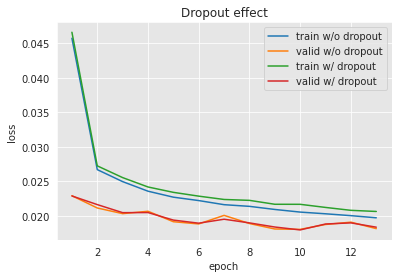

In [31]:
plt.plot(np.arange(len(train_losses_adam))+1, train_losses_adam)
plt.plot(np.arange(len(valid_losses_adam))+1, valid_losses_adam)
plt.plot(np.arange(len(train_losses_dropout))+1, train_losses_dropout)
plt.plot(np.arange(len(valid_losses_dropout))+1, valid_losses_dropout)
plt.title("Dropout effect")
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train w/o dropout','valid w/o dropout','train w/ dropout','valid w/ dropout'])

It is generally reported that a small dropout value can lead to better generalization results than no dropout, but it can sometimes be the opposite if the training data are very rich, if the training distribution is close to the valid/test distribution, and if the model is already not too expressive. So, the best practice is to consider dropout as a hyperparameter (that could be set to 0) and tune it with a hyperparameter search. 

In addition to the L2-regularization effect, dropout can be seen as a very powerful mechanism that mimics ensembling strategies like bagging (the model can be seen as an ensemble of submodels trained on different subsets of data) {cite}`goodfellow2016deep`. 

## Scaling the inputs

XGBoost y los bosques aleatorios aprenden divisiones en características individuales y por lo tanto son robustos a la escala y distribución de los valores. Por el contrario, en una red neuronal, cada neurona de la primera capa aprende una combinación lineal de todas las características. Por lo tanto, es más fácil entrenar las neuronas cuando todas las características tienen el mismo rango y están normalmente distribuidas. La primera propiedad puede implementarse fácilmente aplicando escalado min-max o estándar en las características. En cuanto a la segunda propiedad, depende de la distribución original de las características. Algunas de ellas no están normalmente distribuidas y tienen escalas no lineales (por ejemplo, cantidad): aumentar la cantidad en 5 dólares no debería tener el mismo efecto si el punto de partida es 5 dólares o si el punto de partida es 100 dólares. Resulta que aplicar la función log en tales características puede hacer que su distribución sea ligeramente más normal, lo que facilita que las redes neuronales feed-forward aprendan de ellas. 


In [32]:
(train_df, valid_df)=get_train_test_set(transactions_df,start_date_training_with_valid,
                                       delta_train=delta_train,delta_delay=delta_delay,delta_test=delta_test)

For instance here is how the original amounts look like:

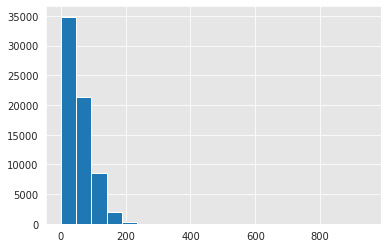

In [33]:
_ = plt.hist(train_df['TX_AMOUNT'].values,bins=20)

And now let us apply the log function to it. To obtain a positive log for the feature that is in [0,+∞[, an idea is to add 1 and then apply the log function (which is equivalent to applying the `log1p` function in `numpy`). This leads to a preprocessed feature that belongs to [0,+∞[ and it can then be standardized. Here is how the amounts are distributed after all these steps:

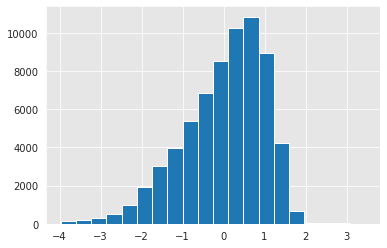

In [34]:
_ = plt.hist(sklearn.preprocessing.StandardScaler().fit_transform(np.log1p(train_df['TX_AMOUNT'].values).reshape(-1, 1)),bins=20)

Note that here, our artificial data were generated with Gaussians so the `np.log1p` is not very useful in practice. But keep in mind that on real-world data, the original scale of features like amount is far from normally distributed and this operation turns out to be quite often useful. 

Let us forget about the log for now and just analyze the impact of scaling the features on our Neural Network's training. More precisely, let us see the difference between no scaling at all and standard scaling. A smaller learning rate of `0.0001` will be chosen here for the experiment without scaling to avoid divergence.

In [35]:
#we did not call the function scaleData this time
seed_everything(SEED)
training_generator,valid_generator = prepare_generators(train_df,valid_df,batch_size=64)

model = SimpleFraudMLPWithDropout(len(input_features), 1000,0.2).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0001)
model,training_execution_time,train_losses_without_scaling,valid_losses_without_scaling = training_loop(model,training_generator,valid_generator,optimizer,criterion,verbose=False)

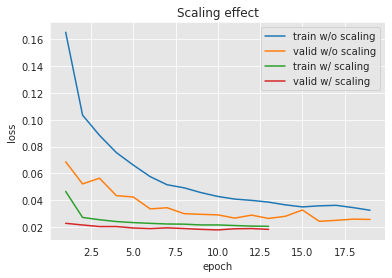

In [36]:
plt.plot(np.arange(len(train_losses_without_scaling))+1, train_losses_without_scaling)
plt.plot(np.arange(len(valid_losses_without_scaling))+1, valid_losses_without_scaling)
plt.plot(np.arange(len(train_losses_dropout))+1, train_losses_dropout)
plt.plot(np.arange(len(valid_losses_dropout))+1, valid_losses_dropout)
plt.title('Scaling effect')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train w/o scaling','valid w/o scaling','train w/ scaling','valid w/ scaling'])

The train/valid losses are smoother and reach much better levels faster when the data is normalized with standard scaling.

In [37]:
# Let us rescale data for the next parts
(train_df, valid_df)=scaleData(train_df, valid_df,input_features)

## Embeddings

Tener en cuenta adecuadamente las variables categóricas es quizás una de las principales ventajas de las redes neuronales. En los primeros capítulos, se aplicaron [técnicas de transformación de características](Baseline_Feature_Transformation) a características categóricas como día, ID de Cliente, ID de Terminal, para hacerlas binarias o para extraer características numéricas de ellas. 

En datos del mundo real, las características categóricas son frecuentes (País, Tipo de Comerciante, hora, tipo de pago, ...). Pero la mayoría de los algoritmos de aprendizaje automático requieren que las características sean numéricas. Tomemos el ejemplo de la regresión lineal: es básicamente una suma ponderada de los valores de las características. Para características numéricas, tiene sentido considerar que su impacto es proporcional a su valor (por ejemplo, cuanto menor es el retraso entre dos transacciones, mayor es el riesgo de fraude), pero no tiene sentido para una característica nominal como un País que puede tomar los valores "USA", "Francia", "Bélgica". Para esta última, es necesaria una transformación. Las opciones más comunes son:

* Codificación one-hot: se define una característica binaria para cada modalidad (por ejemplo, "country_is_USA", "country_is_France" y "country_is_Belgium").
* Codificación basada en frecuencia: Se calcula la frecuencia (u otra estadística) de cada modalidad y el índice de la modalidad se reemplaza con el valor de la estadística. 
* Codificación de correlación con etiqueta: Es similar a la codificación de frecuencia pero aquí se calcula una estadística correlacionada con la etiqueta. Por ejemplo, cada modalidad puede ser reemplazada con su proporción de fraude en los datos de entrenamiento. 

Con redes neuronales, se puede hacer uso de capas de embedding para codificar variables categóricas. Más precisamente, la idea es dejar que la red neuronal misma aprenda una representación de cada modalidad de la variable categórica en un espacio vectorial continuo de dimensión k, elegido por el practicante. Estas representaciones se pueden aprender de extremo a extremo para hacer que la red de propagación hacia adelante sea óptima para la tarea de detección de fraude. También se pueden aprender con un objetivo diferente como predecir las secuencias de países visitados por los titulares de tarjetas (pre-entrenamiento no supervisado) y luego usarse para detección de fraude, ya sea con un clasificador de red neuronal o cualquier otro clasificador (XGBoost, random forest, etc.). 

![Ilustración de capa de embedding](./images/embedding.png)

Nota que aprender un embedding de dimensión $k$ para una característica categórica es computacionalmente equivalente a aprender una capa completamente conectada clásica que toma como entrada la codificación one-hot de la característica y produce $k$ neuronas.

Para probar las capas de embedding, intentemos agregar entradas categóricas adicionales en $x$ y dejar que el modelo aprenda embeddings para ellas. Nuestra última red neuronal fue entrenada en las siguientes características:

In [38]:
input_features

['TX_AMOUNT',
 'TX_DURING_WEEKEND',
 'TX_DURING_NIGHT',
 'CUSTOMER_ID_NB_TX_1DAY_WINDOW',
 'CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW',
 'CUSTOMER_ID_NB_TX_7DAY_WINDOW',
 'CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW',
 'CUSTOMER_ID_NB_TX_30DAY_WINDOW',
 'CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW',
 'TERMINAL_ID_NB_TX_1DAY_WINDOW',
 'TERMINAL_ID_RISK_1DAY_WINDOW',
 'TERMINAL_ID_NB_TX_7DAY_WINDOW',
 'TERMINAL_ID_RISK_7DAY_WINDOW',
 'TERMINAL_ID_NB_TX_30DAY_WINDOW',
 'TERMINAL_ID_RISK_30DAY_WINDOW']

Agreguemos, por ejemplo, el id de terminal crudo y el día de la semana como características de entrada categóricas:

In [ ]:
def weekday(tx_datetime):
    
    # Transforma la fecha en día de la semana (0 es lunes, 6 es domingo)
    weekday = tx_datetime.weekday()
    
    return int(weekday)

In [40]:
train_df['TX_WEEKDAY'] = train_df.TX_DATETIME.apply(weekday)
valid_df['TX_WEEKDAY'] = valid_df.TX_DATETIME.apply(weekday)
input_categorical_features = ['TX_WEEKDAY','TERMINAL_ID']


Definamos ahora un nuevo modelo de red neuronal con dos capas de embedding. `TX_WEEKDAY` y `TERMINAL_ID` pasarán ambos por una de ellas, y cada uno se convertirá en un vector. Luego se concatenarán con las características numéricas y todo pasará por una red similar a nuestra arquitectura anterior.

In [ ]:
class FraudMLPWithEmbedding(torch.nn.Module):
    
        def __init__(self, categorical_inputs_modalities,numerical_inputs_size,embedding_sizes, hidden_size,p):
            super(FraudMLPWithEmbedding, self).__init__()
            # parámetros
            self.categorical_inputs_modalities = categorical_inputs_modalities
            self.numerical_inputs_size = numerical_inputs_size
            self.embedding_sizes = embedding_sizes
            self.hidden_size  = hidden_size
            self.p = p
            
            assert len(categorical_inputs_modalities)==len(embedding_sizes), 'categorical_inputs_modalities y embedding_sizes deben tener la misma longitud'
            
            # capas de embedding
            self.emb = []
            for i in range(len(categorical_inputs_modalities)):
                self.emb.append(torch.nn.Embedding(int(categorical_inputs_modalities[i]), int(embedding_sizes[i])).to(DEVICE))
                
            
            # entradas concatenadas a oculta
            self.fc1 = torch.nn.Linear(self.numerical_inputs_size+int(np.sum(embedding_sizes)), self.hidden_size)
            self.relu = torch.nn.ReLU()
            # oculta a salida
            self.fc2 = torch.nn.Linear(self.hidden_size, 1)
            self.sigmoid = torch.nn.Sigmoid()
            
            self.dropout = torch.nn.Dropout(self.p)
            
        def forward(self, x):
            # asumimos que x comienza con características numéricas luego características categóricas
            inputs = [x[:,:self.numerical_inputs_size]]
            for i in range(len(self.categorical_inputs_modalities)):
                inputs.append(self.emb[i](x[:,self.numerical_inputs_size+i].to(torch.int64)))
            
            x = torch.cat(inputs,axis=1)
            
            
            hidden = self.fc1(x)
            hidden = self.relu(hidden)
            
            hidden = self.dropout(hidden)
            
            output = self.fc2(hidden)
            output = self.sigmoid(output)
            
            return output

In [ ]:
def prepare_generators_with_categorical_features(train_df,valid_df,input_categorical_features,batch_size=64):
    x_train = torch.FloatTensor(train_df[input_features].values)
    x_valid = torch.FloatTensor(valid_df[input_features].values)
    y_train = torch.FloatTensor(train_df[output_feature].values)
    y_valid = torch.FloatTensor(valid_df[output_feature].values)
    
    # variables categóricas: codificación válida según entrenamiento
    encoder = sklearn.preprocessing.OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1)
    x_train_cat = encoder.fit_transform(train_df[input_categorical_features].values) + 1
    categorical_inputs_modalities = np.max(x_train_cat,axis=0)+1
    
    x_train_cat = torch.IntTensor(x_train_cat)
    x_valid_cat = torch.IntTensor(encoder.transform(valid_df[input_categorical_features].values) + 1)
    
    x_train = torch.cat([x_train,x_train_cat],axis=1)
    x_valid = torch.cat([x_valid,x_valid_cat],axis=1)
    
    train_loader_params = {'batch_size': batch_size,
              'shuffle': True,
              'num_workers': 0}
    valid_loader_params = {'batch_size': batch_size,
              'num_workers': 0}
    
    # Generadores
    training_set = FraudDataset(x_train, y_train)
    valid_set = FraudDataset(x_valid, y_valid)
    
    training_generator = torch.utils.data.DataLoader(training_set, **train_loader_params)
    valid_generator = torch.utils.data.DataLoader(valid_set, **valid_loader_params)
    
    return training_generator,valid_generator, categorical_inputs_modalities

Ahora entrenemos este nuevo modelo con una dimensión de embedding de 10 para cada característica categórica. 

In [43]:
seed_everything(SEED)
training_generator,valid_generator,categorical_inputs_modalities = prepare_generators_with_categorical_features(train_df,valid_df,input_categorical_features,batch_size=64)

embedding_sizes = [10]*len(categorical_inputs_modalities)

model = FraudMLPWithEmbedding(categorical_inputs_modalities,len(input_features),embedding_sizes, 1000,0.2).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0001)
model,training_execution_time,train_losses_embedding,valid_losses_embedding = training_loop(model,training_generator,valid_generator,optimizer,criterion,verbose=False)

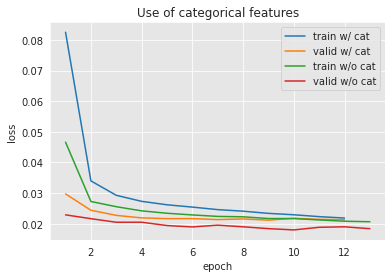

In [44]:
plt.plot(np.arange(len(train_losses_embedding))+1, train_losses_embedding)
plt.plot(np.arange(len(valid_losses_embedding))+1, valid_losses_embedding)
plt.plot(np.arange(len(train_losses_dropout))+1, train_losses_dropout)
plt.plot(np.arange(len(valid_losses_dropout))+1, valid_losses_dropout)
plt.title('Use of categorical features')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train w/ cat','valid w/ cat','train w/o cat','valid w/o cat'])

El rendimiento aquí no es necesariamente mejor con las características categóricas (no agregan valor en comparación con las características diseñadas, al menos para los patrones de fraude en nuestros datos categóricos). Esta implementación se muestra con fines educativos. Tenga en cuenta que las capas de embedding son a menudo una solución valiosa en la práctica cuando se entrena con muchos datos porque es un paso adelante en la automatización (en lugar de ingeniería de características experta, se puede dejar la elección de representación al modelo). 

El embedding también puede ser interesante para la interpretabilidad. De hecho, al final del entrenamiento, se puede extraer `model.emb[i].weight`. Cada fila de esta matriz representa el vector de embedding de una modalidad dada para la característica categórica `i-ésima`. Esto se puede usar para calcular similitudes entre modalidades. También se puede reducir la dimensionalidad de estos vectores con TSNE o PCA y visualizar todas las modalidades en un plano 2D.

## Ensemble

To go further and improve the results, ensembling is a common strategy with neural networks in general and for fraud detection. 

The idea is to simply train the architecture several times and average the predictions of all the obtained models at inference {cite}`zhou2021ensemble`. Layer initialization and the random batch order are generally enough to ensure diversity between each submodel and make the ensemble better than each individual. To go further, one can also train each individual on a different train/valid split {cite}`breiman1996bagging`.

Ensembling is also very useful for fraud detection, in particular, because of concept drift. Indeed, in fraud detection, the fraudsters' techniques are varied and change over time. A single model can struggle to both learn and remember all the different patterns for the target class. In this context, it is expected that an ensemble of models, efficiently built, can cope with the issue. The intuition is that the different components of the ensemble can be specialized for different tasks. For example, a component could be specialized for the recent patterns and another for the old patterns {cite}`lebichot2021incremental`. Similarly, a component could be specialized for the easiest and generic fraudsters’ strategies and another for advanced concepts.

(Model_Selection_FFNN)=
## Prequential grid search

The above sections have shown many design choices for the neural network. Let us now follow the prequential methodology from Chapter 5 and perform a grid search to see the impact of some hyperparameters on the performance and be able to compare the results with other baselines from previous chapters.

Let us consider the following ranges:
* Batch size : [64,128,256]
* Initial learning rate: [0.0001, 0.0002, 0.001]
* Dropout rate : [0, 0.2, 0.4]
* Hidden layer dimension : [500]
* Number of hidden layers : [1,2]

To use the same procedure as in previous chapters (with GridSearchCV), we have to make the neural network compatible with `sklearn` functions. We will resort to the library `skorch`, which provides an `sklearn` wrapper for `PyTorch` modules. Also, early stopping won't be used, but instead the number of epochs ([10,20,40]) will be another parameter to search.

In [45]:
!pip install skorch

In [46]:
from skorch import NeuralNetClassifier

Para que esto funcione, varios aspectos de nuestras clases Python anteriores deben adaptarse. Primero, los clasificadores de `sklearn` tienen dos probabilidades de salida (una para cada clase) que son complementarias. Por lo tanto, la salida de `fc2` debe cambiarse a 2, y la activación a `softmax` (similar a la activación sigmoid pero con una normalización global). Segundo, el conjunto de datos debe esperar arrays en lugar de tensores, por lo que la conversión se hará dentro del conjunto de datos. 


In [47]:
class FraudMLP(torch.nn.Module):
    
        def __init__(self, hidden_size=100,num_layers=1,p=0, input_size=len(input_features)):
            super(FraudMLP, self).__init__()
            # parameters
            self.input_size = input_size
            self.hidden_size  = hidden_size
            self.p = p
            
            #input to hidden
            self.fc1 = torch.nn.Linear(self.input_size, self.hidden_size)
            self.relu = torch.nn.ReLU()
            
            self.fc_hidden=[]
            for i in range(num_layers-1):
                self.fc_hidden.append(torch.nn.Linear(self.hidden_size, self.hidden_size))
                self.fc_hidden.append(torch.nn.ReLU())
                
            #hidden to output
            self.fc2 = torch.nn.Linear(self.hidden_size, 2)
            self.softmax = torch.nn.Softmax()
            
            self.dropout = torch.nn.Dropout(self.p)
            
        def forward(self, x):
            
            hidden = self.fc1(x)
            hidden = self.relu(hidden)             
            hidden = self.dropout(hidden)
            
            for layer in self.fc_hidden:
                hidden=layer(hidden)
                hidden = self.dropout(hidden)
            
            output = self.fc2(hidden)
            output = self.softmax(output)
            
            return output

In [48]:
class FraudDatasetForPipe(torch.utils.data.Dataset):
    
    def __init__(self, x, y):
        'Initialization'
        self.x = torch.FloatTensor(x)
        self.y = None
        if y is not None:
            self.y = torch.LongTensor(y.values)
        

    def __len__(self):
        'Returns the total number of samples'
        return len(self.x)

    def __getitem__(self, index):
        'Generates one sample of data'
        # Selecciona el índice de la muestra
        if self.y is not None:
            return self.x[index], self.y[index]
        else:
            return self.x[index], -1       


Now that the module and Dataset are adapted, one can obtain an "sklearn-like" model using the `NeuralNetClassifier` wrapper from `skorch`. Note that we can set the device directly as a parameter in that class.

In [49]:
net = NeuralNetClassifier(
    FraudMLP,
    max_epochs=2,
    lr=0.001,
    optimizer=torch.optim.Adam,
    batch_size=64,
    dataset=FraudDatasetForPipe,
    iterator_train__shuffle=True
)
net.set_params(train_split=False, verbose=0)

<class 'skorch.classifier.NeuralNetClassifier'>[uninitialized](
  module=<class '__main__.FraudMLP'>,
)

To test it, let us perform a first small grid search by playing on the number of epochs and number of layers.

In [50]:
# Testing the wrapper

#X=train_df[input_features].values
#y=train_df[output_feature]
#
#net.fit(X, y)
#net.predict_proba(X)

In [51]:
# Solo mantiene las columnas que se necesitan como argumento para la función de scoring personalizada
# para reducir el tiempo de serialización del conjunto de datos de transacciones
transactions_df_scorer=transactions_df[['CUSTOMER_ID', 'TX_FRAUD','TX_TIME_DAYS']]

# Crea un scorer usando card_precision_top_k_custom
card_precision_top_100 = sklearn.metrics.make_scorer(card_precision_top_k_custom, 
                                                     needs_proba=True, 
                                                     top_k=100, 
                                                     transactions_df=transactions_df_scorer)

n_folds=4
start_date_training_for_valid = start_date_training+datetime.timedelta(days=-(delta_delay+delta_valid))
start_date_training_for_test = start_date_training+datetime.timedelta(days=(n_folds-1)*delta_test)
delta_assessment = delta_valid


In [52]:
seed_everything(SEED)
start_time=time.time()

parameters = {
    'clf__lr': [0.001 ],
    'clf__batch_size': [64],
    'clf__max_epochs': [10, 20],
    'clf__module__hidden_size': [100],
    'clf__module__num_layers': [1,2],
    'clf__module__p': [0],
}

scoring = {'roc_auc':'roc_auc',
           'average_precision': 'average_precision',
           'card_precision@100': card_precision_top_100,
           }


performance_metrics_list_grid=['roc_auc', 'average_precision', 'card_precision@100']
performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100']

performances_df_validation=prequential_grid_search(
    transactions_df, net, 
    input_features, output_feature,
    parameters, scoring, 
    start_date_training=start_date_training_with_valid,
    n_folds=n_folds,
    expe_type='Validation',
    delta_train=delta_train, 
    delta_delay=delta_delay, 
    delta_assessment=delta_valid,
    performance_metrics_list_grid=performance_metrics_list_grid,
    performance_metrics_list=performance_metrics_list)

print("Validation: Total execution time: "+str(round(time.time()-start_time,2))+"s")

Validation: Total execution time: 37.16s


In [53]:
performances_df_validation

,AUC ROC Validation,AUC ROC Validation Std,Average precision Validation,Average precision Validation Std,Card Precision@100 Validation,Card Precision@100 Validation Std,Parameters,Execution time
0,0.876016,0.013714,0.664448,0.011927,0.280714,0.014621,"{'clf__batch_size': 64, 'clf__lr': 0.001, 'clf...",17.007030
1,0.878834,0.015987,0.664845,0.017734,0.285000,0.012227,"{'clf__batch_size': 64, 'clf__lr': 0.001, 'clf...",18.879923
2,0.880894,0.009318,0.682133,0.004213,0.282857,0.013590,"{'clf__batch_size': 64, 'clf__lr': 0.001, 'clf...",29.965765
3,0.879129,0.007107,0.680034,0.010408,0.283571,0.014160,"{'clf__batch_size': 64, 'clf__lr': 0.001, 'clf...",33.341235


Validation seems to be running smoothly and the results already look promising. 

Let us now perform a proper model selection using the protocol from Chapter 5.3, [](Model_Selection).

In [54]:
seed_everything(SEED)


parameters = {
    'clf__lr': [0.001 , 0.0001, 0.0002],
    'clf__batch_size': [64,128,256],
    'clf__max_epochs': [10,20,40],
    'clf__module__hidden_size': [500],
    'clf__module__num_layers': [1,2],
    'clf__module__p': [0,0.2,0.4],
    'clf__module__input_size': [int(len(input_features))],
}

start_time=time.time()

performances_df=model_selection_wrapper(transactions_df, net, 
                                        input_features, output_feature,
                                        parameters, scoring, 
                                        start_date_training_for_valid,
                                        start_date_training_for_test,
                                        n_folds=n_folds,
                                        delta_train=delta_train, 
                                        delta_delay=delta_delay, 
                                        delta_assessment=delta_assessment,
                                        performance_metrics_list_grid=performance_metrics_list_grid,
                                        performance_metrics_list=performance_metrics_list,
                                        n_jobs=10)


execution_time_nn = time.time()-start_time

parameters_dict=dict(performances_df['Parameters'])
performances_df['Parameters summary']=[str(parameters_dict[i]['clf__lr'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__batch_size'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__max_epochs'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__module__p'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__module__num_layers'])
                                   for i in range(len(parameters_dict))]

performances_df_nn=performances_df

In [55]:
performances_df_nn

,AUC ROC Test,AUC ROC Test Std,Average precision Test,Average precision Test Std,Card Precision@100 Test,Card Precision@100 Test Std,Parameters,Execution time,AUC ROC Validation,AUC ROC Validation Std,Average precision Validation,Average precision Validation Std,Card Precision@100 Validation,Card Precision@100 Validation Std,Parameters summary
0,0.873863,0.012930,0.660331,0.018567,0.295714,0.012247,"{'clf__batch_size': 64, 'clf__lr': 0.001, 'clf...",19.616337,0.878319,0.008551,0.681225,0.010486,0.282500,0.017332,0.001/64/10/0/1
1,0.877067,0.015960,0.664257,0.012613,0.299286,0.013344,"{'clf__batch_size': 64, 'clf__lr': 0.001, 'clf...",21.360825,0.877727,0.009484,0.680278,0.014400,0.283571,0.013942,0.001/64/10/0.2/1
2,0.875579,0.010993,0.666796,0.017888,0.297500,0.017420,"{'clf__batch_size': 64, 'clf__lr': 0.001, 'clf...",21.311841,0.875632,0.012137,0.673602,0.010394,0.278571,0.014033,0.001/64/10/0.4/1
3,0.869641,0.016830,0.665317,0.013019,0.296071,0.015563,"{'clf__batch_size': 64, 'clf__lr': 0.001, 'clf...",37.053668,0.874913,0.008695,0.671733,0.007931,0.281429,0.012897,0.001/64/10/0/2
4,0.875821,0.012659,0.668085,0.015381,0.301071,0.016732,"{'clf__batch_size': 64, 'clf__lr': 0.001, 'clf...",42.327613,0.880785,0.014945,0.671497,0.012921,0.282500,0.015365,0.001/64/10/0.2/2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,0.875426,0.012132,0.658144,0.013130,0.297500,0.013529,"{'clf__batch_size': 256, 'clf__lr': 0.0002, 'c...",47.736985,0.875137,0.012955,0.662380,0.014817,0.281786,0.012672,0.0002/256/40/0.2/1
158,0.875909,0.011966,0.656419,0.014621,0.298571,0.015747,"{'clf__batch_size': 256, 'clf__lr': 0.0002, 'c...",51.190706,0.873021,0.012727,0.661279,0.012646,0.280357,0.013791,0.0002/256/40/0.4/1
159,0.873005,0.012953,0.658525,0.008867,0.298571,0.012413,"{'clf__batch_size': 256, 'clf__lr': 0.0002, 'c...",90.862400,0.874278,0.015393,0.664633,0.013156,0.282857,0.013590,0.0002/256/40/0/2
160,0.874304,0.012408,0.651828,0.012105,0.301071,0.012180,"{'clf__batch_size': 256, 'clf__lr': 0.0002, 'c...",95.236988,0.871266,0.014046,0.648158,0.013471,0.283214,0.013938,0.0002/256/40/0.2/2


In [56]:
execution_time_nn

7350.9550194740295

Since the number of parameters to tune is large here, and the training (with 20-40 epochs) is rather slow, the execution of the grid-search can take a long time (7350 seconds here). Indeed, it requires training 162 neural networks for each train/valid split of the prequential validation. To speed up the process, it would be beneficial to adopt the random search as suggested at the end of Section 5.3 or to use a hyperparameter tuning method more adapted to neural networks.

In [57]:
summary_performances_nn=get_summary_performances(performances_df_nn, parameter_column_name="Parameters summary")
summary_performances_nn

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,0.001/256/40/0.4/1,0.001/64/40/0.4/1,0.0002/64/40/0.2/2
Validation performance,0.881+/-0.01,0.701+/-0.01,0.288+/-0.01
Test performance,0.876+/-0.01,0.675+/-0.01,0.303+/-0.02
Optimal parameter(s),0.0002/64/40/0.2/2,0.001/128/40/0.4/1,0.001/256/20/0.4/2
Optimal test performance,0.878+/-0.01,0.683+/-0.01,0.304+/-0.02


The optimal sets of hyperparameters strongly depend on the metric. The majority slightly favors the largest learning rate `0.001` and 2 hidden layers. Let us consider these values and visualize the impact of the others (batch size, number of epochs, and dropout).

In [76]:
parameters_dict=dict(performances_df_nn['Parameters'])
performances_df_nn['Parameters summary']=[
                                   str(parameters_dict[i]['clf__batch_size'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__max_epochs'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__module__p'])
    
                                   for i in range(len(parameters_dict))]

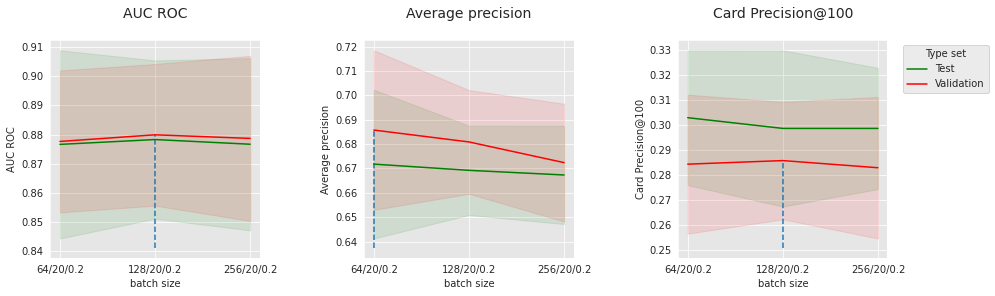

In [77]:
performances_df_nn_subset = performances_df_nn[performances_df_nn['Parameters'].apply(lambda x:x['clf__lr']== 0.001 and x['clf__module__hidden_size']==500 and x['clf__module__num_layers']==2 and x['clf__module__p']==0.2 and x['clf__max_epochs']==20).values]
summary_performances_nn_subset=get_summary_performances(performances_df_nn_subset, parameter_column_name="Parameters summary")
indexes_summary = summary_performances_nn_subset.index.values
indexes_summary[0] = 'Best estimated parameters'
summary_performances_nn_subset.rename(index = dict(zip(np.arange(len(indexes_summary)),indexes_summary)))
get_performances_plots(performances_df_nn_subset, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="batch size",
                       summary_performances=summary_performances_nn_subset)

First, if we fix the number of epochs to 20, the dropout level to 0.2, the lower batch size leads to better results for average precision and card precision on the test set, whereas there is a sweet spot according to AUC-ROC. In fact, the optimal batch size is strongly connected to other optimizer parameters. Often, a larger batch size requires a larger number of epochs. To verify that, let us visualize the same plots but with the number of epochs to 40.

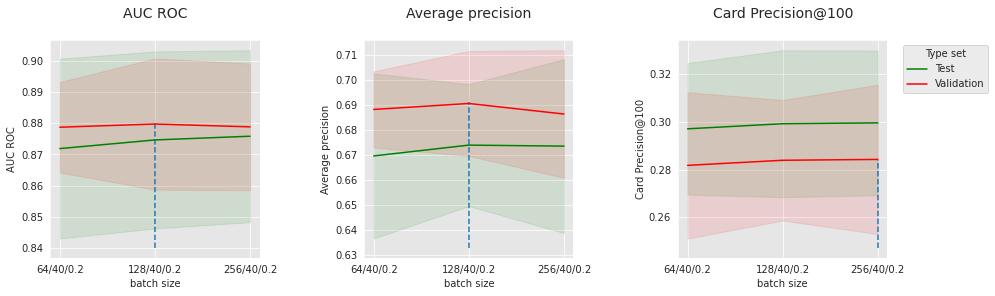

In [78]:
performances_df_nn_subset = performances_df_nn[performances_df_nn['Parameters'].apply(lambda x:x['clf__lr']== 0.001 and x['clf__module__hidden_size']==500 and x['clf__module__num_layers']==2 and x['clf__module__p']==0.2 and x['clf__max_epochs']==40).values]
summary_performances_nn_subset=get_summary_performances(performances_df_nn_subset, parameter_column_name="Parameters summary")
indexes_summary = summary_performances_nn_subset.index.values
indexes_summary[0] = 'Best estimated parameters'
summary_performances_nn_subset.rename(index = dict(zip(np.arange(len(indexes_summary)),indexes_summary)))
get_performances_plots(performances_df_nn_subset, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="batch size",
                       summary_performances=summary_performances_nn_subset)

With this higher number of epochs, the optimal batch size is now globally higher. Let us now do the contrary, i.e. fix the batch size to some value (e.g. 64) and visualize the impact of the number of epochs.

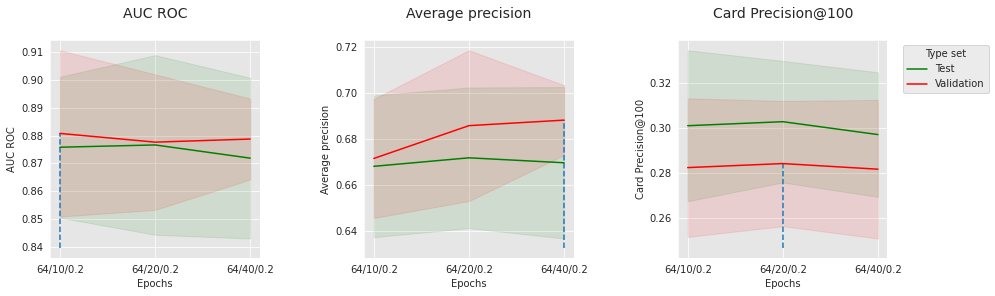

In [70]:
performances_df_nn_subset = performances_df_nn[performances_df_nn['Parameters'].apply(lambda x:x['clf__lr']== 0.001 and x['clf__module__hidden_size']==500 and x['clf__module__num_layers']==2 and x['clf__module__p']==0.2 and x['clf__batch_size']==64).values]
summary_performances_nn_subset=get_summary_performances(performances_df_nn_subset, parameter_column_name="Parameters summary")
indexes_summary = summary_performances_nn_subset.index.values
indexes_summary[0] = 'Best estimated parameters'
summary_performances_nn_subset.rename(index = dict(zip(np.arange(len(indexes_summary)),indexes_summary)))
get_performances_plots(performances_df_nn_subset, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Epochs",
                       summary_performances=summary_performances_nn_subset)

The optimal number of epochs also depends on the metric and has a sweet spot strongly connected to the choice of other hyperparameters.

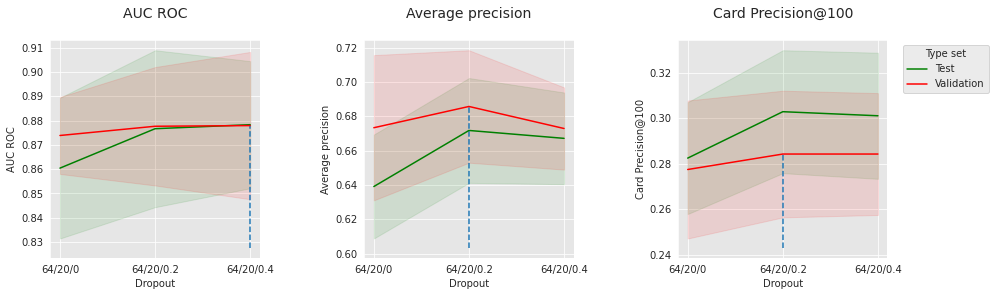

In [73]:
performances_df_nn_subset = performances_df_nn[performances_df_nn['Parameters'].apply(lambda x:x['clf__lr']== 0.001 and x['clf__module__hidden_size']==500 and x['clf__module__num_layers']==2 and x['clf__max_epochs']==20 and x['clf__batch_size']==64).values]
summary_performances_nn_subset=get_summary_performances(performances_df_nn_subset, parameter_column_name="Parameters summary")
indexes_summary = summary_performances_nn_subset.index.values
indexes_summary[0] = 'Best estimated parameters'
summary_performances_nn_subset.rename(index = dict(zip(np.arange(len(indexes_summary)),indexes_summary)))
get_performances_plots(performances_df_nn_subset, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Dropout",
                       summary_performances=summary_performances_nn_subset)

parameters_dict=dict(performances_df_nn['Parameters'])
performances_df_nn['Parameters summary']=[str(parameters_dict[i]['clf__lr'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__batch_size'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__max_epochs'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__module__p'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__module__num_layers'])
                                   for i in range(len(parameters_dict))]

As for the dropout, it helps generalize and improve the valid/test metrics. However, when the dropout value is too high (0.4), it can deteriorate the results, e.g. by limiting the fitting power or by requiring a larger number of epochs.

## Saving of results 

Let us save the performance results and execution times of the neural network models in a Python pickle format. 

In [74]:
performances_df_dictionary={
    "Neural Network": performances_df_nn
}

execution_times=[execution_time_nn]

filehandler = open('performances_model_selection_nn.pkl', 'wb') 
pickle.dump((performances_df_dictionary, execution_times), filehandler)
filehandler.close()

## Benchmark summary

Let us finally retrieve the performance results obtained in [Chapter 5](Model_Selection_Comparison_Performances) with decision tree, logistic regression, random forest and XGBoost, and compare them with those obtained with a feed-forward neural network. The results can be retrieved by loading the `performances_model_selection.pkl` and `performances_model_selection_nn.pkl` pickle files, and summarized with the `get_summary_performances` function.

In [7]:
# Carga los resultados de rendimiento para árbol de decisión, regresión logística, bosque aleatorio y XGBoost
filehandler = open('../Chapter_5_ModelValidationAndSelection/performances_model_selection.pkl', 'rb') 
(performances_df_dictionary, execution_times) = pickle.load(filehandler)

# Carga los resultados de rendimiento para red neuronal feed-forward
filehandler = open('performances_model_selection_nn.pkl', 'rb') 
(performances_df_dictionary_nn, execution_times_nn) = pickle.load(filehandler)


In [15]:
performances_df_dt=performances_df_dictionary['Decision Tree']
summary_performances_dt=get_summary_performances(performances_df_dt, parameter_column_name="Parameters summary")

performances_df_lr=performances_df_dictionary['Logistic Regression']
summary_performances_lr=get_summary_performances(performances_df_lr, parameter_column_name="Parameters summary")

performances_df_rf=performances_df_dictionary['Random Forest']
summary_performances_rf=get_summary_performances(performances_df_rf, parameter_column_name="Parameters summary")

performances_df_xgboost=performances_df_dictionary['XGBoost']
summary_performances_xgboost=get_summary_performances(performances_df_xgboost, parameter_column_name="Parameters summary")

performances_df_nn=performances_df_dictionary_nn['Neural Network']
summary_performances_nn=get_summary_performances(performances_df_nn, parameter_column_name="Parameters summary")

summary_test_performances = pd.concat([summary_performances_dt.iloc[2,:],
                                       summary_performances_lr.iloc[2,:],
                                       summary_performances_rf.iloc[2,:],
                                       summary_performances_xgboost.iloc[2,:],
                                       summary_performances_nn.iloc[2,:],
                                      ],axis=1)

summary_test_performances.columns=['Decision Tree', 'Logistic Regression', 'Random Forest', 'XGBoost', 'Neural Network']


The results are summarized in a `summary_test_performances` table. Rows provide the average performance results on the test sets in terms of AUC ROC, Average Precision and CP@100. 

In [16]:
summary_test_performances

,Decision Tree,Logistic Regression,Random Forest,XGBoost,Neural Network
AUC ROC,0.797+/-0.01,0.868+/-0.02,0.87+/-0.02,0.869+/-0.01,0.876+/-0.01
Average precision,0.579+/-0.01,0.623+/-0.02,0.678+/-0.01,0.687+/-0.01,0.675+/-0.01
Card Precision@100,0.284+/-0.0,0.297+/-0.01,0.299+/-0.01,0.303+/-0.01,0.303+/-0.02


Overall, it appears that our simple feed-forward neural network is a good competitor in terms of predictive performance for the fraud detection problem, providing the best performances in terms of AUC ROC and CP@100, and competitive performances in terms of Average Precision. Moreover, it benefits from many advantages (e.g. its ability for incremental learning), as mentioned in the previous section.

## Conclusion

This section gave an overview of how to design a feed-forward neural network for fraud detection. Comparatively to classical machine learning models, neural networks have an infinite set of hyperparameters. This modularity in the design has a lot of advantages in terms of expressivity but it comes at the cost of a time-consuming hyper optimization of the architecture, the activations, the loss, the optimizers, the preprocessing, etc. Nevertheless, there are many ways to automate hyper optimization and architecture design, for instance with AutoML including Neural Architecture Search (or NAS) {cite}`elsken2019neural`.

Here only the top of the iceberg is covered. There are many other aspects to consider even with such a simple neural network. Many of them can be found in good practice guides and generally also apply to fraud detection. Some are even specific to problems like the latter. An important one is to manage imbalance (refer to Chapter 6 for more details): it can be done with neural networks by replacing binary cross-entropy with a weighted BCE (putting more importance on the loss terms associated with fraud samples) or with focal loss, a variant of cross-entropy specifically designed to automatically focus on under-represented samples. Another way is to implement a custom Dataloader with a [balanced sampler](https://github.com/ufoym/imbalanced-dataset-sampler).

The rest of the chapter rather focuses on different types of neural network models like autoencoders or sequential models and the way they can be used in a fraud detection context.


---

## Autoencoders


(Autoencoders)=
# Autoencoders and anomaly detection

This section explores the potential usage of autoencoders in the context of credit card fraud detection. 

## Definition and usage

An autoencoder is a special type of deep learning architecture used to learn representations of data based solely on descriptive features. The representation, which is a transformation of the raw data, is learned with the objective to reconstruct the original data the most accurately. This representation learning strategy can be used for dimensionality reduction, denoising, or even generative applications. 

An autoencoder can be divided into two parts:
* The **encoder part** that maps the input into the representation, also referred to as the "code" or the "bottleneck".
* The **decoder that** maps the code to a reconstruction of the input.

![Autoencoder](./images/autoencoder.png)

The encoder and decoder can have complex architectures like recurrent neural networks when dealing with sequential data or convolutional neural networks when dealing with images. But in their simplest form, they are multi-layer feed-forward neural networks. The dimension of the code, which is also the input of the decoder, can be fixed arbitrarily. This dimension is generally chosen to be lower than the original input dimension to reduce the dimensionality and to learn underlying meta variables. The dimension of the output of the decoder is the same as the input of the encoder because its purpose is to reconstruct the input.  

The architecture is generally trained end-to-end by optimizing the input reconstruction, i.e. by minimizing a loss that measures a difference between the model's output and the input. It can be trained with any unlabeled data. Note that when the autoencoder is "deep", i.e. there are intermediate layers $h_2$ and $h_2'$ respectively between the input $x$ and the bottleneck $h$ and between the bottleneck and the output $y$ (like in the figure above), one can train the layers successively instead of simultaneously. More precisely, one can first consider a submodel with only $x$, $h_2$ and $y$ and train it to reconstruct the input from the intermediate code $h_2$. Then, consider a second submodel with only $h_2$, $h$ and $h_2'$ and train it to reconstruct the intermediate code from the code $h$. Finally, fine-tune the whole model with $x$, $h_2$, $h$, $h_2'$ and $y$ to reconstruct the input.

Autoencoders can be used as techniques for unsupervised or semi-supervised anomaly detection, which led them to be used multiple times for credit card fraud detection {cite}`an2015variational,zhou2017anomaly`. 


### Anomaly detection

Although not detailed before, fraud detection can be performed with both supervised and unsupervised techniques {cite}`carcillo2019combining,veeramachaneni2016ai`, as it is a special instance of a broader problem referred to as anomaly detection or outlier detection. The latter generally includes techniques to identify items that are rare or differ significantly from the "normal" behavior, observable in the majority of the data. 

And one can easily see how a credit card fraud can be defined as an anomaly in transactions. These anomalies can be rare events or unexpected bursts in the activity of a single cardholder behavior, or specific patterns, not necessarily rare, in the global consumers' behavior. Rare events or outliers can be detected with unsupervised techniques that learn the normality and which are able to estimate discrepancy to this normality. But detection of other types of anomaly can require supervised techniques with proper training.

Therefore, one can think of three types of anomaly detection techniques:

* Supervised techniques that were widely explored in previous sections and chapters. These techniques require annotations on data that consist of two classes, "normal" (or "genuine") and "abnormal" (or "fraud"), and they learn to discriminate between those classes.
* Unsupervised techniques that aim at detecting anomalies by modeling the majority behavior and considering it as "normal". Then they detect the "abnormal" or fraudulent behavior by searching for examples that do not fit well to the normal behavior.  
* Semi-supervised techniques that are in between the two above cases and that can learn from both unlabeled and labeled data to detect fraudulent transactions. 

An autoencoder can be used to model the normal behavior of data and detect outliers using the reconstruction error as an indicator. In particular, one way to do so is to train it to globally reconstruct transactions in a dataset. The normal trend that is observed in the majority of transactions will be better approximated than rare events. Therefore, the reconstruction error of "normal" data will be lower than the reconstruction error of outliers.

An autoencoder can therefore be considered as an unsupervised technique for fraud detection. In this section, we will implement and test it for both semi-supervised and unsupervised fraud detection. 

### Representation learning

Other than unsupervised anomaly detection, an autoencoder can simply be used as a general representation learning method for credit card transaction data. In a more complex manner than PCA, an autoencoder will learn a transformation from the original feature space to a representation space with new variables that encodes all the useful information to reconstruct the original data. 

If the dimension of the code is chosen to be 2 or 3, one can visualize the transaction in the novel 2D/3D space. Otherwise, the code can also be used for other purposes, like:

* Clustering: Clustering can be performed on the code instead of the original features. Groups learned from the clustering can be useful to characterize the types of behaviors of consumers or fraudsters.
* Additional or replacement variables: The code can be used as replacement variables, or additional variables, to train any supervised learning model for credit card fraud detection. 

### Content of the section

The following puts into practice the use of autoencoders for credit card fraud detection. It starts by defining the data structures for unlabeled transactions. It then implements and evaluates an autoencoder for unsupervised fraud detection. The autoencoder is then used to compute transaction representation for visualization and clustering. Finally, we explore a semi-supervised strategy for fraud detection.

Let us dive into it by making all necessary imports.

In [1]:
# Inicialización: Cargar funciones compartidas y datos simulados 

# Carga las funciones compartidas
!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.py
%run shared_functions.py

# Obtiene datos simulados del repositorio de Github
if not os.path.exists("simulated-data-transformed"):
    pass
    !git clone https://github.com/Fraud-Detection-Handbook/simulated-data-transformed


This section reuses some "deep learning" specific material that was implemented in the previous section. It includes the evaluation function, the preparation of generators, the early-stopping strategy, the training loop, and so on. This material has been added to the `shared functions`.

## Data loading

The same experimental setup as the previous section is used for our exploration, i.e. a fixed training and validation period, and the same features from the transformed simulated data (`simulated-data-transformed/data/`).

In [2]:
DIR_INPUT='simulated-data-transformed/data/' 

BEGIN_DATE = "2018-06-11"
END_DATE = "2018-09-14"

print("Load  files")
%time transactions_df=read_from_files(DIR_INPUT, BEGIN_DATE, END_DATE)
print("{0} transactions loaded, containing {1} fraudulent transactions".format(len(transactions_df),transactions_df.TX_FRAUD.sum()))

output_feature="TX_FRAUD"

input_features=['TX_AMOUNT','TX_DURING_WEEKEND', 'TX_DURING_NIGHT', 'CUSTOMER_ID_NB_TX_1DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW', 'CUSTOMER_ID_NB_TX_7DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW', 'CUSTOMER_ID_NB_TX_30DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW', 'TERMINAL_ID_NB_TX_1DAY_WINDOW',
       'TERMINAL_ID_RISK_1DAY_WINDOW', 'TERMINAL_ID_NB_TX_7DAY_WINDOW',
       'TERMINAL_ID_RISK_7DAY_WINDOW', 'TERMINAL_ID_NB_TX_30DAY_WINDOW',
       'TERMINAL_ID_RISK_30DAY_WINDOW']

Load  files
CPU times: user 387 ms, sys: 282 ms, total: 669 ms
Wall time: 760 ms
919767 transactions loaded, containing 8195 fraudulent transactions


In [3]:
# Establece el día inicial para el período de entrenamiento y los deltas
start_date_training = datetime.datetime.strptime("2018-07-25", "%Y-%m-%d")
delta_train=7
delta_delay=7
delta_test=7


delta_valid = delta_test

start_date_training_with_valid = start_date_training+datetime.timedelta(days=-(delta_delay+delta_valid))

(train_df, valid_df)=get_train_test_set(transactions_df,start_date_training_with_valid,
                                       delta_train=delta_train,delta_delay=delta_delay,delta_test=delta_test)

# By default, scales input data
(train_df, valid_df)=scaleData(train_df, valid_df,input_features)


## Autoencoder implementation

For the sake of consistency, the implementation of the autoencoders will be done with the `PyTorch` library. As usual, a seed will be used as follows to ensure reproducibility:

In [4]:
SEED = 42

if torch.cuda.is_available():
    DEVICE = "cuda" 
else:
    DEVICE = "cpu"
print("Selected device is",DEVICE)

seed_everything(SEED)

Selected device is cuda


Let us also convert our features and labels into torch tensors.

In [5]:
x_train = torch.FloatTensor(train_df[input_features].values)
x_valid = torch.FloatTensor(valid_df[input_features].values)
y_train = torch.FloatTensor(train_df[output_feature].values)
y_valid = torch.FloatTensor(valid_df[output_feature].values)

The autoencoder has the same input as the baseline feed-forward neural network but a different output. Instead of the fraud/genuine label, its target will be the same as the input. Therefore, the experiments here will not rely on the `FraudDataset` defined before but on a new Dataset: `FraudDatasetUnsupervised`, which only receives the descriptive features of the transaction `x` and returns it as both input and output. 

In [6]:
class FraudDatasetUnsupervised(torch.utils.data.Dataset):
    
    def __init__(self, x,output=True):
        'Initialization'
        self.x = x
        self.output = output

    def __len__(self):
        'Returns the total number of samples'
        return len(self.x)

    def __getitem__(self, index):
        'Generates one sample of data'
        # Selecciona el índice de la muestra
        item = self.x[index].to(DEVICE)
        if self.output:
            return item, item
        else:
            return item


In [7]:
training_set = FraudDatasetUnsupervised(x_train)
valid_set = FraudDatasetUnsupervised(x_valid)

This Dataset can also be turned into `DataLoaders` with the function `prepare_generators` from the shared functions.

In [8]:
training_generator,valid_generator = prepare_generators(training_set, valid_set, batch_size = 64)

The second and main element in our deep learning pipeline is the model/module. Since our data are tabular and each sample is a vector, we will resort to a regular feed-forward autoencoder. Its definition is very similar to our supervised feed-forward network for fraud detection, except that the output has as many neurons as the input, with linear activations, instead of a single neuron with sigmoid activation. An intermediate layer, before the representation layer, will also be considered such that the overall succession of layers with their dimensions (`input_dim`, `output_dim`) are the following:

* A first input layer with ReLu activation (`input_size`, `intermediate_size`)
* A second layer with ReLu activation (`intermediate_size`, `code_size`)
* A third layer with ReLu activation (`code_size`, `intermediate_size`)
* An output layer with linear activation (`intermediate_size`, `input_size`)

In [9]:
class SimpleAutoencoder(torch.nn.Module):
    
        def __init__(self, input_size, intermediate_size, code_size):
            super(SimpleAutoencoder, self).__init__()
            # parameters
            self.input_size = input_size
            self.intermediate_size = intermediate_size           
            self.code_size  = code_size
            
            self.relu = torch.nn.ReLU()   
            
            #encoder
            self.fc1 = torch.nn.Linear(self.input_size, self.intermediate_size)
            self.fc2 = torch.nn.Linear(self.intermediate_size, self.code_size)
            
            #decoder 
            self.fc3 = torch.nn.Linear(self.code_size, self.intermediate_size)            
            self.fc4 = torch.nn.Linear(self.intermediate_size, self.input_size)
            
            
        def forward(self, x):
            
            hidden = self.fc1(x)
            hidden = self.relu(hidden)
            
            code = self.fc2(hidden)
            code = self.relu(code)
 
            hidden = self.fc3(code)
            hidden = self.relu(hidden)
            
            output = self.fc4(hidden)
            #linear activation in final layer)            
            
            return output

The third element of our pipeline is the optimization problem. The underlying machine learning problem is a regression here, where the predicted and expected outputs are real-valued variables. Therefore, the most adapted loss function is the mean squared error `torch.nn.MSELoss`. 

In [11]:
criterion = torch.nn.MSELoss().to(DEVICE)

## Using the autoencoder for unsupervised fraud detection

As explained in the introduction, the autoencoder's goal is to predict the input from the input. Therefore, one cannot directly use its prediction for fraud detection. Instead, the idea is to use its reconstruction error, i.e. the mean squared error (MSE) between the input and the output, as an indicator for fraud likelihood. The higher the error, the higher the risk score. Therefore, the reconstruction error can be considered as a predicted fraud risk score, and its relevance can be directly measured with any threshold-free metric.

For that purpose, let us define a function `per_sample_mse` that will compute the MSE of a `model` for each sample provided by a `generator`: 

In [14]:
def per_sample_mse(model, generator):
    
    model.eval()
    criterion = torch.nn.MSELoss(reduction="none")
    batch_losses = []
    
    for x_batch, y_batch in generator:
        # Forward pass
        y_pred = model(x_batch)
        # Calcula la pérdida
        loss = criterion(y_pred.squeeze(), y_batch)
        loss_app = list(torch.mean(loss,axis=1).detach().cpu().numpy())
        batch_losses.extend(loss_app)
    
    return batch_losses


Esto es lo que sucede al probarlo en las muestras de validación con un autoencoder no entrenado. Usemos 100 neuronas en la capa intermedia y 20 neuronas en la capa de representación:

In [15]:
seed_everything(SEED)
model = SimpleAutoencoder(x_train.shape[1], 100, 20).to(DEVICE)
losses = per_sample_mse(model, valid_generator)

Antes de entrenarlo, aquí están los valores de pérdida para las primeras cinco muestras, y la pérdida promedio general.

In [16]:
print(losses[0:5])
print(np.mean(losses))

[0.6754841, 0.7914626, 1.1697073, 0.807015, 1.258897]
0.9325166


Con pesos aleatorios en sus capas, el autoencoder no entrenado es bastante malo en la reconstrucción. Tiene un error cuadrático de 0.93 en promedio para las variables de transacción estandarizadas. 

Entrenémoslo ahora y veamos cómo evoluciona esto. Como en la sección anterior, el proceso es el siguiente:
* Preparar los generadores.
* Definir el criterio.
* Instanciar el modelo.
* Realizar varios bucles de optimización (con una técnica de optimización como descenso de gradiente con Adam) en los datos de entrenamiento.
* Detener la optimización con parada temprana usando datos de validación.

Todos estos pasos están implementados en la función compartida `training_loop` definida en la sección anterior.

In [17]:
seed_everything(SEED)

training_generator,valid_generator = prepare_generators(training_set, valid_set, batch_size = 64)

criterion = torch.nn.MSELoss().to(DEVICE)

model = SimpleAutoencoder(len(input_features), 100,20).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr = 0.0001)

In [18]:
model,training_execution_time,train_losses,valid_losses = training_loop(model,
                                                                        training_generator,
                                                                        valid_generator,
                                                                        optimizer,
                                                                        criterion,
                                                                        max_epochs=500,
                                                                        verbose=True)


Epoch 0: train loss: 0.44459555436274745
valid loss: 0.11862650322295278
New best score: 0.11862650322295278

Epoch 1: train loss: 0.08513386782087799
valid loss: 0.043951269408148495
New best score: 0.043951269408148495

Epoch 2: train loss: 0.033392506879513964
valid loss: 0.023117523054119016
New best score: 0.023117523054119016

Epoch 3: train loss: 0.020011974392676046
valid loss: 0.014828811516690124
New best score: 0.014828811516690124

Epoch 4: train loss: 0.012006818789661101
valid loss: 0.007833917340253545
New best score: 0.007833917340253545

Epoch 5: train loss: 0.006807905782315075
valid loss: 0.0051493146614543074
New best score: 0.0051493146614543074

Epoch 6: train loss: 0.005084841840688574
valid loss: 0.003938508272181199
New best score: 0.003938508272181199

Epoch 7: train loss: 0.0038803787977678655
valid loss: 0.003023105256559704
New best score: 0.003023105256559704

Epoch 8: train loss: 0.002949208616150853
valid loss: 0.002528339391192574
New best score: 0.002

In [19]:
losses = per_sample_mse(model, valid_generator)
print(losses[0:5])
print(np.mean(losses))

[2.0756474e-05, 2.1485403e-05, 3.70714e-05, 3.204957e-05, 4.3641372e-05]
8.030665e-05


In [21]:
print(x_train[0])
print(model(x_train[0].to(DEVICE)))

tensor([-0.1323, -0.6306,  2.1808, -0.3003,  0.1241, -1.6917,  0.5035, -1.6630,
        -0.0482, -0.9810, -0.0816, -1.9895, -0.1231, -0.9719, -0.1436])
tensor([-0.1373, -0.6222,  2.1850, -0.3158,  0.1244, -1.6941,  0.5060, -1.6674,
        -0.0407, -0.9684, -0.0796, -1.9885, -0.1316, -0.9716, -0.1380],
       device='cuda:0', grad_fn=<AddBackward0>)


Cuando está entrenado, el autoencoder es mucho mejor en codificar/decodificar una transacción. Ahora obtiene un error cuadrático muy bajo (0.00008) en promedio para nuestras variables de transacción estandarizadas. Además, el ejemplo anterior (con `x_train[0]`) ilustra qué tan bien la transacción reconstruida es similar a la transacción de entrada. 

Ahora la pregunta restante es la siguiente: ¿los fraudes se reconstruyen menos bien que las transacciones genuinas de tal manera que el error de reconstrucción se puede usar como un indicador del riesgo de fraude?

Para responder, se puede calcular el error cuadrático promedio para transacciones fraudulentas y genuinas por separado. 

In [22]:
genuine_losses = np.array(losses)[y_valid.cpu().numpy() == 0]
fraud_losses = np.array(losses)[y_valid.cpu().numpy() == 1]
print("Average fraud reconstruction error:", np.mean(fraud_losses))
print("Average genuine reconstruction error:", np.mean(genuine_losses))

Average fraud reconstruction error: 0.0018339771
Average genuine reconstruction error: 6.9023976e-05


Parece que los fraudes efectivamente se reconstruyen menos bien que las transacciones genuinas, lo cual es muy alentador. Calculemos ahora el AUC ROC, la precisión promedio, y card precision@100 en el conjunto de validación considerando el error de reconstrucción como una puntuación de fraude predicha.

In [23]:
predictions_df=valid_df
predictions_df['predictions']=losses
    
performance_assessment(predictions_df, top_k_list=[100])

,AUC ROC,Average precision,Card Precision@100
0,0.836,0.18,0.217


Aunque menos preciso que las técnicas supervisadas cubiertas anteriormente, este método no supervisado conduce a resultados alentadores y es mucho más preciso que el clasificador aleatorio.

## Comparación con otro baseline no supervisado: Isolation Forest

El autoencoder tiene un AUC ROC muy alto sin hacer uso de las etiquetas durante el entrenamiento. Para contrastar este resultado y como verificación, es interesante implementar y probar otro baseline no supervisado popular.

Isolation Forest es una técnica de detección de anomalías de última generación que se basa en modelos basados en árboles. Calcula, para cada muestra de datos, una puntuación de anomalía que refleja qué tan atípica es la muestra. Para calcular esta puntuación, el algoritmo intenta aislar la muestra del resto del conjunto de datos recursivamente: elige un corte aleatorio (par característica-umbral), y evalúa si permite que la muestra en cuestión sea aislada. Si es así, el algoritmo se detiene. De lo contrario, agrega otro corte, y repite el proceso hasta que la muestra esté aislada del resto. Esta partición recursiva de datos se puede representar como un árbol de decisión y el número de cortes necesarios para aislar una muestra se puede considerar como la puntuación de anomalía. Cuanto menor sea el número de cortes (es decir, más fácil es aislar el punto de datos), más probable es que la muestra sea un valor atípico.

Este algoritmo está implementado en `sklearn` bajo la clase `sklearn.ensemble.IsolationForest`. Entrenémoslo en los datos de entrenamiento y evaluemos la puntuación de anomalía de los datos de validación. En estos últimos, la puntuación de anomalía de una muestra se calcula a partir de la profundidad promedio de las hojas alcanzadas por ella.

In [24]:
from sklearn.ensemble import IsolationForest

anomalyclassifier = IsolationForest(random_state=SEED, n_estimators=10)
anomalyclassifier.fit(train_df[input_features])

IsolationForest(n_estimators=10, random_state=42)

In [25]:
predictions_df = valid_df
predictions_df['predictions'] = -anomalyclassifier.score_samples(valid_df[input_features])
    
performance_assessment(predictions_df, top_k_list=[100])

,AUC ROC,Average precision,Card Precision@100
0,0.808,0.164,0.19


Podemos ver que este baseline no supervisado de última generación proporciona rendimientos que están cerca (ligeramente más bajos) de los del autoencoder.

## Representación de transacciones, visualización y agrupamiento

Además de su capacidad para detectar anomalías, el autoencoder tiene otras ventajas, como se mencionó en la introducción. En particular, después del entrenamiento, se puede usar solo la parte del codificador para obtener representaciones de las transacciones para fines de visualización o agrupamiento. Para eso, entrenemos un autoencoder con una dimensión de código de 2.

In [26]:
seed_everything(SEED)

training_generator,valid_generator = prepare_generators(training_set, valid_set, batch_size = 64)
criterion = torch.nn.MSELoss().to(DEVICE)
small_model = SimpleAutoencoder(len(input_features), 100,2).to(DEVICE)
optimizer = torch.optim.Adam(small_model.parameters(), lr = 0.0001)

small_model,training_execution_time,train_losses,valid_losses = training_loop(small_model,
                                                                              training_generator,
                                                                              valid_generator,
                                                                              optimizer,
                                                                              criterion,
                                                                              max_epochs=500,
                                                                              verbose=True)



Epoch 0: train loss: 0.7684247642185674
valid loss: 0.5768663428194536
New best score: 0.5768663428194536

Epoch 1: train loss: 0.5679652139003145
valid loss: 0.493461870886589
New best score: 0.493461870886589

Epoch 2: train loss: 0.5022419279095776
valid loss: 0.473104252678449
New best score: 0.473104252678449

Epoch 3: train loss: 0.4897903477769509
valid loss: 0.4661512801393134
New best score: 0.4661512801393134

Epoch 4: train loss: 0.48440276228788937
valid loss: 0.4619032563733273
New best score: 0.4619032563733273

Epoch 5: train loss: 0.4809599176305658
valid loss: 0.45911747171579165
New best score: 0.45911747171579165

Epoch 6: train loss: 0.4785268415000653
valid loss: 0.45734123809090077
New best score: 0.45734123809090077

Epoch 7: train loss: 0.47650860255694527
valid loss: 0.45569751822883314
New best score: 0.45569751822883314

Epoch 8: train loss: 0.47459852245296164
valid loss: 0.4537866956223556
New best score: 0.4537866956223556

Epoch 9: train loss: 0.47209983

valid loss: 0.36578597017650394
New best score: 0.36578597017650394

Epoch 76: train loss: 0.3733352996537152
valid loss: 0.36549377529347526
New best score: 0.36549377529347526

Epoch 77: train loss: 0.37285123603065884
valid loss: 0.36517465775781643
New best score: 0.36517465775781643

Epoch 78: train loss: 0.37245363994264696
valid loss: 0.3646077791524064
New best score: 0.3646077791524064

Epoch 79: train loss: 0.37203873899083295
valid loss: 0.3642017390395774
New best score: 0.3642017390395774

Epoch 80: train loss: 0.37175256421301606
valid loss: 0.3638398566044094
New best score: 0.3638398566044094

Epoch 81: train loss: 0.37134953726432063
valid loss: 0.3634167999192014
New best score: 0.3634167999192014

Epoch 82: train loss: 0.3709514387536003
valid loss: 0.36295943159223254
New best score: 0.36295943159223254

Epoch 83: train loss: 0.3705764208879343
valid loss: 0.36283708996460085
New best score: 0.36283708996460085

Epoch 84: train loss: 0.37014006422992873
valid loss: 


Epoch 151: train loss: 0.35687340736161227
valid loss: 0.35078356940238203
New best score: 0.35078356940238203

Epoch 152: train loss: 0.3566489354431287
valid loss: 0.351060890369728
1  iterations since best score.

Epoch 153: train loss: 0.35646914444279715
valid loss: 0.35075386410853904
New best score: 0.35075386410853904

Epoch 154: train loss: 0.35635819458482826
valid loss: 0.35059281462202957
New best score: 0.35059281462202957

Epoch 155: train loss: 0.3562699848105757
valid loss: 0.3503138803556317
New best score: 0.3503138803556317

Epoch 156: train loss: 0.35617095665083787
valid loss: 0.3504037611797208
1  iterations since best score.

Epoch 157: train loss: 0.3560048634075982
valid loss: 0.3503424207532341
2  iterations since best score.

Epoch 158: train loss: 0.3559037697132869
valid loss: 0.35010807908297886
New best score: 0.35010807908297886

Epoch 159: train loss: 0.3558188352598515
valid loss: 0.3501646858584034
1  iterations since best score.

Epoch 160: train lo


Epoch 227: train loss: 0.3496640003206169
valid loss: 0.3447480450888149
1  iterations since best score.

Epoch 228: train loss: 0.34956770907396567
valid loss: 0.34473640628851177
2  iterations since best score.

Epoch 229: train loss: 0.3495605050035918
valid loss: 0.34430122165406335
New best score: 0.34430122165406335

Epoch 230: train loss: 0.34945341993130413
valid loss: 0.344738097887873
1  iterations since best score.

Epoch 231: train loss: 0.34943006878601207
valid loss: 0.3444186775085053
2  iterations since best score.

Epoch 232: train loss: 0.34933042286914806
valid loss: 0.3448007179902551
3  iterations since best score.
Early stopping


Once trained, to obtain the transactions 2D-representation from the encoder part alone, the idea is to simply apply the first two layers of the Autoencoder.

In [29]:
def compute_representation(x,model):
    x_representation = model.fc1(x)
    x_representation = model.relu(x_representation)
    x_representation = model.fc2(x_representation)
    x_representation = model.relu(x_representation)
    return x_representation

In [30]:
x_train_representation = []
for x_batch, y_batch in training_generator: 
    x_train_representation.append(compute_representation(x_batch, small_model).detach().cpu().numpy())

In [31]:
x_train_representation = np.vstack(x_train_representation)

After this process, the obtained representations of the training data are in 2D:

In [32]:
print(x_train.shape)
print(x_train_representation.shape)

torch.Size([66928, 15])
(66928, 2)


Transactions can be now visualized on a plane (e.g. with different colors for frauds and genuine)

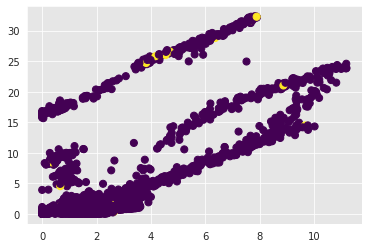

In [33]:
plt.scatter(x_train_representation[:, 0], x_train_representation[:, 1], c=y_train.numpy(), s=50, cmap='viridis')

It is also possible to apply a K-means clustering and vizualize the clusters:

In [34]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=SEED)
kmeans.fit(x_train_representation)
y_kmeans = kmeans.predict(x_train_representation)

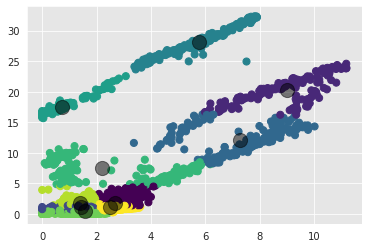

In [35]:
plt.scatter(x_train_representation[:, 0], x_train_representation[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

## Semi-supervised fraud detection

Finally, the autoencoder can be used in a semi-supervised credit card fraud detection system {cite}`carcillo2019combining`. There are two main ways to do this:
* `W1`: The most natural one is to keep the autoencoder as is and train it on all available labeled and unlabeled data. Then, to combine it with a supervised neural network trained only on labeled data. The combination can be done by aggregating the predicted score from the supervised model and the predicted score from the unsupervised model (`W1A`), or more elegantly by providing the unsupervised risk score from the autoencoder (reconstruction error) as an additional variable to the supervised model (`W1B`) as in {cite}`alazizi2020dual`.
* `W2`: Another possibility is to change the architecture of the autoencoder into a hybrid semi-supervised model. More precisely, one can add, to the autoencoder, output neurons similar to those of the supervised neural network from the previous section, and additionally predict them from the code neurons. Therefore, the learned representation (code neurons) will be shared between the decoder network that aims at reconstructing the input and the prediction network that aims at predicting fraud. The first is trained on all samples and the latter is only trained on labeled samples. The intuition with this approach is similar to pre-training in natural language processing: learning a representation that embeds the underlying structure in the input data can help with solving supervised tasks. 

The following explores the `W1B` semi-supervised approach. But first, let us reevaluate here the baseline supervised model without the reconstruction error feature. `FraudDataset` and `SimpleFraudMLPWithDropout` are available in the shared functions and can be directly used here.

In [37]:
seed_everything(SEED)

training_set_supervised = FraudDataset(x_train.to(DEVICE), y_train.to(DEVICE))
valid_set_supervised = FraudDataset(x_valid.to(DEVICE), y_valid.to(DEVICE))

training_generator_supervised,valid_generator_supervised = prepare_generators(training_set_supervised,
                                                                              valid_set_supervised,
                                                                              batch_size=64)

model_supervised = SimpleFraudMLPWithDropout(len(input_features), 1000, 0.2).to(DEVICE)
optimizer = torch.optim.Adam(model_supervised.parameters(), lr = 0.0001)
criterion = torch.nn.BCELoss().to(DEVICE)

model_supervised,training_execution_time,train_losses_dropout,valid_losses_dropout =\
    training_loop(model_supervised,
                  training_generator_supervised,
                  valid_generator_supervised,
                  optimizer,
                  criterion,
                  verbose=True)


Epoch 0: train loss: 0.10161001316804161
valid loss: 0.03556653917487202
New best score: 0.03556653917487202

Epoch 1: train loss: 0.03833597035852419
valid loss: 0.026109349807022047
New best score: 0.026109349807022047

Epoch 2: train loss: 0.031094471842315882
valid loss: 0.02396169698420566
New best score: 0.02396169698420566

Epoch 3: train loss: 0.028757975434966342
valid loss: 0.023352081602938026
New best score: 0.023352081602938026

Epoch 4: train loss: 0.02775647486163834
valid loss: 0.022305768956761052
New best score: 0.022305768956761052

Epoch 5: train loss: 0.026740792337858456
valid loss: 0.021572637600223713
New best score: 0.021572637600223713

Epoch 6: train loss: 0.02606928332959859
valid loss: 0.021479292579320935
New best score: 0.021479292579320935

Epoch 7: train loss: 0.025758702903594215
valid loss: 0.02105785213192019
New best score: 0.02105785213192019

Epoch 8: train loss: 0.02527676529854707
valid loss: 0.020694473186187202
New best score: 0.0206944731861

In [38]:
predictions = []

for x_batch, y_batch in valid_generator_supervised: 
    predictions.append(model_supervised(x_batch.to(DEVICE)).detach().cpu().numpy())

predictions_df=valid_df
predictions_df['predictions']=np.vstack(predictions)
    
performance_assessment(predictions_df, top_k_list=[100])

,AUC ROC,Average precision,Card Precision@100
0,0.859,0.646,0.28


Now, for the `W1B` semi-supervised approach, let us compute the reconstruction error of all transactions with our first autoencoder (stored in `model`) and add it as a new variable in `train_df` and `valid_df`. 

In [39]:
loader_params = {'batch_size': 64,
                 'num_workers': 0}
    
training_generator = torch.utils.data.DataLoader(training_set, **loader_params)
valid_generator = torch.utils.data.DataLoader(valid_set, **loader_params)

train_reconstruction = per_sample_mse(model, training_generator)
valid_reconstruction = per_sample_mse(model, valid_generator)

train_df["reconstruction_error"] = train_reconstruction
valid_df["reconstruction_error"] = valid_reconstruction

Then, we can reevaluate the supervised model with this extra variable.

In [40]:
seed_everything(SEED)

input_features_new = input_features + ["reconstruction_error"]

# Rescale the reconstruction error
(train_df, valid_df)=scaleData(train_df, valid_df, ["reconstruction_error"])

x_train_new = torch.FloatTensor(train_df[input_features_new].values)
x_valid_new = torch.FloatTensor(valid_df[input_features_new].values)

training_set_supervised_new = FraudDataset(x_train_new.to(DEVICE), y_train.to(DEVICE))
valid_set_supervised_new = FraudDataset(x_valid_new.to(DEVICE), y_valid.to(DEVICE))

training_generator_supervised,valid_generator_supervised = prepare_generators(training_set_supervised_new,
                                                                              valid_set_supervised_new,
                                                                              batch_size=64)

model_supervised = SimpleFraudMLPWithDropout(len(input_features_new), 100, 0.2).to(DEVICE)
optimizer = torch.optim.Adam(model_supervised.parameters(), lr = 0.0001)
criterion = torch.nn.BCELoss().to(DEVICE)

model_supervised,training_execution_time,train_losses_dropout,valid_losses_dropout = \
    training_loop(model_supervised,
                  training_generator_supervised,
                  valid_generator_supervised,
                  optimizer,
                  criterion,
                  verbose=True)

predictions = []
for x_batch, y_batch in valid_generator_supervised: 
    predictions.append(model_supervised(x_batch).detach().cpu().numpy())


Epoch 0: train loss: 0.32470558333009425
valid loss: 0.11669875736770734
New best score: 0.11669875736770734

Epoch 1: train loss: 0.0857971908175609
valid loss: 0.050325598816076914
New best score: 0.050325598816076914

Epoch 2: train loss: 0.055031552282206526
valid loss: 0.03683824896140665
New best score: 0.03683824896140665

Epoch 3: train loss: 0.045474566717366785
valid loss: 0.031574366707863705
New best score: 0.031574366707863705

Epoch 4: train loss: 0.03988730701053405
valid loss: 0.028506962655753386
New best score: 0.028506962655753386

Epoch 5: train loss: 0.03588366161686427
valid loss: 0.0264507318495727
New best score: 0.0264507318495727

Epoch 6: train loss: 0.03320539464736019
valid loss: 0.025167095382784395
New best score: 0.025167095382784395

Epoch 7: train loss: 0.03146339780281531
valid loss: 0.024275742485722313
New best score: 0.024275742485722313

Epoch 8: train loss: 0.03083236553407066
valid loss: 0.02372574291110568
New best score: 0.02372574291110568



valid loss: 0.01867632728383006
New best score: 0.01867632728383006

Epoch 74: train loss: 0.022178997785715745
valid loss: 0.018700476872729636
1  iterations since best score.

Epoch 75: train loss: 0.022028937389144593
valid loss: 0.018650301263280863
New best score: 0.018650301263280863

Epoch 76: train loss: 0.02214035027425373
valid loss: 0.018606594060496758
New best score: 0.018606594060496758

Epoch 77: train loss: 0.021738268898102858
valid loss: 0.018632269502983842
1  iterations since best score.

Epoch 78: train loss: 0.02227861989753848
valid loss: 0.01854319557435607
New best score: 0.01854319557435607

Epoch 79: train loss: 0.021809139837872374
valid loss: 0.018610031961443035
1  iterations since best score.

Epoch 80: train loss: 0.022240891229284725
valid loss: 0.018547307454874037
2  iterations since best score.

Epoch 81: train loss: 0.022066849491217958
valid loss: 0.01848699482949196
New best score: 0.01848699482949196

Epoch 82: train loss: 0.021692594942564668
va

In [41]:
predictions_df=valid_df
predictions_df['predictions']=np.vstack(predictions)
    
performance_assessment(predictions_df, top_k_list=[100])

,AUC ROC,Average precision,Card Precision@100
0,0.861,0.651,0.276


The three metrics are very close, with or without the additional feature. They respectively went from 0.859, 0.646 and 0.28 to 0.861, 0.651 and 0.276. The conclusion is therefore mitigated and does not show a significant benefit from this semi-supervised modeling. Nevertheless, keep in mind that, in practice in a different setting, there can be a benefit, especially if the quantity of available unlabeled data is much larger than the quantity of labeled data. 

Also, note that there are several directions for improvement. For example, this semi-supervised technique can be pushed further by training two separate autoencoders, for each class, and by using both reconstruction errors as additional variables. 

## Conclusion

Autoencoders are part of the large deep learning models family. Their goal is to learn representations to reconstruct descriptive variables, so they have been widely used for unsupervised learning problems. Anomaly detection, and in particular fraud detection, can be tackled with unsupervised or semi-supervised techniques. 

In this section, we used the autoencoder, and in particular its reconstruction error, as an indicator for fraud risk. Used solely (unsupervised method), it detects data points that are away from the rest of the distribution, which allows detecting many frauds but also introduces a lot of false alerts (e.g. genuine transactions that have rare characteristics). Therefore, it obtains a decent AUC ROC but low precision-based metrics. Used as an extra variable in a supervised method (semi-supervised usage), it can allow boosting the performance in specific settings.


---

## SequentialModeling


(SequentialModeling)=
# Sequential models and representation learning

In credit card fraud detection, the choice of features is crucial for accurate classification. Considerable research effort has been dedicated to the development of features that are relevant to characterize fraudulent patterns. Feature engineering strategies based on feature aggregations have become commonly adopted {cite}`bahnsen2016feature`. Feature aggregation establishes a connection between the current transaction and other related transactions by computing statistics over their variables. They often originate from complex rules defined from human expertise, and many experiments report that they significantly improve detection {cite}`dal2014learned,jurgovsky2018sequence,dastidar2020nag`.

Using feature aggregation for fraud detection is part of a research topic referred to as "context-aware fraud detection", where one considers the context (e.g. the cardholder history) associated with a transaction to make the decision. This allows, for instance, to give insights into the properties of the transaction relative to the usual purchase patterns of the cardholder and/or terminal, which is intuitively a relevant piece of information. 

## Context-aware fraud detection

The context is established based on a landmark variable, which is in most of the cases the Customer ID. Concretely, one starts by building the sequence of historical transactions, chronologically ordered from the oldest to the current one, that have the same value for the landmark variable as the current transaction. 

![Building the transaction sequence](./images/transaction_sequence.png)


This whole sequence is the raw basis for context-aware approaches. Indeed, the general process relies on the construction of new features or representations for each given transaction based on its contextual sequence. However, approaches can be divided into two broad categories, the first (Expert representations) relying on domain knowledge from experts to create rules and build feature aggregation, and the second (Automatic representations) oriented towards automated feature extraction strategies with deep learning models. 

### Expert representations

To build expert features from the base sequence, a selection layer relying on expert constraints (same Merchant Category code, same Country, more recent than a week, etc.) is first applied to obtain a more specific subsequence. Then, an aggregation function (sum, avg, ...) is computed over the values of a chosen feature (e.g. amount) in the subsequence. For more details, {cite}`bahnsen2016feature` provides a formal definition of such feature aggregations. Expert features are not necessarily transferable in any fraud detection domain since they rely on specific features that might not always be available. Nevertheless, in practice, the landmark features, constraints features, and aggregated features are often chosen from a set of frequent attributes, comprising Time, Amount, Country, Merchant Category, Customer ID, transaction type.

![Expert features creation](./images/expert_agg.png)


### Automatic representations

The other family of context-aware approaches considers the sequence directly as input in a model and lets it automatically learn the right connections to optimize fraud detection. The advantage of not relying on human knowledge to build the relevant features is obviously to save the costly resources and to ease adaptability and maintenance. Moreover, models can be pushed towards large architectures and learn very complex variable relationships automatically from data. However, it requires a sufficiently large dataset to properly identify the relevant patterns. Otherwise, the feature representations are not very accurate or useful. 

A baseline technique for automatic usage of contextual data would be to exploit the transaction sequence in its entirety (e.g. flattening it into a set of features), but this removes the information about the order and could lead to a very high dimensional feature space. A more popular strategy consists of (1) turning the sequences into fixed-size sequences and (2) using a special family of models that are able to deal with sequences naturally and summarizing them into relevant vector representations for fraud classification. 

This strategy is often referred to as sequential learning, the study of learning algorithms for sequential data. The sequential dependency between data points is learned at the algorithmic level. This includes sliding window methods, which often tend to ignore the order between data points within the window, but also models that are designed explicitly to consider the sequential order between consecutive data points (e.g. a Markov Chain). Such models can be found in the family of deep learning architectures under the *recurrent neural networks* category. The link between consecutive elements of the sequence is embedded in the design of the recurrent architecture, where the computation of the hidden state/layer of a more recent event depends on hidden states of previous events. 

![Illustration of a recurrent model](./images/recurrent_model.png)


Sliding window methods include architectures like 1D *convolutional neural networks* (1D-CNN), and sequential methods include architectures like the *long short-term memory* (LSTM). Such architectures have proven to be very efficient in the context of fraud detection in the past {cite}`jurgovsky2018sequence`. 

In this section, the goal is to explore automatic representation learning from cardholders' sequences of transactions and its application in context-aware fraud detection. The content starts with the practical aspects of building the pipeline to manage sequential data. Then, three architectures are successively explored: a 1D-CNN, an LSTM, and a more complex model that uses an LSTM with *Attention* {cite}`bahdanau2014neural`. The section concludes on perspectives of other modeling possibilities such as sequence-to-sequence autoencoders {cite}`sutskever2014sequence,alazizi2020dual`, or other combinations of the explored models. 

## Data processing

With sequence modeling, the building of the data processing pipeline has special importance. In particular, as explained in the introduction, its role is to create the input sequences for the sequential models to learn the representations. 

The most popular landmark variable to establish the sequence is the Customer ID. Indeed, by the very definition of credit card fraud being a payment done by someone other than the cardholder, it makes the most sense to look at the history of the customer in order to determine when a card payment is fraudulent. 

Therefore, the goal here is to establish `Datasets` and `DataLoaders` that provide, given a transaction index in the dataset, the sequence of previous transactions (including the one referred by the index) from the same cardholder. Moreover, since models usually deal with fixed-sized sequences, the sequence length will be a parameter, and sequences that are too long (resp. too short) will be cut (resp. padded).

As usual, let us start by loading a fixed training and validation period from the processed dataset.

In [1]:
# Inicialización: Cargar funciones compartidas y datos simulados 

# Carga las funciones compartidas
!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.py
%run shared_functions.py

# Obtiene datos simulados del repositorio de Github
if not os.path.exists("simulated-data-transformed"):
    pass
    !git clone https://github.com/Fraud-Detection-Handbook/simulated-data-transformed


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 63257  100 63257    0     0   537k      0 --:--:-- --:--:-- --:--:--  532k


In [2]:
DIR_INPUT='simulated-data-transformed/data/' 

BEGIN_DATE = "2018-06-11"
END_DATE = "2018-09-14"

print("Load  files")
%time transactions_df=read_from_files(DIR_INPUT, BEGIN_DATE, END_DATE)
print("{0} transactions loaded, containing {1} fraudulent transactions".format(len(transactions_df),transactions_df.TX_FRAUD.sum()))

output_feature="TX_FRAUD"

input_features=['TX_AMOUNT','TX_DURING_WEEKEND', 'TX_DURING_NIGHT', 'CUSTOMER_ID_NB_TX_1DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW', 'CUSTOMER_ID_NB_TX_7DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW', 'CUSTOMER_ID_NB_TX_30DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW', 'TERMINAL_ID_NB_TX_1DAY_WINDOW',
       'TERMINAL_ID_RISK_1DAY_WINDOW', 'TERMINAL_ID_NB_TX_7DAY_WINDOW',
       'TERMINAL_ID_RISK_7DAY_WINDOW', 'TERMINAL_ID_NB_TX_30DAY_WINDOW',
       'TERMINAL_ID_RISK_30DAY_WINDOW']

Load  files
CPU times: user 311 ms, sys: 237 ms, total: 548 ms
Wall time: 570 ms
919767 transactions loaded, containing 8195 fraudulent transactions


In [3]:
# Establece el día inicial para el período de entrenamiento y los deltas
start_date_training = datetime.datetime.strptime("2018-07-25", "%Y-%m-%d")
delta_train=7
delta_delay=7
delta_test=7


delta_valid = delta_test

start_date_training_with_valid = start_date_training+datetime.timedelta(days=-(delta_delay+delta_valid))

(train_df, valid_df)=get_train_test_set(transactions_df,start_date_training_with_valid,
                                       delta_train=delta_train,delta_delay=delta_delay,delta_test=delta_test)

# By default, scales input data
(train_df, valid_df)=scaleData(train_df, valid_df,input_features)


In [4]:
input_features

['TX_AMOUNT',
 'TX_DURING_WEEKEND',
 'TX_DURING_NIGHT',
 'CUSTOMER_ID_NB_TX_1DAY_WINDOW',
 'CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW',
 'CUSTOMER_ID_NB_TX_7DAY_WINDOW',
 'CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW',
 'CUSTOMER_ID_NB_TX_30DAY_WINDOW',
 'CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW',
 'TERMINAL_ID_NB_TX_1DAY_WINDOW',
 'TERMINAL_ID_RISK_1DAY_WINDOW',
 'TERMINAL_ID_NB_TX_7DAY_WINDOW',
 'TERMINAL_ID_RISK_7DAY_WINDOW',
 'TERMINAL_ID_NB_TX_30DAY_WINDOW',
 'TERMINAL_ID_RISK_30DAY_WINDOW']

This time, additionally to the above features, building the sequences will require two additional fields from the DataFrames:
* `CUSTOMER_ID`: the landmark variable that will be used to select past transactions.
* `TX_DATETIME`: the time variable that will allow building sequences in chronological order.

In [5]:
dates = train_df['TX_DATETIME'].values

In [6]:
customer_ids = train_df['CUSTOMER_ID'].values

There are multiple ways to implement sequence creation for training/validation. One way is to precompute, for each transaction, the indices of the previous transactions of the sequence and to store them. Then, to build the sequences of features on the fly from the indices. 

Here we propose some steps to proceed but keep in mind that other solutions are just as valid.

### Estableciendo la longitud de la secuencia

The first step is to set a sequence length. In the literature, 5 or 10 are two values that are often chosen {cite}`jurgovsky2018sequence`. This can later be a parameter to tune but here, let us arbitrarily set it to 5 to begin with. 


In [7]:
seq_len = 5

### Ordering elements chronologically

In our case, transactions are already sorted, but in the most general case, to build the sequences, it is necessary to sort all transactions chronologically and keep the sorting indices:

In [8]:
indices_sort = np.argsort(dates)
sorted_dates = dates[indices_sort]
sorted_ids = customer_ids[indices_sort]

### Separating data according to the landmark variable (Customer ID)

After sorting, the dataset is a large sequence with all transactions from all cardholders. We can separate it into several sequences that each contain only the transactions of a single cardholder. Finally, each customer sequence can be turned into several fixed-size sequences using a sliding window and padding. 

To separate the dataset, let us get the list of customers:

In [9]:
unique_customer_ids = np.unique(sorted_ids)

In [10]:
unique_customer_ids[0:10]

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

For each customer, the associated subsequence can be selected with a boolean mask. Here is for example the sequence of transaction IDs for customer `0`.

In [11]:
idx = 0
current_customer_id = unique_customer_ids[idx]
customer_mask = sorted_ids == current_customer_id
# this is the full sequence of transaction indices (after sort) for customer 0
customer_full_seq = np.where(customer_mask)[0]
# this is the full sequence of transaction indices (before sort) for customer 0
customer_full_seq_original_indices = indices_sort[customer_full_seq]
customer_full_seq_original_indices

array([ 1888, 10080, 12847, 15627, 18908, 22842, 37972, 42529, 44495,
       48980, 58692, 63977])

### Turning a customer sequence into fixed size sequences

The above sequence is the whole sequence for customer `0`. But the goal is to have, for each transaction `i` of this sequence, a fixed size sequence that ends with transaction `i`, which will be used as input in the sequential model to predict the label of transaction `i`. In the example above:
* For transaction 1888: the 4 previous transactions are [none,none,none,none] (Note: none can be replaced with a default value like -1). So the sequence [none, none, none, none, 1888] will be created.
* For transaction 10080, the sequence will be [none, none, none, 1888, 10080]
* ...
* For transaction 37972, the sequence will be [12847, 15627, 18908, 22842, 37972]
* Etc.

Using a sliding window (or rolling window) allows to obtain those sequences:

In [12]:
def rolling_window(array, window):
    a = np.concatenate([np.ones((window-1,))*-1,array])
    shape = a.shape[:-1] + (a.shape[-1] - window + 1, window)
    strides = a.strides + (a.strides[-1],)
    return np.lib.stride_tricks.as_strided(a, shape=shape, strides=strides).astype(int)

In [13]:
customer_all_seqs = rolling_window(customer_full_seq_original_indices,seq_len)

In [14]:
customer_all_seqs

array([[   -1,    -1,    -1,    -1,  1888],
       [   -1,    -1,    -1,  1888, 10080],
       [   -1,    -1,  1888, 10080, 12847],
       [   -1,  1888, 10080, 12847, 15627],
       [ 1888, 10080, 12847, 15627, 18908],
       [10080, 12847, 15627, 18908, 22842],
       [12847, 15627, 18908, 22842, 37972],
       [15627, 18908, 22842, 37972, 42529],
       [18908, 22842, 37972, 42529, 44495],
       [22842, 37972, 42529, 44495, 48980],
       [37972, 42529, 44495, 48980, 58692],
       [42529, 44495, 48980, 58692, 63977]])

### Generating the sequences of transaction features on the fly from the sequences of indices

From the indices' sequences and the features of each transaction (available in `x_train`), building the features sequences is straightforward. Let us do it for the 6th sequence:

In [15]:
customer_all_seqs[5]

array([10080, 12847, 15627, 18908, 22842])

In [16]:
x_train = torch.FloatTensor(train_df[input_features].values)

In [17]:
sixth_sequence = x_train[customer_all_seqs[5],:]

In [18]:
sixth_sequence

tensor([[ 0.6965, -0.6306,  2.1808, -0.8466,  0.0336, -1.1665,  0.0176, -0.9341,
          0.2310, -0.9810, -0.0816, -0.3445, -0.1231, -0.2491, -0.1436],
        [ 0.0358, -0.6306, -0.4586, -0.8466,  0.4450, -1.1665,  0.1112, -0.8994,
          0.2278,  0.0028, -0.0816,  0.6425, -0.1231, -0.0082, -0.1436],
        [ 1.1437, -0.6306, -0.4586, -0.3003,  0.7595, -1.0352,  0.2462, -0.8994,
          0.2458,  1.9702, -0.0816,  1.3005, -0.1231,  1.7989, -0.1436],
        [ 0.3645, -0.6306, -0.4586,  0.2461,  0.6804, -1.0352,  0.3186, -0.8647,
          0.2514,  1.9702, -0.0816,  0.3135, -0.1231, -0.8514, -0.1436],
        [ 0.3348, -0.6306, -0.4586, -0.3003,  0.7462, -1.1665,  0.2494, -0.8994,
          0.2262, -0.9810, -0.0816, -2.3185, -0.1231, -1.5743, -0.1436]])

In [19]:
sixth_sequence.shape

torch.Size([5, 15])

Nota: Aquí, la secuencia de índices (`customer_all_seqs[5]`) estaba hecha de índices válidos. Cuando hay índices inválidos (`-1`), la idea es poner una "transacción de padding" (por ejemplo, con todas las características iguales a cero o iguales al valor promedio que tienen en el conjunto de entrenamiento) en la secuencia final. Para obtener un código homogéneo que se pueda usar tanto para índices válidos como inválidos, se puede agregar la "transacción de padding" a `x_train` al final y reemplazar todos los `-1` con el índice de esta transacción agregada.

### Implementación eficiente con pandas y groupby

Los pasos anteriores se describen con fines educativos ya que permiten entender todas las operaciones necesarias para construir las secuencias de transacciones. En la práctica, porque este proceso requiere un bucle que consume tiempo sobre todos los IDs de Cliente, es mejor basarse en un dataframe y usar la función `groupby` de pandas. Más precisamente, la idea es agrupar los elementos del dataframe de transacciones por ID de Cliente y usar la función `shift` para determinar, para cada transacción, las que ocurrieron antes. Para no editar el dataframe original, creemos primero uno nuevo que solo contenga las características necesarias.

In [20]:
df_ids_dates = pd.DataFrame({'CUSTOMER_ID': customer_ids,
        'TX_DATETIME': dates})

#checking if the transaction are chronologically ordered
datetime_diff = (df_ids_dates["TX_DATETIME"] - df_ids_dates["TX_DATETIME"].shift(1)).iloc[1:].dt.total_seconds()
assert (datetime_diff >= 0).all()

Agreguemos ahora una nueva columna con los índices de fila iniciales, que se usarán más tarde con la función `shift`.

In [21]:
df_ids_dates["tmp_index"]  = np.arange(len(df_ids_dates))

In [22]:
df_ids_dates.head()

,CUSTOMER_ID,TX_DATETIME,tmp_index
0,579,2018-07-11 00:00:54,0
1,181,2018-07-11 00:01:59,1
2,4386,2018-07-11 00:03:39,2
3,4599,2018-07-11 00:05:50,3
4,4784,2018-07-11 00:06:04,4


El siguiente paso es agrupar los elementos por ID de Cliente:

In [23]:
df_groupby_customer_id = df_ids_dates.groupby("CUSTOMER_ID")

Ahora es posible calcular un `tmp_index` desplazado con respecto a la agrupación por `CUSTOMER_ID`. Por ejemplo, desplazar por 0 da el índice de transacción actual y desplazar por 1 da el índice de transacción anterior (o NaN si la transacción actual es la primera transacción del cliente).

In [24]:
df_groupby_customer_id["tmp_index"].shift(0)

0            0
1            1
2            2
3            3
4            4
         ...  
66923    66923
66924    66924
66925    66925
66926    66926
66927    66927
Name: tmp_index, Length: 66928, dtype: int64

In [25]:
df_groupby_customer_id["tmp_index"].shift(1)

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
          ...   
66923    66805.0
66924    64441.0
66925    66777.0
66926    63338.0
66927    60393.0
Name: tmp_index, Length: 66928, dtype: float64

Para obtener las secuencias completas de índices, lo único que hay que hacer es hacer un bucle sobre el parámetro shift, desde `seq_len` - 1 hasta 0. 

In [26]:
sequence_indices = pd.DataFrame(
            {
                "tx_{}".format(n): df_groupby_customer_id["tmp_index"].shift(seq_len - n - 1)
                for n in range(seq_len)
            }
        )

sequence_indices = sequence_indices.fillna(-1).astype(int)

In [27]:
sequence_indices.head()

,tx_0,tx_1,tx_2,tx_3,tx_4
0,-1,-1,-1,-1,0
1,-1,-1,-1,-1,1
2,-1,-1,-1,-1,2
3,-1,-1,-1,-1,3
4,-1,-1,-1,-1,4


Como verificación, veamos si este método calcula las mismas secuencias que el método anterior para las transacciones 12847, 15627 y 18908 que eran (ver 4.2.4):

* [   -1,    -1,  1888, 10080, 12847]
* [   -1,  1888, 10080, 12847, 15627]
* [ 1888, 10080, 12847, 15627, 18908]

In [28]:
print(sequence_indices.loc[12847].values)
print(sequence_indices.loc[15627].values)
print(sequence_indices.loc[18908].values)

[   -1    -1  1888 10080 12847]
[   -1  1888 10080 12847 15627]
[ 1888 10080 12847 15627 18908]


### Gestión de la creación de secuencias en un Dataset de torch

Ahora que el proceso está listo y probado, el paso final es implementarlo dentro de un `Dataset` de torch para usarlo en un bucle de entrenamiento. Para simplificar el uso, consideremos la estrategia de padding "zeros" como predeterminada. El precálculo de índices y la creación de la transacción de padding (una transacción con todas las características en cero) se hará en la inicialización. Luego, la función `__getitem__` construirá la secuencia de características sobre la marcha. 

In [29]:
if torch.cuda.is_available():
    DEVICE = "cuda" 
else:
    DEVICE = "cpu"
print("Selected device is",DEVICE)

Selected device is cuda


In [ ]:
class FraudSequenceDataset(torch.utils.data.Dataset):
    
    def __init__(self, x,y,customer_ids, dates, seq_len, padding_mode = 'zeros', output=True):
        'Inicialización'
        
        # x,y,customer_ids, y dates deben tener la misma longitud
        
        # almacenando las características x en self.features y agregando la transacción de "padding" al final
        if padding_mode == "mean":
            self.features = torch.vstack([x, x.mean(axis=0)])
        elif padding_mode == "zeros":
            self.features = torch.vstack([x, torch.zeros(x[0,:].shape)])            
        else:
            raise ValueError('padding_mode debe ser "mean" o "zeros"')
        self.y = y
        self.customer_ids = customer_ids
        self.dates = dates
        self.seq_len = seq_len
        self.output = output
        
        #===== calculando ids de secuencias =====  
        
        
        df_ids_dates = pd.DataFrame({'CUSTOMER_ID':customer_ids,
        'TX_DATETIME':dates})
        
        df_ids_dates["tmp_index"]  = np.arange(len(df_ids_dates))
        df_groupby_customer_id = df_ids_dates.groupby("CUSTOMER_ID")
        sequence_indices = pd.DataFrame(
            {
                "tx_{}".format(n): df_groupby_customer_id["tmp_index"].shift(seq_len - n - 1)
                for n in range(seq_len)
            }
        )
        
        #reemplaza -1 (padding) con el índice de la transacción de padding (último índice de self.features)
        self.sequences_ids = sequence_indices.fillna(len(self.features) - 1).values.astype(int)              


    def __len__(self):
        'Denota el número total de muestras'
        # no len(self.features) debido a la transacción de padding agregada
        return len(self.customer_ids)

    def __getitem__(self, index):
        'Genera una muestra de datos'
        # Selecciona el índice de la muestra
        
        tx_ids = self.sequences_ids[index]
        
        if self.output:
            #transponiendo porque la CNN considera la dimensión del canal antes de la dimensión de la secuencia
            return self.features[tx_ids,:].transpose(0,1).to(DEVICE), self.y[index].to(DEVICE)
        else:
            return self.features[tx_ids,:].transpose(0,1).to(DEVICE)

As a sanity check, let us try the `Dataset` within a `DataLoader`

In [31]:
x_train = torch.FloatTensor(train_df[input_features].values)
x_valid = torch.FloatTensor(valid_df[input_features].values)
y_train = torch.FloatTensor(train_df[output_feature].values)
y_valid = torch.FloatTensor(valid_df[output_feature].values)

In [32]:
SEED = 42
seed_everything(SEED)

In [33]:
train_loader_params = {'batch_size': 64,
          'shuffle': True,
          'num_workers': 0}


# Generators

training_set = FraudSequenceDataset(x_train, y_train,train_df['CUSTOMER_ID'].values, train_df['TX_DATETIME'].values,seq_len,padding_mode = "zeros")
training_generator = torch.utils.data.DataLoader(training_set, **train_loader_params)

Let us see how the first training batch looks like:

In [34]:
x_batch, y_batch = next(iter(training_generator))

In [35]:
x_batch.shape

torch.Size([64, 15, 5])

In [36]:
y_batch.shape

torch.Size([64])

The shape of `x_batch` is (`batch_size`= 64,`number of features`= 15, `seq_len`= 5) which is the expected input for a 1-D convolutional network or a recurrent model like an LSTM.

## Convolutional neural network for fraud detection

Convolutional neural networks (CNN) are neural networks with specific convolutional layers that allow (1) detecting specific patterns or shapes in patches of input and (2) reducing spatial complexity when dealing with large inputs (e.g. an image with millions of pixels). 

To do that, they replace the regular fully connected layer with a layer of convolutional filters that performs a convolution operation over the input neurons. 

![Illustration of a 2D-convolutional layer](./images/convnet.png)

A convolutional layer has `num_filters` filters, with weights of a chosen dimension. If we consider a 2D-convolutional layer, each filter has 2 dimensions (width and height). In the example above, we consider an 8x6 input and a 3x3 filter. The convolution operation consists in sliding the filter over the input from left to right and from up to bottom, and each time computing the weighted sum of the input patch using the filter weights and applying an activation function to obtain an output similar to a regular neuron. In the figure, we represent with dashed squares on the left the first two input patches that the filter goes through and on the right the two corresponding outputs. Here we considered a `stride` parameter of 1, which means that the filter slides by 1 input each time. There is no padding, so the filter does not slide outside of the input, therefore the result is a map of features of dimension (8-(3-1))x(6-(3-1)), i.e. 6x4. But one can apply padding (considering that values outside the input are zeros) so that the output feature map has the same dimension as the input. 

The convolution operation can be seen as a filter scanning the input to identify a specific pattern. The weights of the filters are learned by the model. Having multiple filters allows capturing multiple patterns that are useful to reduce the loss for the task at hand. 

In order to summarize the information in final layers or to save memory in intermediate ones, the obtained feature maps can be aggregated into smaller maps with pooling layers (average, max).

### 1D-convolutions 

Note: Although not represented in the figure, if the input is an image, the input is in fact 3-dimensional (a 2D map of 3 features also called channels, namely RGB levels). The user only defines 2 dimensions for the filter (along the "sliding" directions) but the filters are in reality 3-dimensional as well, the last dimension matching the channel dimension.

2D-convolutions are only used to analyze inputs for which it makes sense to slide along 2 dimensions. In our case, to deal with transaction sequences, it only makes sense to slide along the sequence axis. Therefore, for fraud detection, we resort to 1D-convolutions and define a single filter dimension (with length equal to the number of consecutive sequence elements on which the filter looks for patterns).

### Stacking convolutional layers

One can stack convolution layers just like fully connected layers. For instance, let us consider an input transaction sequence with 5 transactions and 15 features for each transaction. If one defines a convolutional neural network with a first 1D-convolutional layer with 100 filters of length 2 and a second convolutional layer with 50 filters of length 2. Without padding, the successive features map's dimension will be the following:
* The input dimension is (5,15): 5 is the sequence length and 15 is the number of channels.
* The output dimension of the first convolutional layer is (4,100): each filter of dimension (2,15) will output a 1D feature map with 5-(2-1) = 4 features.
* The output dimension of the second convolutional layer is (3,50): each filter of dimension (2,100) will output a 1D feature map with 4-(2-1) = 3 features.

With padding, we can make sure that the sequence length does not change and obtain the dimensions (5,100) and (5,50) instead of (4,100) and (3,50). 

### Classification with a convolutional neural network

Convolutional layers produce high-level features that detect the presence of patterns or combinations of patterns within the input. These features can be considered as automatic feature aggregates and can then be used in a final regular fully connected layer for classification, after a flattening operation. This operation can be done using a pooling operator along the sequence dimension or with a flattening operator that simply concatenates the channels of all elements of the sequence into a single global vector. 

### Implementation

Convolutional layers are defined like regular layers. Instead of using the `torch.nn.Linear` module, one uses the specific layers for convolutional neural networks:

* `torch.nn.Conv1d`: this module defines a convolutional layer. The parameters are the number of input channels, the number of filters, and the dimension of the filters. 
* `torch.nn.ConstantPad1d`: this module allows us to pad a sequence with a constant value (e.g. 0) to obtain the desired sequence length after the subsequent convolutional layer.
* `torch.nn.MaxPool1d` or `AvgPool1d`: these modules perform a pooling operation over the sequence dimension. 

Let us define a `FraudConvNet` module that makes use of the above `torch` modules to take as input a sequence of `seq_len` transactions with `len(input_features)` features and predict if the last transaction is fraudulent. We will consider 2 padded convolutional layers, a max-pooling layer, a hidden fully connected layer, and an output fully connected layer with 1 output neuron. 

In [37]:
class FraudConvNet(torch.nn.Module):
    
        def __init__(self, 
                     num_features, 
                     seq_len,hidden_size = 100, 
                     conv1_params = (100,2), 
                     conv2_params = None, 
                     max_pooling = True):
            
            super(FraudConvNet, self).__init__()
            
            # parameters
            self.num_features = num_features
            self.hidden_size = hidden_size
            
            # representation learning part
            self.conv1_num_filters  = conv1_params[0]
            self.conv1_filter_size  = conv1_params[1]
            self.padding1 = torch.nn.ConstantPad1d((self.conv1_filter_size - 1,0),0)
            self.conv1 = torch.nn.Conv1d(num_features, self.conv1_num_filters, self.conv1_filter_size)
            self.representation_size = self.conv1_num_filters
            
            self.conv2_params = conv2_params
            if conv2_params:
                self.conv2_num_filters  = conv2_params[0]
                self.conv2_filter_size  = conv2_params[1]
                self.padding2 = torch.nn.ConstantPad1d((self.conv2_filter_size - 1,0),0)
                self.conv2 = torch.nn.Conv1d(self.conv1_num_filters, self.conv2_num_filters, self.conv2_filter_size)
                self.representation_size = self.conv2_num_filters
            
            self.max_pooling = max_pooling
            if max_pooling:
                self.pooling = torch.nn.MaxPool1d(seq_len)
            else:
                self.representation_size = self.representation_size*seq_len
                
            # feed forward part at the end
            self.flatten = torch.nn.Flatten()
                        
            #representation to hidden
            self.fc1 = torch.nn.Linear(self.representation_size, self.hidden_size)
            self.relu = torch.nn.ReLU()
            
            #hidden to output
            self.fc2 = torch.nn.Linear(self.hidden_size, 1)
            self.sigmoid = torch.nn.Sigmoid()
            
        def forward(self, x):
            
            representation = self.conv1(self.padding1(x))
            
            if self.conv2_params:
                representation = self.conv2(self.padding2(representation))
                        
            if self.max_pooling:
                representation = self.pooling(representation)
                        
            representation = self.flatten(representation)
            
            hidden = self.fc1(representation)
            relu = self.relu(hidden)
            
            output = self.fc2(relu)
            output = self.sigmoid(output)
            
            return output

### Training the 1D convolutional neural etwork

To train the CNN, let us reuse the same functions as in previous sections with the `FraudSequenceDataset` as `Dataset` and the `FraudConvNet` as `module`. The objective is the same as the feed-forward Network, so the criterion is binary cross-entropy as well.

In [38]:
seed_everything(SEED)

training_set = FraudSequenceDataset(x_train, 
                                    y_train,train_df['CUSTOMER_ID'].values, 
                                    train_df['TX_DATETIME'].values,
                                    seq_len,
                                    padding_mode = "zeros")

valid_set = FraudSequenceDataset(x_valid, 
                                 y_valid,
                                 valid_df['CUSTOMER_ID'].values, 
                                 valid_df['TX_DATETIME'].values,
                                 seq_len,
                                 padding_mode = "zeros")

training_generator,valid_generator = prepare_generators(training_set, valid_set, batch_size=64)
cnn = FraudConvNet(x_train.shape[1], seq_len).to(DEVICE)
cnn


FraudConvNet(
  (padding1): ConstantPad1d(padding=(1, 0), value=0)
  (conv1): Conv1d(15, 100, kernel_size=(2,), stride=(1,))
  (pooling): MaxPool1d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=100, out_features=100, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=100, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [39]:
optimizer = torch.optim.Adam(cnn.parameters(), lr = 0.0001)
criterion = torch.nn.BCELoss().to(DEVICE)
cnn,training_execution_time,train_losses_dropout,valid_losses_dropout = \
    training_loop(cnn,
                  training_generator,
                  valid_generator,
                  optimizer,
                  criterion,
                  verbose=True)


Epoch 0: train loss: 0.11331961992113045
valid loss: 0.04290128982539385
New best score: 0.04290128982539385

Epoch 1: train loss: 0.046289062976879895
valid loss: 0.02960259317868272
New best score: 0.02960259317868272

Epoch 2: train loss: 0.036232019433828276
valid loss: 0.026388588221743704
New best score: 0.026388588221743704

Epoch 3: train loss: 0.032827449974294105
valid loss: 0.02484128231874825
New best score: 0.02484128231874825

Epoch 4: train loss: 0.030821404086174817
valid loss: 0.02410742957730233
New best score: 0.02410742957730233

Epoch 5: train loss: 0.029202812739931062
valid loss: 0.022835184337413498
New best score: 0.022835184337413498

Epoch 6: train loss: 0.028094736857421653
valid loss: 0.02244713509854825
New best score: 0.02244713509854825

Epoch 7: train loss: 0.027001507802537853
valid loss: 0.022176400977415873
New best score: 0.022176400977415873

Epoch 8: train loss: 0.026254476560235208
valid loss: 0.02218911660570509
1  iterations since best score.


### Evaluation

To evaluate the model on the validation dataset, the command `predictions_test = model(x_test)` that we previously used on the Feed-forward Network won't work here since the ConvNet expects the data to be in the form of sequences. The predictions need to be made properly using the validation generator. Let us implement the associated function and add it to the shared functions as well.

In [40]:
def get_all_predictions(model, generator):
    model.eval()
    all_preds = []
    for x_batch, y_batch in generator:
        # Forward pass
        y_pred = model(x_batch)
        # append to all preds
        all_preds.append(y_pred.detach().cpu().numpy())
    return np.vstack(all_preds)

In [41]:
valid_predictions = get_all_predictions(cnn, valid_generator)

In [42]:
predictions_df = valid_df
predictions_df['predictions'] = valid_predictions[:,0]
    
performance_assessment(predictions_df, top_k_list=[100])

,AUC ROC,Average precision,Card Precision@100
0,0.852,0.569,0.261


Without any specific hyperparameter tuning, the performance seems to be competitive with the feed-forward neural network. A the end of this section, we'll perform a grid search on this model for global comparison purposes.

## Long Short-Term Memory network

As stated in the introduction, the transaction sequences can also be managed with a Long Short-Term Memory network (LSTM). 

An LSTM is a special type of Recurrent Neural Network (RNN). The development of RNNs started early in the 80s {cite}`rumelhart1986learning` to model data in the form of sequences (e.g. times series). The computations in an RNN are very similar to a regular feed-forward network, except that there are multiple input vectors in the form of sequence instead of a single input vector, and the RNN models the order of the vectors: it performs a succession of computations that follow the order of inputs in the sequence. In particular, it repeats a recurrent unit (a network with regular layers), from the first item to the last, that each time takes as input the output of hidden neurons (hidden state) from the previous step and the current item of the input sequence to produce a new output and a new hidden state. 

The specificity of the LSTM is its advanced combination of the hidden state and the current sequence item to produce the new hidden state. In particular, it makes use of several gates (neurons with sigmoid activations) to cleverly select the right information to keep from the previous state and the right information to integrate from the current input. To get more into details with the specific mechanisms in the LSTM layer, we refer the reader to the following material: https://colah.github.io/posts/2015-08-Understanding-LSTMs/

### LSTM for fraud detection

LSTM have been successfully used for fraud detection in the literature {cite}`jurgovsky2018sequence`. The key information to remember is that when the LSTM takes as input a sequence of `seq_len` transactions, it produces a sequence of `seq_len` hidden states of dimension `hidden_dim`. The first hidden state will be based only on an initial state of the model and the first transaction of the sequence. The second hidden state will be based on the first hidden state and the second transaction of the sequence. Therefore, one can consider that the final hidden state is an aggregated representation of the whole sequence, as long as the sequence is not too long, which can be used as input in a feed-forward layer to classify the last transaction as either fraudulent or genuine. 

### Implementation

PyTorch provides a module `torch.nn.LSTM` that implements an LSTM unit. It takes as input the number of features of each vector in the sequence, the dimension of the hidden states, the number of layers, and other parameters like the percentage of dropout. 

Let us use it to implement a module `FraudLSTM` that takes as input a sequence of transactions to predict the label of the last transaction. The first layer will be the LSTM module. Its last hidden state will be used in a fully connected network with a single hidden layer to finally predict the output neuron.

Note: Our `DataLoader` produces batches of dimension `(batch_size, num_features, seq_len)`. When using the option `batch_first = True`, `torch.nn.LSTM` expects the first dimension to be the `batch_size` which is the case. However, it expects `seq_len` to come before `num_features`, so the second and third elements of the input must be transposed.  

In [43]:
class FraudLSTM(torch.nn.Module):
    
        def __init__(self, 
                     num_features,
                     hidden_size = 100, 
                     hidden_size_lstm = 100, 
                     num_layers_lstm = 1,
                     dropout_lstm = 0):
            
            super(FraudLSTM, self).__init__()
            # parameters
            self.num_features = num_features
            self.hidden_size = hidden_size
            
            # representation learning part
            self.lstm = torch.nn.LSTM(self.num_features, 
                                      hidden_size_lstm, 
                                      num_layers_lstm, 
                                      batch_first = True, 
                                      dropout = dropout_lstm)
                
                        
            #representation to hidden
            self.fc1 = torch.nn.Linear(hidden_size_lstm, self.hidden_size)
            self.relu = torch.nn.ReLU()
            
            #hidden to output
            self.fc2 = torch.nn.Linear(self.hidden_size, 1)
            self.sigmoid = torch.nn.Sigmoid()
            
        def forward(self, x):
            
            #transposing sequence length and number of features before applying the LSTM 
            representation = self.lstm(x.transpose(1,2))

            #the second element of representation is a tuple with (final_hidden_states,final_cell_states)  
            #since the LSTM has 1 layer and is unidirectional, final_hidden_states has a single element
            hidden = self.fc1(representation[1][0][0])
            relu = self.relu(hidden)
            
            output = self.fc2(relu)
            output = self.sigmoid(output)
            
            return output

### Training the LSTM

To train the LSTM, let us apply the same methodology as the CNN.

In [44]:
seed_everything(SEED)

training_generator,valid_generator = prepare_generators(training_set, valid_set,batch_size=64)

lstm = FraudLSTM(x_train.shape[1]).to(DEVICE)
optimizer = torch.optim.Adam(lstm.parameters(), lr = 0.0001)
criterion = torch.nn.BCELoss()

lstm,training_execution_time,train_losses_dropout,valid_losses_dropout = \
    training_loop(lstm,
                  training_generator,
                  valid_generator,
                  optimizer,
                  criterion,
                  verbose=True)



Epoch 0: train loss: 0.13990207505212068
valid loss: 0.02620907245264923
New best score: 0.02620907245264923

Epoch 1: train loss: 0.031434995676729166
valid loss: 0.023325502496630034
New best score: 0.023325502496630034

Epoch 2: train loss: 0.0276708636452029
valid loss: 0.021220496156802552
New best score: 0.021220496156802552

Epoch 3: train loss: 0.025479454260691644
valid loss: 0.020511755727541943
New best score: 0.020511755727541943

Epoch 4: train loss: 0.02423322853112743
valid loss: 0.019815496125009133
New best score: 0.019815496125009133

Epoch 5: train loss: 0.02332264187745305
valid loss: 0.019972599826020294
1  iterations since best score.

Epoch 6: train loss: 0.022942402170918506
valid loss: 0.01945732499630562
New best score: 0.01945732499630562

Epoch 7: train loss: 0.02235023797337005
valid loss: 0.0196135713384217
1  iterations since best score.

Epoch 8: train loss: 0.022119645514110563
valid loss: 0.019718042683986123
2  iterations since best score.

Epoch 9: 

### Evaluation

Evaluation is also the same as with the CNN.

In [45]:
valid_predictions = get_all_predictions(lstm, valid_generator)

In [46]:
predictions_df = valid_df
predictions_df['predictions'] = valid_predictions[:,0]
    
performance_assessment(predictions_df, top_k_list=[100])

,AUC ROC,Average precision,Card Precision@100
0,0.857,0.658,0.279


This first result with the LSTM is very encouraging and highly competitive with the other architectures tested in the chapter. 

It is worth noting that in this example, only the last hidden state is used in the final classification network. When dealing with long sequences and complex patterns, this state alone can become limited to integrate all the useful information for fraud detection. Moreover, it makes it difficult to identify the contribution of the different parts of the sequence to a specific prediction. To deal with these issues, one can use all the hidden states from the LSTM and resort to Attention to select and combine them.

## Towards more advanced modeling with Attention

The Attention mechanism is one of the major recent breakthroughs in neural network architectures {cite}`bahdanau2014neural`. It has led to significant advances in Natural Language Processing (NLP), for instance, in the *Transformer architecture* {cite}`vaswani2017attention` and its multiple variants, e.g. into BERT {cite}`devlin2018bert` or GPT {cite}`radford2019language`.

The Attention mechanism is an implementation of the concept of Attention, namely selectively focusing on a subset of relevant items (e.g. states) in deep neural networks. It was initially proposed as an additional layer to improve the classical encoder-decoder LSTM architecture for neural machine translation. It allows aligning the usage of the encoder hidden states and the element currently being generated by the decoder, and solving the long-range dependency problem of LSTMs.

The difference with the regular usage of an LSTM is that instead of only using the last hidden state, the Attention mechanism takes as input all the hidden states and combines them in a relevant manner with respect to a certain context. More precisely, in its most popular form, Attention performs the following operations:
* Given a context vector $c$ and the sequence of hidden states $h_i$, it computes an attention score $a_i$ for each hidden state, generally using a similarity measure like a dot product between $c$ and $h_i$.
* It normalizes all the attention scores with a softmax.
* It computes a global output state with a linear combination $\sum a_i*h_i$.

For applications like machine translation with an encoder-decoder architecture, the context vector will generally be the current hidden state of the decoder, and the Attention will be applied to all hidden states of the encoder. In such application, the encoder LSTM takes as input a sentence (sequence of words) in a language (e.g. French), and the decoder LSTM takes as input the beginning of the translated sentence in another language (e.g. English). Therefore, it makes sense to consider the current state of the translation as context to select/focus the right elements of the input sequence that will be taken into account to predict the next word of the translation. 

### Attention for fraud detection

For fraud detection, only an encoder LSTM is used in our implementation above. The choice of a relevant context vector will therefore be based on our intuition of what kind of context makes sense to select the right hidden states of the sequence. A reasonable choice is to consider a representation of the transaction that we aim at classifying (the last transaction) as context to select the right elements from the previous transactions. Two choices are possible: directly use the last hidden state as a context vector, or a projection of the last transaction (e.g. after applying a `torch.nn.Linear` layer). In the following, we resort to the second option, which is represented in the global architecture below:


![Illustration of a sequential model with Attention](./images/attention.png)

Additionally to allow dynamic selection of the relevant hidden states for the sample at hand, the attention scores can provide interpretability by showing the parts of the sequence used for the current prediction. 


### Implementation

There is no native implementation of a simple Attention layer in the current Pytorch version (1.9). However, a more general `torch.nn.MultiheadAttention`, like the one used in the Transformer architecture, is available. Although it would allow implementing regular attention, we will instead make use of an unofficial module that implements a simpler attention mechanism for educational purposes. This Attention module is available in the following widely validated git repository: https://github.com/IBM/pytorch-seq2seq/blob/master/seq2seq/models/attention.py 

Let us copy its content in the following cell:

In [47]:
# source : https://github.com/IBM/pytorch-seq2seq/blob/master/seq2seq/models/attention.py

import torch.nn.functional as F


class Attention(torch.nn.Module):
    r"""
    Applies an attention mechanism on the output features from the decoder.
    .. math::
            \begin{array}{ll}
            x = context*output \\
            attn = exp(x_i) / sum_j exp(x_j) \\
            output = \tanh(w * (attn * context) + b * output)
            \end{array}
    Args:
        dim(int): The number of expected features in the output
    Inputs: output, context
        - **output** (batch, output_len, dimensions): tensor containing the output features from the decoder.
        - **context** (batch, input_len, dimensions): tensor containing features of the encoded input sequence.
    Outputs: output, attn
        - **output** (batch, output_len, dimensions): tensor containing the attended output features from the decoder.
        - **attn** (batch, output_len, input_len): tensor containing attention weights.
    Attributes:
        linear_out (torch.nn.Linear): applies a linear transformation to the incoming data: :math:`y = Ax + b`.
        mask (torch.Tensor, optional): applies a :math:`-inf` to the indices specified in the `Tensor`.
    Examples::
         >>> attention = seq2seq.models.Attention(256)
         >>> context = Variable(torch.randn(5, 3, 256))
         >>> output = Variable(torch.randn(5, 5, 256))
         >>> output, attn = attention(output, context)
    """
    def __init__(self, dim):
        super(Attention, self).__init__()
        self.linear_out = torch.nn.Linear(dim*2, dim)
        self.mask = None

    def set_mask(self, mask):
        """
        Sets indices to be masked
        Args:
            mask (torch.Tensor): tensor containing indices to be masked
        """
        self.mask = mask

    def forward(self, output, context):
        batch_size = output.size(0)
        hidden_size = output.size(2)
        input_size = context.size(1)
        # (batch, out_len, dim) * (batch, in_len, dim) -> (batch, out_len, in_len)
        attn = torch.bmm(output, context.transpose(1, 2))
        if self.mask is not None:
            attn.data.masked_fill_(self.mask, -float('inf'))
        attn = F.softmax(attn.view(-1, input_size), dim=1).view(batch_size, -1, input_size)

        # (batch, out_len, in_len) * (batch, in_len, dim) -> (batch, out_len, dim)
        mix = torch.bmm(attn, context)

        # concat -> (batch, out_len, 2*dim)
        combined = torch.cat((mix, output), dim=2)
        # output -> (batch, out_len, dim)
        output = F.tanh(self.linear_out(combined.view(-1, 2 * hidden_size))).view(batch_size, -1, hidden_size)

        return output, attn

### How does it work?

The custom `Attention` module above has a single initialization parameter which is the dimension of the input hidden states and the context vector. During the forward pass, it takes as input the sequence of hidden states and the context vector and outputs the combined state and the attention scores. 

To familiarize with the module, let us manually compute the hidden states of our previous LSTM on a random training batch, and test the Attention mechanism. 

In [48]:
x_batch, y_batch = next(iter(training_generator))

In [49]:
out_seq, (last_hidden,last_cell) = lstm.lstm(x_batch.transpose(1,2))

The outputs of the LSTM are the sequence of all hidden states, and the last hidden and cell states. 

In [50]:
last_hidden.shape

torch.Size([1, 64, 100])

In [51]:
out_seq.shape

torch.Size([64, 5, 100])

Let us store the sequences of hidden states in a variable `test_hidden_states_seq`:

In [52]:
test_hidden_states_seq = out_seq

To create our context vector, let us apply a fully connected layer on the last element of the input sequence (which is the transaction that we aim at classifying) and store the result in a variable `test_context_vector`:

In [53]:
test_context_projector = torch.nn.Linear(x_batch.shape[1], out_seq.shape[2]).to(DEVICE)

In [54]:
test_context_vector = test_context_projector(x_batch[:,:,-1:].transpose(1,2))

The hidden states and context vectors of the whole batch have the following dimensions:

In [55]:
test_hidden_states_seq.shape

torch.Size([64, 5, 100])

In [56]:
test_context_vector.shape

torch.Size([64, 1, 100])

Now that the inputs for the Attention mechanism are ready, let us try the module:

In [57]:
seed_everything(SEED)
test_attention = Attention(100).to(DEVICE)

In [58]:
output_state, attn = test_attention(test_context_vector,test_hidden_states_seq)

In [59]:
output_state.shape

torch.Size([64, 1, 100])

In [60]:
attn[0,0]

tensor([0.2517, 0.2583, 0.2432, 0.1509, 0.0959], device='cuda:0',
       grad_fn=<SelectBackward>)

We obtain two outputs. `attn` contains the attention scores of the hidden states and `output_state` is the output combined state, i.e. the linear combination of the hidden states based on the attention scores. 

Here the components of `attn` are rather balanced because, since the module `test_context_projector` was only randomly initialized, the context vectors `test_context_vector` are "random" and not specifically more similar to a state than another.

Let us see what happens if the last hidden state `test_hidden_states_seq[:,4:,:]` is used as context vector instead. 

In [61]:
output, attn = test_attention(test_hidden_states_seq[:,4:,:],test_hidden_states_seq)

In [62]:
attn[0,0]

tensor([7.5513e-09, 4.9199e-08, 1.3565e-06, 1.2371e-03, 9.9876e-01],
       device='cuda:0', grad_fn=<SelectBackward>)

This time, it is clear that the attention score is much larger for the last transaction since it is equal to the context vector. Interestingly, one can observe that the scores decrease from the most recent previous transaction to the oldest. 

Nevertheless, using the last hidden state as a context vector will not necessarily guarantee better behavior on fraud classification. Instead, let us hold on to our strategy with a feed-forward layer that will compute a context vector from the last transaction and train this layer, the LSTM and the final classifier (which takes as input the combined state to classify the transaction) altogether. To do so, we implement a custom module `FraudLSTMWithAttention`.

In [63]:
class FraudLSTMWithAttention(torch.nn.Module):
    
        def __init__(self, 
                     num_features,
                     hidden_size = 100, 
                     hidden_size_lstm = 100, 
                     num_layers_lstm = 1,
                     dropout_lstm = 0, 
                     attention_out_dim = 100):
            
            super(FraudLSTMWithAttention, self).__init__()
            # parameters
            self.num_features = num_features
            self.hidden_size = hidden_size
            
            # sequence representation
            self.lstm = torch.nn.LSTM(self.num_features, 
                                      hidden_size_lstm, 
                                      num_layers_lstm, 
                                      batch_first = True, 
                                      dropout = dropout_lstm)
            
            # layer that will project the last transaction of the sequence into a context vector
            self.ff = torch.nn.Linear(self.num_features, hidden_size_lstm)
            
            # attention layer
            self.attention = Attention(attention_out_dim)
                        
            #representation to hidden
            self.fc1 = torch.nn.Linear(hidden_size_lstm, self.hidden_size)
            self.relu = torch.nn.ReLU()
            
            #hidden to output
            self.fc2 = torch.nn.Linear(self.hidden_size, 1)
            self.sigmoid = torch.nn.Sigmoid()
            
        def forward(self, x):
            
            #computing the sequence of hidden states from the sequence of transactions
            hidden_states, _ = self.lstm(x.transpose(1,2))
            
            #computing the context vector from the last transaction
            context_vector = self.ff(x[:,:,-1:].transpose(1,2))
            
            combined_state, attn = self.attention(context_vector, hidden_states)

                        
            hidden = self.fc1(combined_state[:,0,:])
            relu = self.relu(hidden)
            
            output = self.fc2(relu)
            output = self.sigmoid(output)
            
            return output

### Entrenamiento del LSTM con Atención

El LSTM con Atención toma la misma entrada que el LSTM regular, por lo que se puede entrenar y evaluar exactamente de la misma manera.

In [64]:
seed_everything(SEED)

lstm_attn = FraudLSTMWithAttention(x_train.shape[1]).to(DEVICE)
lstm_attn

FraudLSTMWithAttention(
  (lstm): LSTM(15, 100, batch_first=True)
  (ff): Linear(in_features=15, out_features=100, bias=True)
  (attention): Attention(
    (linear_out): Linear(in_features=200, out_features=100, bias=True)
  )
  (fc1): Linear(in_features=100, out_features=100, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=100, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [65]:
training_generator,valid_generator = prepare_generators(training_set,valid_set,batch_size=64)

optimizer = torch.optim.Adam(lstm_attn.parameters(), lr = 0.00008)
criterion = torch.nn.BCELoss().to(DEVICE)

lstm_attn,training_execution_time,train_losses_dropout,valid_losses_dropout = \
    training_loop(lstm_attn,
                  training_generator,
                  valid_generator,
                  optimizer,
                  criterion,
                  verbose=True)



Epoch 0: train loss: 0.10238753851141645
valid loss: 0.021834761867951094
New best score: 0.021834761867951094

Epoch 1: train loss: 0.026330269543929505
valid loss: 0.0203155988219189
New best score: 0.0203155988219189

Epoch 2: train loss: 0.024288250049589517
valid loss: 0.019749290624867535
New best score: 0.019749290624867535

Epoch 3: train loss: 0.02330792175176737
valid loss: 0.019204635951856324
New best score: 0.019204635951856324

Epoch 4: train loss: 0.02269919227573212
valid loss: 0.019130825754789423
New best score: 0.019130825754789423

Epoch 5: train loss: 0.022160232767046928
valid loss: 0.018929402052572434
New best score: 0.018929402052572434

Epoch 6: train loss: 0.02177732186309591
valid loss: 0.01847629409672723
New best score: 0.01847629409672723

Epoch 7: train loss: 0.02135627254457293
valid loss: 0.018755287848173798
1  iterations since best score.

Epoch 8: train loss: 0.02098137940145249
valid loss: 0.01887945729890543
2  iterations since best score.

Epoch

### Validación

In [66]:
valid_predictions = get_all_predictions(lstm_attn, valid_generator)

predictions_df = valid_df
predictions_df['predictions'] = valid_predictions[:,0]
    
performance_assessment(predictions_df, top_k_list=[100])

,AUC ROC,Average precision,Card Precision@100
0,0.855,0.635,0.271


Los resultados son competitivos con el LSTM. Adicionalmente, la ventaja con esta arquitectura es la interpretabilidad de las puntuaciones de atención para una predicción dada. 

En otros contextos, por ejemplo con secuencias más largas, este modelo también podría alcanzar un mejor rendimiento que el LSTM regular.

## Autoencoders Seq-2-Seq

La sección anterior de este capítulo cubrió el uso de autoencoders regulares en transacciones individuales para detección de fraude. Vale la pena notar que los mismos principios se podrían aplicar aquí para crear un método semi-supervisado para entradas secuenciales. En lugar de una arquitectura de propagación hacia adelante, se podría usar un autoencoder secuencia-a-secuencia con una arquitectura codificador-decodificador. Esto no está cubierto en esta versión de la sección, pero se propondrá en el futuro.

## Búsqueda en cuadrícula prequencial

Ahora que hemos explorado diferentes arquitecturas de modelos secuenciales, evaluémoslos adecuadamente con una búsqueda en cuadrícula prequencial. En comparación con la búsqueda en cuadrícula realizada en la red neuronal de propagación hacia adelante, los modelos secuenciales agregan un poco de complejidad al proceso. De hecho, han sido diseñados para tomar como entrada una secuencia de transacciones. Para este propósito, se implementó el `FraudSequenceDataset` específico, y requiere dos características adicionales para construir las secuencias: la característica de referencia (`CUSTOMER_ID`) y la característica cronológica (`TX_DATETIME`). Nuestra función anterior de selección de modelos (`model_selection_wrapper`) no permite directamente pasar estos parámetros adicionales al Dataset de `torch`. El truco aquí será simplemente pasarlos como características regulares pero solo usarlos para construir las secuencias. Para eso, el `FraudSequenceDataset` necesita ser actualizado a una nueva versión (que se referirá como `FraudSequenceDatasetForPipe`) que solo toma como entrada `x` e `y` y asume que la última columna de `x` es `TX_DATETIME`, la columna anterior es `CUSTOMER_ID`, y el resto son las características regulares de las transacciones.

In [ ]:
class FraudSequenceDatasetForPipe(torch.utils.data.Dataset):
    
    def __init__(self, x,y):
        'Inicialización'
        seq_len=5
        
        # asumamos que x[:,-1] son las fechas, y x[:,-2] son los ids de cliente, padding_mode es "mean"
        customer_ids = x[:,-2]
        dates  = x[:,-1] 
        
        # almacenando las características x en self.feature y agregando la transacción de "padding" al final
        self.features = torch.FloatTensor(x[:,:-2])
                
        self.features = torch.vstack([self.features, self.features.mean(axis=0)])
        
        self.y = None
        if y is not None:
            self.y = torch.LongTensor(y.values)
            
        self.customer_ids = customer_ids
        self.dates = dates
        self.seq_len = seq_len
        
        #===== calculando ids de secuencias =====       
        
        
        df_ids_dates_cpy = pd.DataFrame({'CUSTOMER_ID':customer_ids,
        'TX_DATETIME':dates})
        
        df_ids_dates_cpy["tmp_index"]  = np.arange(len(df_ids_dates_cpy))
        df_groupby_customer_id = df_ids_dates_cpy.groupby("CUSTOMER_ID")
        sequence_indices = pd.DataFrame(
            {
                "tx_{}".format(n): df_groupby_customer_id["tmp_index"].shift(seq_len - n - 1)
                for n in range(seq_len)
            }
        )
        self.sequences_ids = sequence_indices.fillna(len(self.features) - 1).values.astype(int)
        
        df_ids_dates_cpy = df_ids_dates_cpy.drop("tmp_index", axis=1)
        


    def __len__(self):
        'Denota el número total de muestras'
        # no len(self.features) debido a la transacción de padding agregada
        return len(self.customer_ids)

    def __getitem__(self, index):
        'Genera una muestra de datos'
        # Selecciona el índice de la muestra
        
        tx_ids = self.sequences_ids[index]
        
        if self.y is not None:
            #transponiendo porque la CNN considera la dimensión del canal antes de la dimensión de la secuencia
            return self.features[tx_ids,:].transpose(0,1), self.y[index]
        else:
            return self.features[tx_ids,:].transpose(0,1), -1

### Grid search on the 1-D Convolutional Neural Network

Let us perform a grid search on the 1-D CNN with the following hyperparameters:

* Batch size : [64,128,256]
* Initial learning rate: [0.0001, 0.0002, 0.001]
* Number of epochs : [10, 20, 40]
* Dropout rate : [0, 0.2]
* Number of convolutional layers : [1,2]
* Number of convolutional filters : [100, 200]

For that, the `FraudCNN` module needs to be adapted to output two probabilities like `sklearn` classifiers, and then wrapped with `skorch`.

In [68]:
class FraudCNN(torch.nn.Module):
    
    def __init__(self, num_features, seq_len=5,hidden_size = 100, num_filters = 100, filter_size = 2, num_conv=1, max_pooling = True,p=0):
        super(FraudCNN, self).__init__()
        # parameters
        self.num_features = num_features
        self.hidden_size = hidden_size
        self.p = p
        
        # representation learning part
        self.num_filters  = num_filters
        self.filter_size  = filter_size
        self.padding1 = torch.nn.ConstantPad1d((filter_size - 1,0),0)
        self.conv1 = torch.nn.Conv1d(num_features,self.num_filters,self.filter_size)
        self.representation_size = self.num_filters
        
        self.num_conv=num_conv
        
        if self.num_conv==2:
            self.padding2 = torch.nn.ConstantPad1d((filter_size - 1,0),0)
            self.conv2 = torch.nn.Conv1d(self.num_filters,self.num_filters,self.filter_size)
            self.representation_size = self.num_filters
        
        self.max_pooling = max_pooling
        if max_pooling:
            self.pooling = torch.nn.MaxPool1d(seq_len)
        else:
            self.representation_size = self.representation_size*seq_len
            
        # feed forward part at the end
        self.flatten = torch.nn.Flatten()
                    
        #representation to hidden
        self.fc1 = torch.nn.Linear(self.representation_size, self.hidden_size)
        self.relu = torch.nn.ReLU()
        
        #hidden to output
        self.fc2 = torch.nn.Linear(self.hidden_size, 2)
        self.softmax = torch.nn.Softmax()
        
        self.dropout = torch.nn.Dropout(self.p)
        
    def forward(self, x):
        
        representation = self.conv1(self.padding1(x))                         
        representation = self.dropout(representation)
        if self.num_conv==2:
            representation = self.conv2(self.padding2(representation))                         
            representation = self.dropout(representation)
                    
        if self.max_pooling:
            representation = self.pooling(representation)
                    
        representation = self.flatten(representation)
        
        hidden = self.fc1(representation)
        relu = self.relu(hidden)                                     
        relu = self.dropout(relu)
        
        output = self.fc2(relu)
        output = self.softmax(output)
        
        return output

The two extra features (`CUSTOMER_ID` and `TX_DATETIME`) also need to be added to the list `input_features`.

Note: the `model_selection_wrapper` function implements an sklearn pipeline that combines the classifier with a scaler. Therefore, the two extra variables will be standardized like the rest of the features. To avoid unexpected behavior, let us convert the datetimes into timestamps. Once done, the normalization of both `CUSTOMER_ID` and `TX_DATETIME_TIMESTAMP` should not change the set of unique ids of customers nor the chronological order of the transactions, and therefore lead to the same sequences and results.

In [69]:
transactions_df['TX_DATETIME_TIMESTAMP'] = transactions_df['TX_DATETIME'].apply(lambda x:datetime.datetime.timestamp(x))

input_features_new = input_features + ['CUSTOMER_ID','TX_DATETIME_TIMESTAMP']

Now that all the classes are ready, let us run the grid search with the CNN using the skorch wrapper and the same scoring and validation settings as in previous sections.

In [70]:
!pip install skorch

In [71]:
from skorch import NeuralNetClassifier

# Solo mantiene las columnas que se necesitan como argumento para la función de scoring personalizada
# para reducir el tiempo de serialización del conjunto de datos de transacciones
transactions_df_scorer = transactions_df[['CUSTOMER_ID', 'TX_FRAUD','TX_TIME_DAYS']]

card_precision_top_100 = sklearn.metrics.make_scorer(card_precision_top_k_custom, 
                                                     needs_proba=True, 
                                                     top_k=100, 
                                                     transactions_df=transactions_df_scorer)

performance_metrics_list_grid = ['roc_auc', 'average_precision', 'card_precision@100']
performance_metrics_list = ['AUC ROC', 'Average precision', 'Card Precision@100']

scoring = {'roc_auc':'roc_auc',
           'average_precision': 'average_precision',
           'card_precision@100': card_precision_top_100,
           }

n_folds=4
start_date_training_for_valid = start_date_training+datetime.timedelta(days=-(delta_delay+delta_valid))
start_date_training_for_test = start_date_training+datetime.timedelta(days=(n_folds-1)*delta_test)
delta_assessment = delta_valid


In [72]:
seed_everything(42)
classifier = NeuralNetClassifier(
    FraudCNN,
    max_epochs=2,
    lr=0.001,
    optimizer=torch.optim.Adam,
    batch_size=64,
    dataset=FraudSequenceDatasetForPipe,
    iterator_train__shuffle=True
)
classifier.set_params(train_split=False, verbose=0)

parameters = {
    'clf__lr': [0.0001,0.0002,0.001],
    'clf__batch_size': [64,128,256],
    'clf__max_epochs': [10,20,40],
    'clf__module__hidden_size': [500],
    'clf__module__num_conv': [1,2],
    'clf__module__p': [0,0.2],
    'clf__module__num_features': [int(len(input_features))],
    'clf__module__num_filters': [100,200],
}

start_time=time.time()

performances_df=model_selection_wrapper(transactions_df, classifier, 
                                        input_features_new, output_feature,
                                        parameters, scoring, 
                                        start_date_training_for_valid,
                                        start_date_training_for_test,
                                        n_folds=n_folds,
                                        delta_train=delta_train, 
                                        delta_delay=delta_delay, 
                                        delta_assessment=delta_assessment,
                                        performance_metrics_list_grid=performance_metrics_list_grid,
                                        performance_metrics_list=performance_metrics_list,
                                        n_jobs=10)

execution_time_cnn = time.time()-start_time

parameters_dict=dict(performances_df['Parameters'])
performances_df['Parameters summary']=[str(parameters_dict[i]['clf__max_epochs'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__module__num_conv'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__batch_size'])+
                                   '/'+    
                                   str(parameters_dict[i]['clf__module__num_filters'])+
                                   '/'+                                       
                                   str(parameters_dict[i]['clf__module__p'])
                                   for i in range(len(parameters_dict))]

performances_df_cnn=performances_df

In [73]:
print(execution_time_cnn)

26904.69369339943


In [74]:
summary_performances_cnn=get_summary_performances(performances_df_cnn, parameter_column_name="Parameters summary")
summary_performances_cnn

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,20/2/64/100/0.2,40/2/64/100/0.2,10/2/128/100/0
Validation performance,0.879+/-0.01,0.613+/-0.02,0.279+/-0.01
Test performance,0.872+/-0.01,0.599+/-0.01,0.288+/-0.01
Optimal parameter(s),10/2/64/100/0.2,20/2/64/100/0.2,20/2/128/100/0.2
Optimal test performance,0.876+/-0.01,0.617+/-0.01,0.296+/-0.01


The results of the CNN on the simulated data are slightly less convincing than the feed-forward network. There can be several reasons for that. In particular, with regards to the patterns annotated as frauds in the simulated data, the aggregates in `input_features` may already provide enough context to regular models, which limits the interest of contextualization with the sequence. Let us have a look at the impact of some hyperparameters to better understand our model. Let us fix the number of convolutional layers to 2, the dropout level to 0.2, and visualize the impact of batch size, number of epochs, and number of filters.

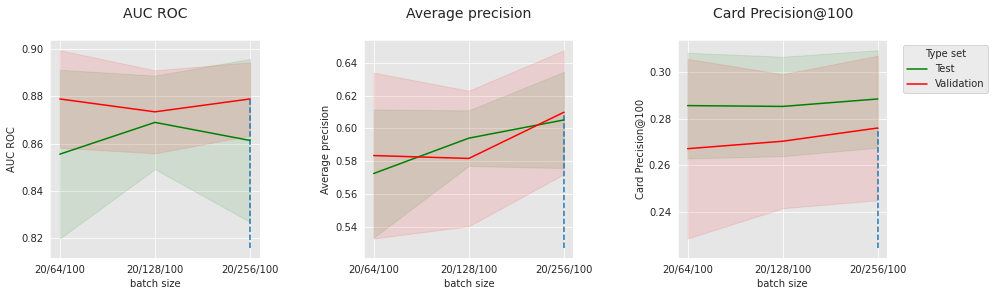

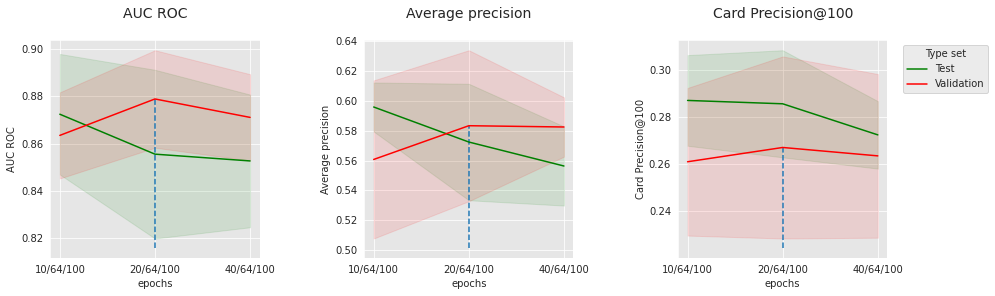

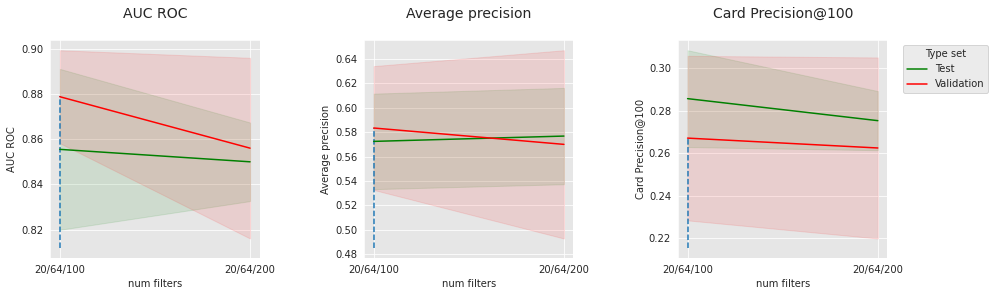

In [89]:
parameters_dict=dict(performances_df_cnn['Parameters'])
performances_df_cnn['Parameters summary']=[str(parameters_dict[i]['clf__max_epochs'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__batch_size'])+
                                   '/'+    
                                   str(parameters_dict[i]['clf__module__num_filters'])
                                   for i in range(len(parameters_dict))]

performances_df_cnn_subset = performances_df_cnn[performances_df_cnn['Parameters'].apply(lambda x:x['clf__lr']== 0.001 and x['clf__module__num_filters']==100 and x['clf__max_epochs']==20 and x['clf__module__num_conv']==2 and x['clf__module__p']==0.2).values]
summary_performances_cnn_subset=get_summary_performances(performances_df_cnn_subset, parameter_column_name="Parameters summary")
indexes_summary = summary_performances_cnn_subset.index.values
indexes_summary[0] = 'Best estimated parameters'
summary_performances_cnn_subset.rename(index = dict(zip(np.arange(len(indexes_summary)),indexes_summary)))
get_performances_plots(performances_df_cnn_subset, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="batch size",
                       summary_performances=summary_performances_cnn_subset)

performances_df_cnn_subset = performances_df_cnn[performances_df_cnn['Parameters'].apply(lambda x:x['clf__lr']== 0.001 and x['clf__module__num_filters']==100 and x['clf__batch_size']==64 and x['clf__module__num_conv']==2 and x['clf__module__p']==0.2).values]
summary_performances_cnn_subset=get_summary_performances(performances_df_cnn_subset, parameter_column_name="Parameters summary")
indexes_summary = summary_performances_cnn_subset.index.values
indexes_summary[0] = 'Best estimated parameters'
summary_performances_cnn_subset.rename(index = dict(zip(np.arange(len(indexes_summary)),indexes_summary)))
get_performances_plots(performances_df_cnn_subset, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="epochs",
                       summary_performances=summary_performances_cnn_subset)

performances_df_cnn_subset = performances_df_cnn[performances_df_cnn['Parameters'].apply(lambda x:x['clf__lr']== 0.001 and x['clf__max_epochs']==20 and x['clf__batch_size']==64 and x['clf__module__num_conv']==2 and x['clf__module__p']==0.2).values]
summary_performances_cnn_subset=get_summary_performances(performances_df_cnn_subset, parameter_column_name="Parameters summary")
indexes_summary = summary_performances_cnn_subset.index.values
indexes_summary[0] = 'Best estimated parameters'
summary_performances_cnn_subset.rename(index = dict(zip(np.arange(len(indexes_summary)),indexes_summary)))
get_performances_plots(performances_df_cnn_subset, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="num filters",
                       summary_performances=summary_performances_cnn_subset)


parameters_dict=dict(performances_df_cnn['Parameters'])
performances_df_cnn['Parameters summary']=[str(parameters_dict[i]['clf__max_epochs'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__module__num_conv'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__batch_size'])+
                                   '/'+    
                                   str(parameters_dict[i]['clf__module__num_filters'])+
                                   '/'+                                       
                                   str(parameters_dict[i]['clf__module__p'])
                                   for i in range(len(parameters_dict))]

Similar to the feed-forward network, the number of epochs and batch size, which are optimization parameters, have a sweet spot, which is probably connected to other parameters (model size, dropout, etc.). For the chosen optimization parameters, 100 filters seem to lead to better results than 200.

### Grid search on the Long Short Term Memory

For the LSTM, we will search the following hyperparameters:

* Batch size : [64,128,256]
* Initial learning rate: [0.0001, 0.0002, 0.001]
* Number of epochs : [5, 10, 20]
* Dropout rate : [0, 0.2, 0.4]
* Dimension of the LSTM hidden states : [100,200]

The LSTM takes sequences of transactions as input, so the process is the same as for the CNN, and the module also needs to be adapted to output two neurons. 

In [75]:
class FraudLSTM(torch.nn.Module):
    
    def __init__(self, num_features,hidden_size = 100, hidden_size_lstm = 100, num_layers_lstm = 1,p = 0):
        super(FraudLSTM, self).__init__()
        # parameters
        self.num_features = num_features
        self.hidden_size = hidden_size
        
        # representation learning part
        self.lstm = torch.nn.LSTM(self.num_features, hidden_size_lstm, num_layers_lstm, batch_first = True, dropout = p)
            
                    
        #representation to hidden
        self.fc1 = torch.nn.Linear(hidden_size_lstm, self.hidden_size)
        self.relu = torch.nn.ReLU()
        
        #hidden to output
        self.fc2 = torch.nn.Linear(self.hidden_size, 2)
        self.softmax = torch.nn.Softmax()
        
        self.dropout = torch.nn.Dropout(p)
        
    def forward(self, x):
        
        representation = self.lstm(x.transpose(1,2))

                    
        hidden = self.fc1(representation[1][0][0])
        relu = self.relu(hidden)
        relu = self.dropout(relu)
        
        output = self.fc2(relu)
        output = self.softmax(output)
        
        return output

In [76]:
seed_everything(42)
classifier = NeuralNetClassifier(
    FraudLSTM,
    max_epochs=2,
    lr=0.001,
    optimizer=torch.optim.Adam,
    batch_size=64,
    dataset=FraudSequenceDatasetForPipe,
    iterator_train__shuffle=True,
)
classifier.set_params(train_split=False, verbose=0)

parameters = {
    'clf__lr': [0.0001,0.0002,0.001],
    'clf__batch_size': [64,128,256],
    'clf__max_epochs': [5,10,20],
    'clf__module__hidden_size': [500],
    'clf__module__p': [0,0.2,0.4],
    'clf__module__num_features': [int(len(input_features))],
    'clf__module__hidden_size_lstm': [100,200],
}

start_time=time.time()

#these will get normalized but it should still work
input_features_new = input_features + ['CUSTOMER_ID','TX_DATETIME_TIMESTAMP']

performances_df=model_selection_wrapper(transactions_df, classifier, 
                                        input_features_new, output_feature,
                                        parameters, scoring, 
                                        start_date_training_for_valid,
                                        start_date_training_for_test,
                                        n_folds=n_folds,
                                        delta_train=delta_train, 
                                        delta_delay=delta_delay, 
                                        delta_assessment=delta_assessment,
                                        performance_metrics_list_grid=performance_metrics_list_grid,
                                        performance_metrics_list=performance_metrics_list,
                                        n_jobs=10)

execution_time_lstm = time.time()-start_time

parameters_dict=dict(performances_df['Parameters'])
performances_df['Parameters summary']=[str(parameters_dict[i]['clf__max_epochs'])+
                                   '/'+
                                    str(parameters_dict[i]['clf__batch_size'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__module__hidden_size_lstm'])+
                                   '/'+                           
                                   str(parameters_dict[i]['clf__module__p'])
                                   for i in range(len(parameters_dict))]

# Renombra a performances_df_lstm para comparación de rendimiento del modelo al final de este notebook
performances_df_lstm=performances_df


In [77]:
print(execution_time_lstm)

14750.79782986641


In [78]:
summary_performances_lstm=get_summary_performances(performances_df_lstm, parameter_column_name="Parameters summary")
summary_performances_lstm

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,5/256/100/0.2,20/128/100/0.4,5/64/200/0
Validation performance,0.881+/-0.01,0.681+/-0.01,0.286+/-0.02
Test performance,0.876+/-0.02,0.665+/-0.02,0.297+/-0.01
Optimal parameter(s),5/256/200/0.4,20/128/100/0.2,5/64/200/0.2
Optimal test performance,0.878+/-0.01,0.674+/-0.01,0.302+/-0.01


The results with the LSTM are more competitive than the CNN, and they are similar to the feed-forward network. This is still aligned with the hypothesis that the sequence does not really provide, for this dataset, a notable added value compared to only the last transaction with aggregated information. Nevertheless, the comparison with the CNN shows that, even with the same input, the choice of architecture can have an important impact on the performance. Moreover, the performed grid-search is for illustration purposes and is far from exhaustive, so the hyperparameters tuning brings an additional artifact to the results.

The conclusions about the set of optimal hyperparameters are very mixed here. Let us fix the learning rate to 0.0001, the batch size to 128, the dropout level to 0.2, and visualize the impact of the number of epochs and of the size of the hidden states.

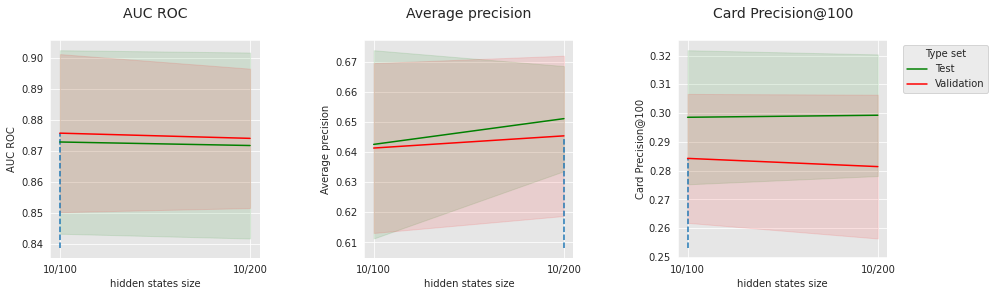

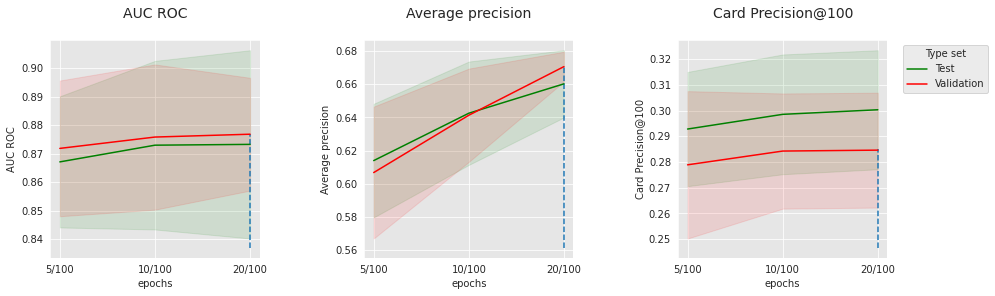

In [88]:
parameters_dict=dict(performances_df_lstm['Parameters'])
performances_df_lstm['Parameters summary']=[str(parameters_dict[i]['clf__max_epochs'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__module__hidden_size_lstm'])
                                   for i in range(len(parameters_dict))]

performances_df_lstm_subset = performances_df_lstm[performances_df_lstm['Parameters'].apply(lambda x:x['clf__lr']== 0.0001 and x['clf__batch_size']==128 and x['clf__max_epochs']==10 and x['clf__module__p']==0.2).values]
summary_performances_lstm_subset=get_summary_performances(performances_df_lstm_subset, parameter_column_name="Parameters summary")
indexes_summary = summary_performances_lstm_subset.index.values
indexes_summary[0] = 'Best estimated parameters'
summary_performances_lstm_subset.rename(index = dict(zip(np.arange(len(indexes_summary)),indexes_summary)))
get_performances_plots(performances_df_lstm_subset, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="hidden states size",
                       summary_performances=summary_performances_lstm_subset)

performances_df_lstm_subset = performances_df_lstm[performances_df_lstm['Parameters'].apply(lambda x:x['clf__lr']== 0.0001 and x['clf__batch_size']==128 and x['clf__module__hidden_size_lstm']==100 and x['clf__module__p']==0.2).values]
summary_performances_lstm_subset=get_summary_performances(performances_df_lstm_subset, parameter_column_name="Parameters summary")
indexes_summary = summary_performances_lstm_subset.index.values
indexes_summary[0] = 'Best estimated parameters'
summary_performances_lstm_subset.rename(index = dict(zip(np.arange(len(indexes_summary)),indexes_summary)))
get_performances_plots(performances_df_lstm_subset, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="epochs",
                       summary_performances=summary_performances_lstm_subset)

parameters_dict=dict(performances_df_lstm['Parameters'])
performances_df_lstm['Parameters summary']=[str(parameters_dict[i]['clf__max_epochs'])+
                                   '/'+
                                    str(parameters_dict[i]['clf__batch_size'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__module__hidden_size_lstm'])+
                                   '/'+                           
                                   str(parameters_dict[i]['clf__module__p'])
                                   for i in range(len(parameters_dict))]

Recall here that the grid search is not exhaustive, and from the plots, it appears that the average precision could have been further improved.

### Grid search on the LSTM with Attention

For the LSTM with Attention, we apply the exact same process as for the LSTM.

In [79]:
class FraudLSTMWithAttention(torch.nn.Module):
    
    def __init__(self, num_features,hidden_size = 100, hidden_size_lstm = 100, num_layers_lstm = 1,p = 0):
        super(FraudLSTMWithAttention, self).__init__()
        # parameters
        self.num_features = num_features
        self.hidden_size = hidden_size
        
        # representation learning part
        self.lstm = torch.nn.LSTM(self.num_features, hidden_size_lstm, num_layers_lstm, batch_first = True, dropout = p)
            
        # last sequence represenation
        self.ff = torch.nn.Linear(self.num_features,hidden_size_lstm)
        
        attention_out_dim = hidden_size_lstm
        
        # attention layer
        self.attention = Attention(attention_out_dim)                        
       
        #representation to hidden
        self.fc1 = torch.nn.Linear(hidden_size_lstm, self.hidden_size)
        self.relu = torch.nn.ReLU()
        
        #hidden to output
        self.fc2 = torch.nn.Linear(self.hidden_size, 2)
        self.softmax = torch.nn.Softmax()
        
        self.dropout = torch.nn.Dropout(p)
        
    def forward(self, x):
        
        representation_seq, _ = self.lstm(x.transpose(1,2))
        
        representation_last = self.ff(x[:,:,-1:].transpose(1,2))
        
        representation, attn = self.attention(representation_last,representation_seq)

                    
        hidden = self.fc1(representation[:,0,:])
        relu = self.relu(hidden)
        relu = self.dropout(relu)
        
        output = self.fc2(relu)
        output = self.softmax(output)
        
        return output

In [80]:
seed_everything(42)
classifier = NeuralNetClassifier(
    FraudLSTMWithAttention,
    max_epochs=2,
    lr=0.001,
    optimizer=torch.optim.Adam,
    batch_size=64,
    dataset=FraudSequenceDatasetForPipe,
    iterator_train__shuffle=True,
)
classifier.set_params(train_split=False, verbose=0)

parameters = {
    'clf__lr': [0.0001,0.0002,0.001],
    'clf__batch_size': [64,128,256],
    'clf__max_epochs': [5,10,20],
    'clf__module__hidden_size': [500],
    'clf__module__p': [0,0.2,0.4],
    'clf__module__num_features': [int(len(input_features))],
    'clf__module__hidden_size_lstm': [100,200],
}

start_time=time.time()

#these will get normalized but it should still work
input_features_new = input_features + ['CUSTOMER_ID','TX_DATETIME_TIMESTAMP']

performances_df=model_selection_wrapper(transactions_df, classifier, 
                                        input_features_new, output_feature,
                                        parameters, scoring, 
                                        start_date_training_for_valid,
                                        start_date_training_for_test,
                                        n_folds=n_folds,
                                        delta_train=delta_train, 
                                        delta_delay=delta_delay, 
                                        delta_assessment=delta_assessment,
                                        performance_metrics_list_grid=performance_metrics_list_grid,
                                        performance_metrics_list=performance_metrics_list,
                                        n_jobs=10)

execution_time_lstm_attn = time.time()-start_time

parameters_dict=dict(performances_df['Parameters'])
performances_df['Parameters summary']=[str(parameters_dict[i]['clf__max_epochs'])+
                                   '/'+
                                    str(parameters_dict[i]['clf__batch_size'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__module__hidden_size_lstm'])+
                                   '/'+                           
                                   str(parameters_dict[i]['clf__module__p'])
                                   for i in range(len(parameters_dict))]

# Renombra a performances_df_lstm para comparación de rendimiento del modelo al final de este notebook
performances_df_lstm_attn=performances_df


In [81]:
print(execution_time_lstm_attn)

16735.779472112656


In [82]:
summary_performances_lstm_attn=get_summary_performances(performances_df_lstm_attn, parameter_column_name="Parameters summary")
summary_performances_lstm_attn

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,10/64/100/0.2,10/64/200/0.2,20/256/200/0.2
Validation performance,0.886+/-0.02,0.69+/-0.01,0.287+/-0.02
Test performance,0.874+/-0.02,0.667+/-0.01,0.295+/-0.01
Optimal parameter(s),5/256/200/0.4,10/64/200/0,10/64/200/0
Optimal test performance,0.879+/-0.02,0.676+/-0.02,0.303+/-0.01


The LSTM with Attention has a performance that is only slightly better than the regular LSTM. Although Attention is a mechanism that significantly impacts many applications such as NLP, its interest can be limited on such sequences that are rather short and on such a model that only has a single recurrent layer.

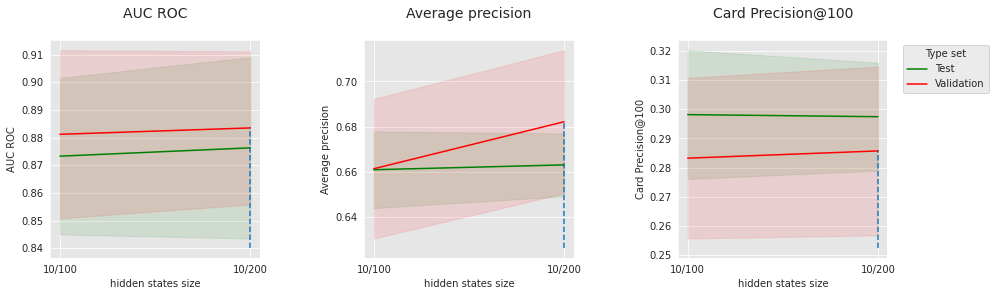

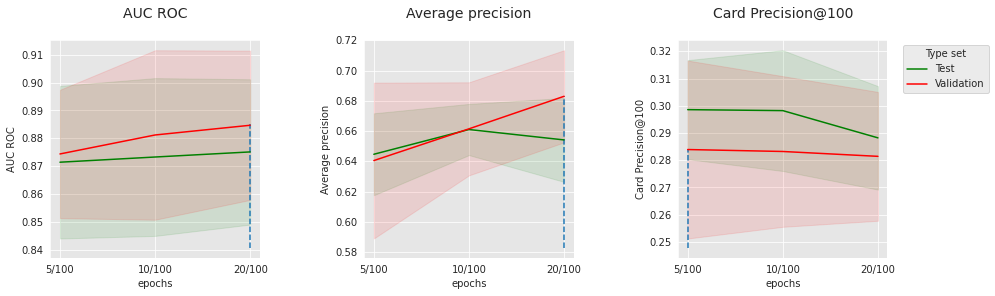

In [90]:
parameters_dict=dict(performances_df_lstm_attn['Parameters'])
performances_df_lstm_attn['Parameters summary']=[str(parameters_dict[i]['clf__max_epochs'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__module__hidden_size_lstm'])
                                   for i in range(len(parameters_dict))]

performances_df_lstm_attn_subset = performances_df_lstm_attn[performances_df_lstm_attn['Parameters'].apply(lambda x:x['clf__lr']== 0.0001 and x['clf__batch_size']==128 and x['clf__max_epochs']==10 and x['clf__module__p']==0.2).values]
summary_performances_lstm_attn_subset=get_summary_performances(performances_df_lstm_attn_subset, parameter_column_name="Parameters summary")
indexes_summary = summary_performances_lstm_attn_subset.index.values
indexes_summary[0] = 'Best estimated parameters'
summary_performances_lstm_attn_subset.rename(index = dict(zip(np.arange(len(indexes_summary)),indexes_summary)))
get_performances_plots(performances_df_lstm_attn_subset, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="hidden states size",
                       summary_performances=summary_performances_lstm_attn_subset)

performances_df_lstm_attn_subset = performances_df_lstm_attn[performances_df_lstm_attn['Parameters'].apply(lambda x:x['clf__lr']== 0.0001 and x['clf__batch_size']==128 and x['clf__module__hidden_size_lstm']==100 and x['clf__module__p']==0.2).values]
summary_performances_lstm_attn_subset=get_summary_performances(performances_df_lstm_attn_subset, parameter_column_name="Parameters summary")
indexes_summary = summary_performances_lstm_attn_subset.index.values
indexes_summary[0] = 'Best estimated parameters'
summary_performances_lstm_attn_subset.rename(index = dict(zip(np.arange(len(indexes_summary)),indexes_summary)))
get_performances_plots(performances_df_lstm_attn_subset, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="epochs",
                       summary_performances=summary_performances_lstm_attn_subset)

parameters_dict=dict(performances_df_lstm_attn['Parameters'])
performances_df_lstm_attn['Parameters summary']=[str(parameters_dict[i]['clf__max_epochs'])+
                                   '/'+
                                    str(parameters_dict[i]['clf__batch_size'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__module__hidden_size_lstm'])+
                                   '/'+                           
                                   str(parameters_dict[i]['clf__module__p'])
                                   for i in range(len(parameters_dict))]

For the same set of hyperparameters, the convergence w.r.t the average precision is different than LSTM without Attention.


## Saving of results

Let us save the performance results and execution times of these three models in a Python pickle format.

In [83]:
performances_df_dictionary={
    "CNN": performances_df_cnn,    
    "LSTM": performances_df_lstm,    
    "LSTM_Attention": performances_df_lstm_attn,
}

execution_times=[execution_time_cnn,execution_time_lstm,execution_time_lstm_attn]

filehandler = open('performances_model_selection_seq_model.pkl', 'wb') 
pickle.dump((performances_df_dictionary, execution_times), filehandler)
filehandler.close()

## Benchmark summary

Let us finally retrieve the performance results obtained in

* [Chapter 5](Model_Selection_Comparison_Performances) with decision tree, logistic regression, random forest and XGBoost, and
* [Chapter 7, Section 2](Model_Selection_FFNN) with feed-forward neural networks

and compare them with those obtained with CNN, LSTM, and LSTM with Attention. 

The results can be retrieved by loading the `performances_model_selection.pkl`, `performances_model_selection_nn.pkl` and `performances_model_selection_seq_model.pkl` pickle files, and summarized with the `get_summary_performances` function.

In [2]:
# Carga los resultados de rendimiento para árbol de decisión, regresión logística, bosque aleatorio y XGBoost
filehandler = open('../Chapter_5_ModelValidationAndSelection/performances_model_selection.pkl', 'rb') 
(performances_df_dictionary, execution_times) = pickle.load(filehandler)

# Carga los resultados de rendimiento para red neuronal feed-forward
filehandler = open('performances_model_selection_nn.pkl', 'rb') 
(performances_df_dictionary_nn, execution_times_nn) = pickle.load(filehandler)

# Carga los resultados de rendimiento para CNN, LSTM y LSTM con Atención
filehandler = open('performances_model_selection_seq_model.pkl', 'rb') 
(performances_df_dictionary_seq_model, execution_times_seq_model) = pickle.load(filehandler)


In [9]:
performances_df_dt=performances_df_dictionary['Decision Tree']
summary_performances_dt=get_summary_performances(performances_df_dt, parameter_column_name="Parameters summary")

performances_df_lr=performances_df_dictionary['Logistic Regression']
summary_performances_lr=get_summary_performances(performances_df_lr, parameter_column_name="Parameters summary")

performances_df_rf=performances_df_dictionary['Random Forest']
summary_performances_rf=get_summary_performances(performances_df_rf, parameter_column_name="Parameters summary")

performances_df_xgboost=performances_df_dictionary['XGBoost']
summary_performances_xgboost=get_summary_performances(performances_df_xgboost, parameter_column_name="Parameters summary")

performances_df_nn=performances_df_dictionary_nn['Neural Network']
summary_performances_nn=get_summary_performances(performances_df_nn, parameter_column_name="Parameters summary")

performances_df_cnn=performances_df_dictionary_seq_model['CNN']
summary_performances_cnn=get_summary_performances(performances_df_cnn, parameter_column_name="Parameters summary")

performances_df_lstm=performances_df_dictionary_seq_model['LSTM']
summary_performances_lstm=get_summary_performances(performances_df_lstm, parameter_column_name="Parameters summary")

performances_df_lstm_attention=performances_df_dictionary_seq_model['LSTM_Attention']
summary_performances_lstm_attention=get_summary_performances(performances_df_lstm_attention, parameter_column_name="Parameters summary")

summary_test_performances = pd.concat([summary_performances_dt.iloc[2,:],
                                       summary_performances_lr.iloc[2,:],
                                       summary_performances_rf.iloc[2,:],
                                       summary_performances_xgboost.iloc[2,:],
                                       summary_performances_nn.iloc[2,:],
                                       summary_performances_cnn.iloc[2,:],
                                       summary_performances_lstm.iloc[2,:],
                                       summary_performances_lstm_attention.iloc[2,:],
                                      ],axis=1)
summary_test_performances.columns=['Decision Tree', 'Logistic Regression', 'Random Forest', 'XGBoost', 
                                   'Neural Network', 'CNN', 'LSTM', 'LSTM with Attention']


The results are summarized in a `summary_test_performances` table. Rows provide the average performance results on the test sets in terms of AUC ROC, Average Precision and CP@100. 

In [10]:
summary_test_performances

,Decision Tree,Logistic Regression,Random Forest,XGBoost,Neural Network,CNN,LSTM,LSTM with Attention
AUC ROC,0.797+/-0.01,0.868+/-0.02,0.87+/-0.02,0.869+/-0.01,0.876+/-0.01,0.872+/-0.01,0.876+/-0.02,0.874+/-0.02
Average precision,0.579+/-0.01,0.623+/-0.02,0.678+/-0.01,0.687+/-0.01,0.675+/-0.01,0.599+/-0.01,0.665+/-0.02,0.667+/-0.01
Card Precision@100,0.284+/-0.0,0.297+/-0.01,0.299+/-0.01,0.303+/-0.01,0.303+/-0.02,0.288+/-0.01,0.297+/-0.01,0.295+/-0.01


In the end, it appears that neural-network based approaches provide results that are competitive with random forests and XGBoost, providing slightly better performances in terms of AUC ROC, and slightly worse performances in terms of Average Precision. However, it should be kept in mind that, given more computational resources, a more extensive hyperparameter tuning could be performed for neural network-based approaches that would likely lead to further improve their performances. 


## Conclusion

In this section, automatic methods to build features from contextual data were explored. To classify a transaction as fraudulent or genuine, it is generally useful to resort to the regular behavior of the cardholder in order to detect a discrepancy. A manual method to integrate this contextual information is to proceed with feature engineering and the creation of expert feature aggregations. 

Automatic representation learning methods from the Deep Learning literature have been explored to create features that represent the cardholder's sequence of previous transactions in a way that optimizes the classification of the current transaction. 

The key methodological components are the building of the data pipeline to automatically create the sequential data from landmark variables and the right combination of adapted neural networks such as the 1D-CNN, the LSTM, the Attention mechanism, etc. These models have been tested here, and they can provide competitive performance. In the future, other candidate architectures such as Multi-Head Self-Attention, Sequence-to-Sequence Autoencoder, or any combination of the above modules could be explored to attempt to further improve fraud detection performance. 


---

## RealWorldData


# Real-world data


The section reports the performances that are obtained on real-world data using neural network architectures. The dataset is the same as in [Chapter 3, Section 5](Baseline_FDS_RealWorldData). Results are reported following the prequential grid search methodology used in the previous sections with simulated data. 

We first report the performances for the feed-forward neural network, the convolutional neural network, the long short term memory, and the LSTM with attention. We also considered variations in the hyperparameters:
* `Feed-forward Neural Network`: 2 layers, 500 neurons, a dropout level of 0 or 0.2, Adam with a learning rate of 0.001 or 0.0001, 5, 10 or 20 epochs, and a batch size of 64, 128, or 256. 
* `Convolutional Neural Network`: 2 convolutional layers with 200 filters of size 2, 1 hidden layer with 500 neurons, a dropout level of 0 or 0.2, Adam with a learning rate of 0.001 or 0.0001, 5, 10 or 20 epochs, and a batch size of 64, 128 or 256.
* `Long Short Term Memory`: 1 recurrent layer with 200 neurons for the hidden state, 1 hidden layer with 500 neurons, a dropout level of 0 or 0.2, Adam with a learning rate of 0.001 or 0.0001, 5, 10 or 20 epochs, and a batch size of 64, 128 or 256.
* `Long Short Term Memory with Attention`: 1 recurrent layer with 200 neurons for the hidden state, 1 hidden layer with 500 neurons, a dropout level of 0 or 0.2, Adam with a learning rate of 0.001 or 0.0001, 5, 10 or 20 epochs, and a batch size of 64, 128 or 256.


We finally report global results and compare them to the other supervised baselines (decision tree, logistic regression, random forest, and XGBoost).

In [1]:
# Inicialización: Cargar funciones compartidas

# Carga las funciones compartidas
!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.py
%run shared_functions.py
#%run ../Chapter_References/shared_functions.ipynb


## Red neuronal de propagación hacia adelante

In [2]:
filehandler = open('performances_model_selection_nn_real_data.pkl', 'rb') 
(performances_df_dictionary, execution_times) = pickle.load(filehandler)

Los resultados para la red de propagación hacia adelante se reportan a continuación. Primero echemos un vistazo a las tendencias globales con el resumen de rendimiento.

In [3]:
performances_df_nn = performances_df_dictionary['Neural Network']

In [4]:
summary_performances_nn=get_summary_performances(performances_df_nn, parameter_column_name="Parameters summary")
summary_performances_nn

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,0.0001/128/20/0.2/2,0.0001/128/20/0.2/2,0.0001/256/10/0/2
Validation performance,0.874+/-0.02,0.079+/-0.03,0.218+/-0.04
Test performance,0.894+/-0.01,0.084+/-0.02,0.236+/-0.04
Optimal parameter(s),0.001/256/20/0.2/2,0.0001/64/20/0.2/2,0.0001/256/10/0/2
Optimal test performance,0.898+/-0.01,0.085+/-0.01,0.236+/-0.04


Al igual que para los datos sintéticos, el conjunto óptimo de hiperparámetros depende fuertemente de la métrica. La tasa de aprendizaje más pequeña `0.0001`, y el mayor número de épocas `20` son ligeramente favorecidos. Consideremos estos valores y visualicemos el impacto del tamaño de lote y el nivel de dropout.

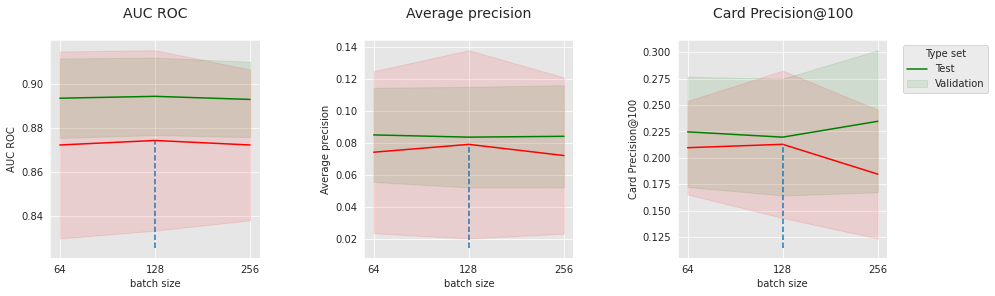

In [5]:
parameters_dict=dict(performances_df_nn['Parameters'])
performances_df_nn['Parameters summary']=[
                                   str(parameters_dict[i]['clf__batch_size'])    
                                   for i in range(len(parameters_dict))]
performances_df_nn_subset = performances_df_nn[performances_df_nn['Parameters'].apply(lambda x:x['clf__lr']== 0.0001 and x['clf__module__hidden_size']==500 and x['clf__module__num_layers']==2 and x['clf__module__p']==0.2 and x['clf__max_epochs']==20).values]
summary_performances_nn_subset=get_summary_performances(performances_df_nn_subset, parameter_column_name="Parameters summary")
indexes_summary = summary_performances_nn_subset.index.values
indexes_summary[0] = 'Best estimated parameters'
summary_performances_nn_subset.rename(index = dict(zip(np.arange(len(indexes_summary)),indexes_summary)))
get_performances_plots(performances_df_nn_subset, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="batch size",
                       summary_performances=summary_performances_nn_subset)

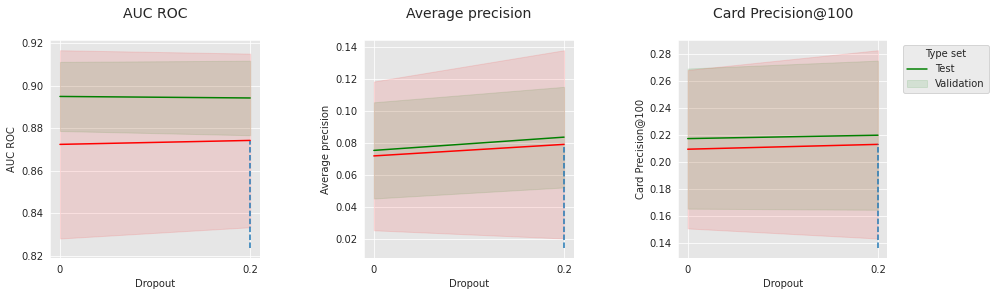

In [6]:
parameters_dict=dict(performances_df_nn['Parameters'])
performances_df_nn['Parameters summary']=[
                                   str(parameters_dict[i]['clf__module__p'])    
                                   for i in range(len(parameters_dict))]
performances_df_nn_subset = performances_df_nn[performances_df_nn['Parameters'].apply(lambda x:x['clf__lr']== 0.0001 and x['clf__module__hidden_size']==500 and x['clf__module__num_layers']==2 and x['clf__max_epochs']==20 and x['clf__batch_size']==128).values]
summary_performances_nn_subset=get_summary_performances(performances_df_nn_subset, parameter_column_name="Parameters summary")
indexes_summary = summary_performances_nn_subset.index.values
indexes_summary[0] = 'Best estimated parameters'
summary_performances_nn_subset.rename(index = dict(zip(np.arange(len(indexes_summary)),indexes_summary)))
get_performances_plots(performances_df_nn_subset, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Dropout",
                       summary_performances=summary_performances_nn_subset)

Similar a los resultados en datos sintéticos, estos hiperparámetros relacionados con la optimización todos tienen puntos óptimos que dependen unos de otros. Esto confirma la importancia del ajuste para este tipo de modelo.

En general, nuestra red neuronal de propagación hacia adelante simple alcanza un rendimiento competitivo. Es comparable al baseline Random Forest en los datos del mundo real (comparación global al final), lo cual es muy prometedor para aplicaciones a sistemas de detección de fraude incrementales.

## Modelos secuenciales

Analicemos ahora el rendimiento de los modelos secuenciales en datos del mundo real con respecto a algunos de sus parámetros de optimización. 

In [7]:
filehandler = open('performances_model_selection_seq_model_real_data.pkl', 'rb') 
(performances_df_dictionary_seq_model, execution_times) = pickle.load(filehandler)

In [8]:
performances_df_cnn=performances_df_dictionary_seq_model['CNN']
summary_performances_cnn=get_summary_performances(performances_df_cnn, parameter_column_name="Parameters summary")

performances_df_lstm=performances_df_dictionary_seq_model['LSTM']
summary_performances_lstm=get_summary_performances(performances_df_lstm, parameter_column_name="Parameters summary")

performances_df_lstm_attn=performances_df_dictionary_seq_model['LSTM_Attention']
summary_performances_lstm_attn=get_summary_performances(performances_df_lstm_attn, parameter_column_name="Parameters summary")

### Red Neuronal Convolucional

Comenzamos con la red neuronal convolucional 1D. Se analizan el resumen de rendimiento y el impacto del tamaño de lote, número de épocas y dropout.

In [9]:
summary_performances_cnn

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,5/2/256/200/0,10/2/256/200/0,10/2/128/200/0
Validation performance,0.864+/-0.02,0.098+/-0.03,0.227+/-0.03
Test performance,0.882+/-0.01,0.093+/-0.02,0.221+/-0.03
Optimal parameter(s),5/2/128/200/0,5/2/256/200/0,5/2/64/200/0.2
Optimal test performance,0.884+/-0.01,0.103+/-0.02,0.245+/-0.02


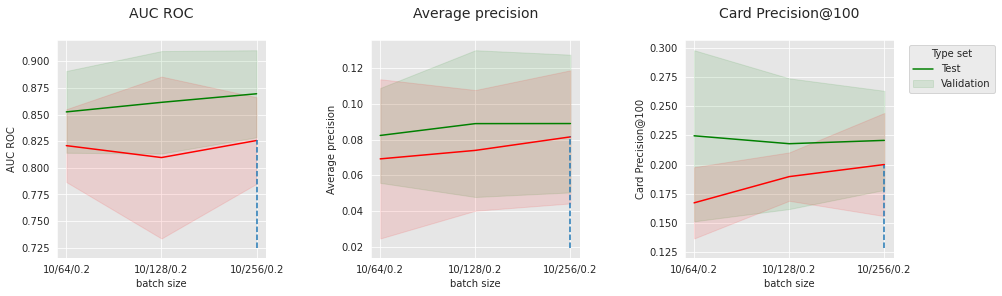

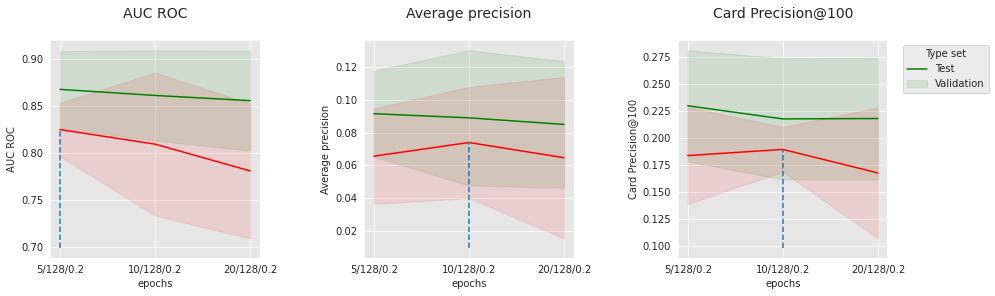

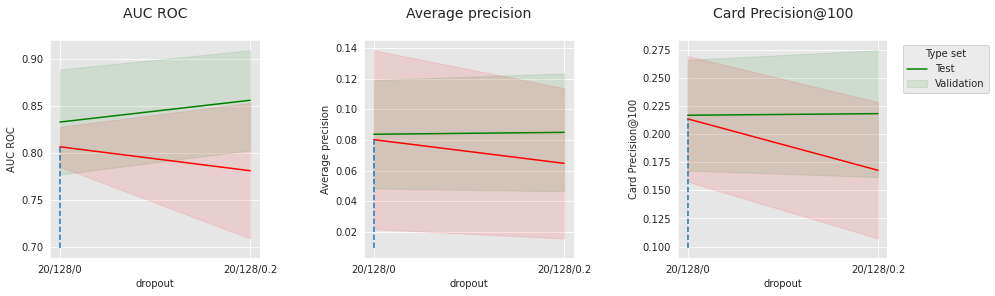

In [10]:
parameters_dict=dict(performances_df_cnn['Parameters'])
performances_df_cnn['Parameters summary']=[str(parameters_dict[i]['clf__max_epochs'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__batch_size'])+
                                   '/'+    
                                   str(parameters_dict[i]['clf__module__p'])
                                   for i in range(len(parameters_dict))]

performances_df_cnn_subset = performances_df_cnn[performances_df_cnn['Parameters'].apply(lambda x:x['clf__lr']== 0.0001 and x['clf__module__num_filters']==200 and x['clf__max_epochs']==10 and x['clf__module__num_conv']==2 and x['clf__module__p']==0.2).values]
summary_performances_cnn_subset=get_summary_performances(performances_df_cnn_subset, parameter_column_name="Parameters summary")
indexes_summary = summary_performances_cnn_subset.index.values
indexes_summary[0] = 'Best estimated parameters'
summary_performances_cnn_subset.rename(index = dict(zip(np.arange(len(indexes_summary)),indexes_summary)))
get_performances_plots(performances_df_cnn_subset, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="batch size",
                       summary_performances=summary_performances_cnn_subset)

performances_df_cnn_subset = performances_df_cnn[performances_df_cnn['Parameters'].apply(lambda x:x['clf__lr']== 0.0001 and x['clf__module__num_filters']==200 and x['clf__batch_size']==128 and x['clf__module__num_conv']==2 and x['clf__module__p']==0.2).values]
summary_performances_cnn_subset=get_summary_performances(performances_df_cnn_subset, parameter_column_name="Parameters summary")
indexes_summary = summary_performances_cnn_subset.index.values
indexes_summary[0] = 'Best estimated parameters'
summary_performances_cnn_subset.rename(index = dict(zip(np.arange(len(indexes_summary)),indexes_summary)))
get_performances_plots(performances_df_cnn_subset, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="epochs",
                       summary_performances=summary_performances_cnn_subset)

performances_df_cnn_subset = performances_df_cnn[performances_df_cnn['Parameters'].apply(lambda x:x['clf__lr']== 0.0001 and x['clf__module__num_filters']==200 and x['clf__batch_size']==128 and x['clf__module__num_conv']==2 and x['clf__max_epochs']==20).values]
summary_performances_cnn_subset=get_summary_performances(performances_df_cnn_subset, parameter_column_name="Parameters summary")
indexes_summary = summary_performances_cnn_subset.index.values
indexes_summary[0] = 'Best estimated parameters'
summary_performances_cnn_subset.rename(index = dict(zip(np.arange(len(indexes_summary)),indexes_summary)))
get_performances_plots(performances_df_cnn_subset, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="dropout",
                       summary_performances=summary_performances_cnn_subset)

Similar a la red neuronal regular, el rendimiento depende altamente de los parámetros de optimización. Un pequeño nivel de dropout parece ser beneficioso, en particular en el conjunto de datos de prueba, donde la distribución está más alejada de la distribución de entrenamiento.


En general, excepto para el AUC ROC, la red neuronal convolucional 1D es capaz de superar a la red neuronal de propagación hacia adelante y obtener una Precisión Promedio muy competitiva.

### Memoria a Corto y Largo Plazo

Continuemos con el LSTM. 

In [11]:
summary_performances_lstm

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,5/128/200/0.2,5/256/200/0.2,5/64/200/0
Validation performance,0.873+/-0.02,0.109+/-0.04,0.238+/-0.02
Test performance,0.892+/-0.0,0.104+/-0.03,0.22+/-0.03
Optimal parameter(s),5/256/200/0.2,5/128/200/0,5/256/200/0
Optimal test performance,0.893+/-0.01,0.11+/-0.02,0.24+/-0.03


La memoria a corto y largo plazo supera globalmente a la red neuronal convolucional en los conjuntos de datos de prueba y obtiene la mejor precisión promedio en general.

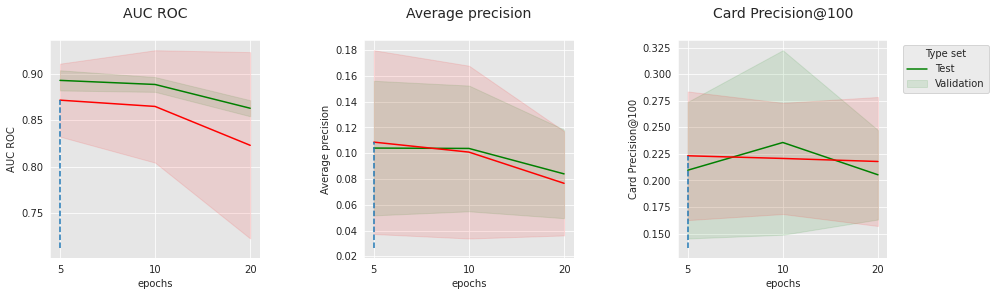

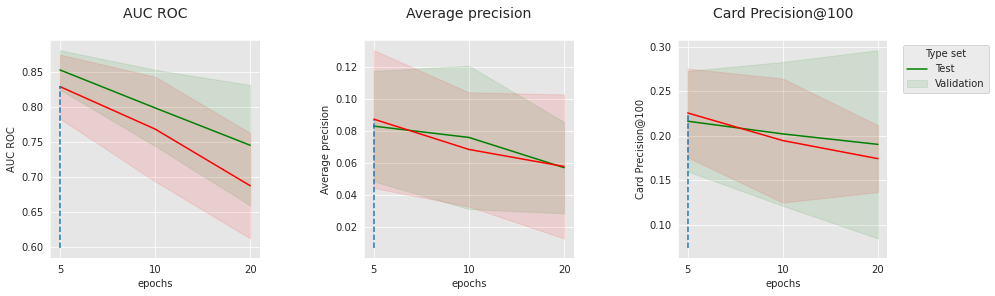

In [12]:
parameters_dict=dict(performances_df_lstm['Parameters'])
performances_df_lstm['Parameters summary']=[str(parameters_dict[i]['clf__max_epochs'])
                                            for i in range(len(parameters_dict))]

performances_df_lstm_subset = performances_df_lstm[performances_df_lstm['Parameters'].apply(lambda x:x['clf__lr']== 0.0001 and x['clf__batch_size']==256 and x['clf__module__hidden_size_lstm']==200 and x['clf__module__p']==0.2).values]
summary_performances_lstm_subset=get_summary_performances(performances_df_lstm_subset, parameter_column_name="Parameters summary")
indexes_summary = summary_performances_lstm_subset.index.values
indexes_summary[0] = 'Best estimated parameters'
summary_performances_lstm_subset.rename(index = dict(zip(np.arange(len(indexes_summary)),indexes_summary)))
get_performances_plots(performances_df_lstm_subset, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="epochs",
                       summary_performances=summary_performances_lstm_subset)

performances_df_lstm_subset = performances_df_lstm[performances_df_lstm['Parameters'].apply(lambda x:x['clf__lr']== 0.001 and x['clf__batch_size']==64 and x['clf__module__hidden_size_lstm']==200 and x['clf__module__p']==0.2).values]
summary_performances_lstm_subset=get_summary_performances(performances_df_lstm_subset, parameter_column_name="Parameters summary")
indexes_summary = summary_performances_lstm_subset.index.values
indexes_summary[0] = 'Best estimated parameters'
summary_performances_lstm_subset.rename(index = dict(zip(np.arange(len(indexes_summary)),indexes_summary)))
get_performances_plots(performances_df_lstm_subset, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="epochs",
                       summary_performances=summary_performances_lstm_subset)

Los gráficos anteriores muestran la evolución de las tres métricas con el número de épocas, para los dos conjuntos extremos de hiperparámetros relacionados con "convergencia". En los gráficos superiores, la tasa de aprendizaje es `0.0001`, y el tamaño de lote es `256`. En los gráficos inferiores, la tasa de aprendizaje es `0.001`, y el tamaño de lote es `64`. El mejor rendimiento se obtiene para la tasa de aprendizaje más baja, el tamaño de lote más grande, y el menor número de épocas, lo que sugiere que reducir la velocidad de convergencia o el número de épocas podría potencialmente impulsar el rendimiento más allá. A pesar de esto, el rendimiento óptimo en los conjuntos de prueba ya es muy competitivo con el baseline (ver los resultados al final de esta sección).

### LSTM con Atención

Para el LSTM con Atención, finalmente realizamos el mismo análisis exacto que para el LSTM regular. Los resultados, mostrados a continuación, son ligeramente mejores y también podrían mejorarse realizando menos pasos de optimización o ralentizando la convergencia. 

In [13]:
summary_performances_lstm_attn

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,5/128/200/0.2,5/128/200/0.2,10/128/200/0
Validation performance,0.89+/-0.01,0.105+/-0.03,0.243+/-0.03
Test performance,0.898+/-0.01,0.105+/-0.02,0.232+/-0.03
Optimal parameter(s),5/256/200/0,5/256/200/0.2,5/128/200/0
Optimal test performance,0.899+/-0.01,0.113+/-0.03,0.247+/-0.02


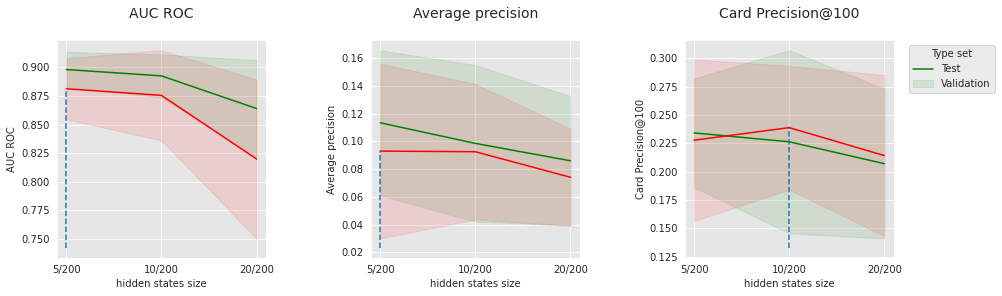

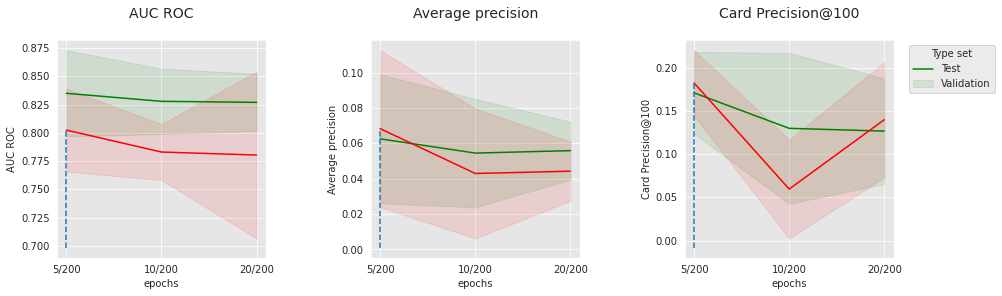

In [14]:
parameters_dict=dict(performances_df_lstm_attn['Parameters'])
performances_df_lstm_attn['Parameters summary']=[str(parameters_dict[i]['clf__max_epochs'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__module__hidden_size_lstm'])
                                   for i in range(len(parameters_dict))]

performances_df_lstm_attn_subset = performances_df_lstm_attn[performances_df_lstm_attn['Parameters'].apply(lambda x:x['clf__lr']== 0.0001 and x['clf__batch_size']==256 and x['clf__module__hidden_size_lstm']==200 and x['clf__module__p']==0.2).values]
summary_performances_lstm_attn_subset=get_summary_performances(performances_df_lstm_attn_subset, parameter_column_name="Parameters summary")
indexes_summary = summary_performances_lstm_attn_subset.index.values
indexes_summary[0] = 'Best estimated parameters'
summary_performances_lstm_attn_subset.rename(index = dict(zip(np.arange(len(indexes_summary)),indexes_summary)))
get_performances_plots(performances_df_lstm_attn_subset, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="hidden states size",
                       summary_performances=summary_performances_lstm_attn_subset)

performances_df_lstm_attn_subset = performances_df_lstm_attn[performances_df_lstm_attn['Parameters'].apply(lambda x:x['clf__lr']== 0.001 and x['clf__batch_size']==64 and x['clf__module__hidden_size_lstm']==200 and x['clf__module__p']==0.2).values]
summary_performances_lstm_attn_subset=get_summary_performances(performances_df_lstm_attn_subset, parameter_column_name="Parameters summary")
indexes_summary = summary_performances_lstm_attn_subset.index.values
indexes_summary[0] = 'Best estimated parameters'
summary_performances_lstm_attn_subset.rename(index = dict(zip(np.arange(len(indexes_summary)),indexes_summary)))
get_performances_plots(performances_df_lstm_attn_subset, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="epochs",
                       summary_performances=summary_performances_lstm_attn_subset)

## Comparación global

Para contrastar los resultados obtenidos en el conjunto de datos simulado en las secciones anteriores, hagamos también aquí una comparación completa de los enfoques (baselines y modelos de deep learning) en los datos del mundo real. En particular, complementemos los resultados anteriores con los obtenidos con modelos baseline (la Regresión Lineal, el Árbol de Decisión, el Random Forest, y XGBoost) y mostremos todo en una tabla global.

In [15]:
# Carga los resultados de rendimiento para árbol de decisión, regresión logística, bosque aleatorio y XGBoost
filehandler = open('../Chapter_5_ModelValidationAndSelection/images/performances_model_selection_real_world_data.pkl', 'rb') 
(performances_df_dictionary, execution_times) = pickle.load(filehandler)

# Carga los resultados de rendimiento para red neuronal feed-forward
filehandler = open('performances_model_selection_nn_real_data.pkl', 'rb') 
(performances_df_dictionary_nn, execution_times_nn) = pickle.load(filehandler)

# Carga los resultados de rendimiento para CNN, LSTM y LSTM con Atención
filehandler = open('performances_model_selection_seq_model_real_data.pkl', 'rb') 
(performances_df_dictionary_seq_model, execution_times_seq_model) = pickle.load(filehandler)


In [16]:
performances_df_dt=performances_df_dictionary['Decision Tree']
summary_performances_dt=get_summary_performances(performances_df_dt, parameter_column_name="Parameters summary")

performances_df_lr=performances_df_dictionary['Logistic Regression']
summary_performances_lr=get_summary_performances(performances_df_lr, parameter_column_name="Parameters summary")

performances_df_rf=performances_df_dictionary['Random Forest']
summary_performances_rf=get_summary_performances(performances_df_rf, parameter_column_name="Parameters summary")

performances_df_xgboost=performances_df_dictionary['XGBoost']
summary_performances_xgboost=get_summary_performances(performances_df_xgboost, parameter_column_name="Parameters summary")

performances_df_nn=performances_df_dictionary_nn['Neural Network']
summary_performances_nn=get_summary_performances(performances_df_nn, parameter_column_name="Parameters summary")

performances_df_cnn=performances_df_dictionary_seq_model['CNN']
summary_performances_cnn=get_summary_performances(performances_df_cnn, parameter_column_name="Parameters summary")

performances_df_lstm=performances_df_dictionary_seq_model['LSTM']
summary_performances_lstm=get_summary_performances(performances_df_lstm, parameter_column_name="Parameters summary")

performances_df_lstm_attention=performances_df_dictionary_seq_model['LSTM_Attention']
summary_performances_lstm_attention=get_summary_performances(performances_df_lstm_attention, parameter_column_name="Parameters summary")

summary_test_performances = pd.concat([summary_performances_dt.iloc[2,:],
                                       summary_performances_lr.iloc[2,:],
                                       summary_performances_rf.iloc[2,:],
                                       summary_performances_xgboost.iloc[2,:],
                                       summary_performances_nn.iloc[2,:],
                                       summary_performances_cnn.iloc[2,:],
                                       summary_performances_lstm.iloc[2,:],
                                       summary_performances_lstm_attention.iloc[2,:],
                                      ],axis=1)
summary_test_performances.columns=['Decision Tree', 'Logistic Regression', 'Random Forest', 'XGBoost', 
                                   'Neural Network', 'CNN', 'LSTM', 'LSTM with Attention']


In [17]:
summary_test_performances

,Decision Tree,Logistic Regression,Random Forest,XGBoost,Neural Network,CNN,LSTM,LSTM with Attention
AUC ROC,0.869+/-0.03,0.816+/-0.02,0.912+/-0.02,0.928+/-0.01,0.894+/-0.01,0.882+/-0.01,0.892+/-0.0,0.898+/-0.01
Average precision,0.068+/-0.01,0.054+/-0.01,0.08+/-0.03,0.095+/-0.03,0.084+/-0.02,0.093+/-0.02,0.104+/-0.03,0.105+/-0.02
Card Precision@100,0.232+/-0.04,0.211+/-0.03,0.227+/-0.05,0.235+/-0.07,0.236+/-0.04,0.221+/-0.03,0.22+/-0.03,0.232+/-0.03


Las conclusiones aquí son diferentes de los resultados obtenidos con los datos simulados. Parece que todos los modelos basados en redes neuronales tienen mejor rendimiento que la Regresión Logística y el Árbol de Decisión para las tres métricas.

En comparación con XGBoost y Random Forest, los modelos secuenciales son mejores con respecto a Precisión Promedio, similares con respecto a Card Precision@100, y peores con respecto a AUC-ROC.  

Los modelos secuenciales son mejores que la red de propagación hacia adelante regular, sugiriendo que la información aportada por el historial de transacciones es relevante para la detección de fraude. El LSTM tiene mejor rendimiento que la CNN para el conjunto de hiperparámetros elegidos, y la Atención aporta un poco de valor.

La competitividad de las arquitecturas de deep learning viene a un gran costo de hiperoptimización y ajuste, pero definitivamente es valiosa por todas las razones mencionadas en la introducción (por ejemplo, incremental).